# Inpatient Length-of-Stay Prediction

**Author:** Diaa Aldein Alsayed Ibrahim Osman

**Executive Summary:** Predicts inpatient hospital length of stay (in days) for adult patients from information available at admission, using a blended CatBoost model (Section 11f) selected through an empirical, evidence-driven process rather than an assumed model choice. On a held-out test set never used in any design decision, the final model achieves **R²=0.390, MAE=2.71 days, RMSE=5.66 days** (Section 12), with 76% of predictions within 3 days of the true stay. See Section 14 for the full model card, known limitations, and recommendations.

**Purpose of this notebook:** predict a patient's hospital length of stay from information available at the time of admission, using a methodology-first workflow: the model family is compared empirically, under a preprocessing strategy safe for every candidate, *before* any commitment is made — every subsequent step (feature engineering, loss function, hyperparameter tuning) is then built on top of the confirmed winner rather than an assumed one.

**Design principles followed throughout:** every model comparison reports R², MAE, RMSE, and Median AE for both the training and validation folds side by side, so any overfitting is visible at the moment a candidate is evaluated rather than discovered later. Every experiment is checkpointed with an automatic staleness guard, so re-running any cell after an upstream change never silently returns an outdated result. Every candidate not carried forward is documented with its specific reason (accuracy, generalization, or computational cost) rather than dropped without explanation.

**Data reuse:** raw data acquisition and cleaning reuse an existing, previously validated checkpoint rather than repeating a multi-minute pass over 2.35M rows for no reason. All checkpoints from the train/test split onward live in their own dedicated, isolated location.

**Execution note:** this notebook is designed to be run sequentially from Section 1 (`Runtime → Run all`), or resumed mid-way after a full prior run — every heavy step is checkpointed and will load its saved result instead of recomputing. Running an individual cell in isolation, without the earlier cells in the same session (e.g., immediately after a kernel restart), is **not supported** and will raise a `NameError` for shared variables and helper functions defined earlier (e.g., `compute_all_metrics`, `full_preprocessor`, `X_train`).


## Table of Contents

| # | Section | Outcome |
|---|---|---|
| 1 | [Environment & Library Setup](#1-environment--library-setup) | — |
| 2 | [Connecting to Persistent Storage (Google Drive)](#2-connecting-to-persistent-storage-google-drive) | — |
| 3 | [Raw Data Acquisition (Kaggle)](#3-raw-data-acquisition-kaggle) | reuses shared checkpoint |
| 4 | [Memory-Efficient Loading & Data Cleaning](#4-memory-efficient-loading--data-cleaning) | reuses shared checkpoint |
| 4b | [Exploratory Data Analysis (10 questions)](#4b-exploratory-data-analysis-extends-section-4) | — |
| 5 | [Feature Selection, Censored-Row Exclusion & Train/Test Split](#5-feature-selection-censored-row-exclusion--group-aware-traintest-split) | — |
| 6 | [Universal Preprocessing Pipeline (Target Encoding)](#6-universal-preprocessing-pipeline) | — |
| 7 / 7b | [Model Family Comparison](#7-model-family-comparison) / [7b](#7b-statistically-resolving-the-top-3-race-extends-section-7) | ✅ **CatBoost adopted** |
| 8 | [Model-Specific Preprocessing Check](#8-model-specific-preprocessing-check-target-encoding-vs-catboosts-native-categorical-handling) | ✅ Target Encoding kept (beat native categorical) |
| 9 / 9b / 9c | [Derived-Feature Experiments](#9-feature-level-experiments) | ❌ none adopted (no meaningful improvement) |
| 10 / 10b / 10c | [Loss Function Comparison & Blending](#10-loss-function-comparison-l2--log1p-vs-tweedie) | ✅ **blend adopted** (`w=0.40`, pre-tuning) |
| 11 – 11f | [Hyperparameter Optimization & Blend Re-Derivation](#11-hyperparameter-optimization) | ✅ tuned models + **final blend `w=0.60`** ([11f](#11f-re-deriving-the-blend-weight-on-tuned-models)) |
| 12 (a–e) | [Final Evaluation on the untouched test set](#12-final-evaluation) | ✅ **R²=0.390, MAE=2.71 days** |
| 13 | [Feature Importance](#13-feature-importance) | — |
| 14 | [Summary, Model Card & Recommendations](#14-summary-model-card--recommendations) | — |
| 15 | [Deployment Preparation](#15-deployment-preparation) | manifest + `requirements.txt` exported |
| 16 | [Streamlit App Generation](#16-streamlit-app-generation-extends-section-15) | `app.py` generated |

---



## 1. Environment & Library Setup

Installs the dependencies this project needs (LightGBM, CatBoost, XGBoost — the three model families compared in Section 7 — plus the encoding and Parquet libraries), silences non-critical warnings, and defines the utilities used throughout the rest of the notebook: a step-timer (`step_start`/`step_end`) and a checkpoint-signature guard (`pipeline_signature`) that protects every experiment cell from silently loading a stale result after an upstream change.


In [1]:
# 1.1 - Install the libraries this project needs. lightgbm, xgboost are commonly
#       preinstalled on Colab; category_encoders, pyarrow, and catboost usually are not.
!pip -q install lightgbm category_encoders pyarrow catboost

# 1.2 - Suppress non-critical warning spam (deprecation notices, pandas FutureWarnings)
#       so real output isn't buried. This does NOT hide errors - only warnings.
import warnings
warnings.filterwarnings('ignore')

# 1.3 - A minimal, dependency-free progress tracker for the notebook's sections.
#       step_start prints where you are and when you began; step_end prints how long it took.
#       Accepts either an integer (main sections) or a string (sub-sections like "7b") as the
#       step id - both work identically since it's used only as a dict key and in an f-string.
import time

_project_clock = {'start': time.time(), 'steps': {}}

def step_start(n, title, total=16):
    _project_clock['steps'][n] = time.time()
    elapsed = (time.time() - _project_clock['start']) / 60
    print(f"\n{'='*70}")
    print(f"STEP {n}/{total}: {title}")
    print(f"(elapsed since notebook start: {elapsed:.1f} min)")
    print('='*70)

def step_end(n, total=16):
    started = _project_clock['steps'].get(n, time.time())
    took = (time.time() - started) / 60
    print(f"--- Step {n}/{total} finished in {took:.1f} min ---")

# 1.4 - Checkpoint-safety helper used by every experiment cell from Section 7 onward.
#       A cached result is only trusted if a "signature" of the CURRENT preprocessing
#       pipeline and training data matches what was recorded when the checkpoint was
#       created. If anything upstream changed since, the signature won't match and the
#       cell recomputes automatically - no manual checkpoint-filename bumping needed.
def pipeline_signature(preprocessor, X):
    import hashlib
    cols = ','.join(sorted(X.columns))
    ct = preprocessor.named_steps.get('column_transform') if hasattr(preprocessor, 'named_steps') else None
    transformer_names = ','.join(name for name, *_ in ct.transformers) if ct is not None else ''
    raw = f"{cols}|{transformer_names}|{X.shape[0]}|{X.shape[1]}"
    return hashlib.md5(raw.encode()).hexdigest()[:12]

# 1.5 - Shared evaluation helper, used by every model comparison from Section 7
#       onward. Defined once here (rather than redefined per experiment) so any
#       future change to the metric set only needs to happen in one place.
from typing import Dict
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error

def compute_all_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Standard 4-metric evaluation (R2, MAE, RMSE, Median AE) used throughout
    this notebook for every model comparison, on both Train and CV/Test data."""
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'median_ae': median_absolute_error(y_true, y_pred),
    }

print("Environment ready. Warnings silenced. Progress tracker and checkpoint guard initialized.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00
Environment ready. Warnings silenced. Progress tracker and checkpoint guard initialized.


## 2. Connecting to Persistent Storage (Google Drive)

Mounts Google Drive and defines two separate directory roots:
- `SHARED_DATA_DIR`: holds the raw file and the cleaned dataset. If these were already produced in an earlier run, they are reused directly rather than regenerated.
- `PROJECT_DIR`: a dedicated, isolated location for every checkpoint from the train/test split onward, keeping this notebook's own experiment history self-contained.


In [2]:
step_start(2, "Connecting to Google Drive")

# 2.1 - Import the Colab helper that mounts a Google Drive into this VM's filesystem
from google.colab import drive
import os

# 2.2 - Mount Drive at /content/drive (prompts for a one-time authorization the first time)
drive.mount('/content/drive')

# 2.3 - Shared location: reuse existing raw/cleaned data if already generated
SHARED_DATA_DIR = '/content/drive/MyDrive/LOS_Project/data'

# 2.4 - Isolated location for this rebuild: everything from Section 5 onward lives here,
#       inside the v6_new_build folder created before starting this notebook.
PROJECT_DIR = '/content/drive/MyDrive/LOS_Project/v6_new_build'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/models'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Shared (reused) data folder:", SHARED_DATA_DIR)
print("New, isolated checkpoints will be saved under:", PROJECT_DIR)

step_end(2)



STEP 2/16: Connecting to Google Drive
(elapsed since notebook start: 0.1 min)
Mounted at /content/drive
Shared (reused) data folder: /content/drive/MyDrive/LOS_Project/data
New, isolated checkpoints will be saved under: /content/drive/MyDrive/LOS_Project/v6_new_build
--- Step 2/16 finished in 0.4 min ---


## 3. Raw Data Acquisition (Kaggle)

Downloads the 2015 SPARCS dataset from Kaggle via its API, authenticated with a token stored in Colab Secrets (never written into the notebook as plain text). If the file already exists in `SHARED_DATA_DIR` from an earlier run, this step completes in under a second by loading the existing copy instead of re-downloading.


In [3]:
step_start(3, "Raw data acquisition (reuses the existing shared file if present)")

# 3.1 - The raw file lives in the SHARED folder, since re-acquisition logic hasn't changed
RAW_PATH = f'{SHARED_DATA_DIR}/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2015.csv'

# 3.2 - Only download if it isn't already sitting in the shared Drive folder
if not os.path.exists(RAW_PATH):
    # 3.3 - Read the Kaggle API token from Colab Secrets
    from google.colab import userdata
    import os as _os
    _os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

    # 3.4 - Call the Kaggle CLI to download and unzip the dataset into a temp folder
    !kaggle datasets download -d jonasalmeida/2015-deidentified-ny-inpatient-discharge-sparcs -p /content/data_tmp --unzip

    # 3.5 - Move the CSV into the permanent, SHARED Drive location
    import shutil
    shutil.move('/content/data_tmp/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2015.csv', RAW_PATH)
    print("Downloaded and saved to the shared Drive folder — will be reused automatically from here on.")
else:
    print("Raw file already present in the shared Drive folder — reused directly, no download needed.")

step_end(3)



STEP 3/16: Raw data acquisition (reuses the existing shared file if present)
(elapsed since notebook start: 0.5 min)
Raw file already present in the shared Drive folder — reused directly, no download needed.
--- Step 3/16 finished in 0.0 min ---


## 4. Memory-Efficient Loading & Data Cleaning

Addresses the standard data-quality issues in the raw file (missing values, non-standard text formats, memory-inefficient data types), and persists the result as compressed Parquet. If a cleaned checkpoint already exists in `SHARED_DATA_DIR`, it is loaded directly instead of repeating a multi-minute cleaning pass over 2.35M rows.


In [4]:
step_start(4, "Loading & cleaning raw data (reuses the existing shared checkpoint if present)")

# 4.1 - Standard imports for this step

# 4.2 - The cleaned checkpoint lives in the SHARED folder
CLEANED_PATH = f'{SHARED_DATA_DIR}/cleaned_data.parquet'

if os.path.exists(CLEANED_PATH):
    # 4.3 - Fast path: a cleaned checkpoint already exists
    print("Found existing cleaned checkpoint in the shared folder — loading directly.")
    df = pd.read_parquet(CLEANED_PATH)
else:
    # 4.4 - Slow path: read and clean the full raw CSV (only happens once, ever)
    print("No checkpoint found — cleaning from raw CSV (this is the slow part, ~a few minutes).")
    df = pd.read_csv(RAW_PATH, low_memory=False)

    # 4.5 - Standardize column names: lowercase, spaces/dashes -> underscores
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(" ", "_").str.replace("-", ""))

    # 4.6 - Drop columns where too many values are missing to be trustworthy
    high_missing_cols = ['payment_typology_2', 'payment_typology_3',
                          'operating_provider_license_number', 'other_provider_license_number']
    df.drop(columns=high_missing_cols, inplace=True)

    # 4.7 - Drop the (few) remaining rows that still have missing values elsewhere
    df.dropna(axis=0, inplace=True)

    # 4.8 - Fix the zip-code column: replace the text 'OOS' (Out Of State) with a numeric placeholder
    df['zip_code__3_digits'] = pd.to_numeric(
        df['zip_code__3_digits'].astype(str).str.replace('OOS', '005'))

    # 4.9 - Drop the handful of rows with undisclosed/unknown gender ('U')
    df = df.loc[df['gender'] != 'U']

    # 4.10 - IMPORTANT: length_of_stay contains the text '120 +' for any stay >= 120 days.
    #        This is a censored/truncated value, not a precise measurement - flagged here,
    #        and permanently excluded from training data in Section 5, since these rows'
    #        target values are known to be inaccurate rather than merely hard to predict.
    df['over_120_stay'] = (df['length_of_stay'] == '120 +').astype(int)
    df['length_of_stay'] = pd.to_numeric(df['length_of_stay'].replace('120 +', '120'))

    # 4.11 - Drop columns that are either irrelevant identifiers or not useful for prediction
    df.drop(columns=['discharge_year', 'attending_provider_license_number',
                      'abortion_edit_indicator'], inplace=True)

    # 4.12 - Strip the '$' sign from currency columns and convert them to numeric
    df['total_costs'] = pd.to_numeric(df['total_costs'].str.replace('$', ''))
    df['total_charges'] = pd.to_numeric(df['total_charges'].str.replace('$', ''))

    # 4.13 - Remove TRUE full-row duplicates only (identical across every remaining column) -
    #        this check is deliberately run now, on the full column set, rather than later
    #        after non-essential columns are dropped, since two different patients can easily
    #        share the same values across a *reduced* set of columns without being duplicates
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"True full-row duplicates removed: {before - len(df)}")

    # 4.14 - Downcast numeric dtypes to the smallest safe type, cutting memory usage substantially
    for c in df.select_dtypes(include=['int64']).columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')
    for c in df.select_dtypes(include=['float64']).columns:
        df[c] = pd.to_numeric(df[c], downcast='float')

    # 4.15 - Convert low-cardinality text columns to pandas 'category' dtype (saves memory,
    #        and also what enables LightGBM/CatBoost's native categorical support later)
    for c in df.select_dtypes(include=['object']).columns:
        if df[c].nunique() / len(df) < 0.5:
            df[c] = df[c].astype('category')

    # 4.16 - Save the cleaned result to the SHARED checkpoint location
    df.to_parquet(CLEANED_PATH, index=False)
    print(f"Saved checkpoint to the shared Drive folder: {CLEANED_PATH}")

# 4.17 - Quick sanity check on the resulting shape and memory footprint
print(df.shape)
df.info(memory_usage='deep')

step_end(4)



STEP 4/16: Loading & cleaning raw data (reuses the existing shared checkpoint if present)
(elapsed since notebook start: 0.5 min)
Found existing cleaned checkpoint in the shared folder — loading directly.
(2331584, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2331584 entries, 0 to 2331583
Data columns (total 31 columns):
 #   Column                               Dtype   
---  ------                               -----   
 0   health_service_area                  category
 1   hospital_county                      category
 2   operating_certificate_number         float32 
 3   facility_id                          float32 
 4   facility_name                        category
 5   age_group                            category
 6   zip_code__3_digits                   int16   
 7   gender                               category
 8   race                                 category
 9   ethnicity                            category
 10  length_of_stay                       int8    
 11 

### 4b. Exploratory Data Analysis (extends Section 4)

Structured as a series of targeted questions, each followed immediately by the visual(s) that answer it and a short interpretation. The goal is to let the data raise concrete, testable hypotheses on its own terms — about the target's shape, which factors visibly matter, whether the model's learned signal looks clinically plausible, and whether any pair of columns shows enough joint structure to be worth engineering into a combined feature — rather than beginning with assumptions about what later modeling choices should be. Any resulting hypothesis is only acted on further in the notebook if it is later confirmed under proper cross-validation, not on the strength of this exploration alone.


In [5]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from itertools import combinations


**Q1. How skewed is the length-of-stay distribution, and does that justify a log transform?**

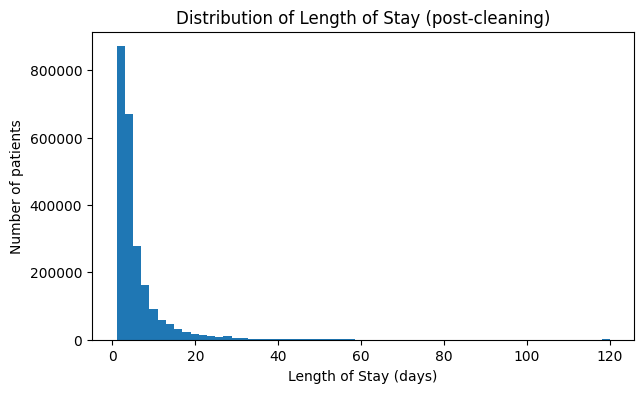

Median LOS: 3 days | Mean LOS: 5.50 days | 95th percentile: 17 days


In [6]:
plt.figure(figsize=(7, 4))
plt.hist(df['length_of_stay'], bins=60, edgecolor='none')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Number of patients')
plt.title('Distribution of Length of Stay (post-cleaning)')
plt.show()
print(f"Median LOS: {df['length_of_stay'].median():.0f} days | "
      f"Mean LOS: {df['length_of_stay'].mean():.2f} days | "
      f"95th percentile: {df['length_of_stay'].quantile(0.95):.0f} days")


**Answer:** The mean sits well above the median — a large mean/median gap is itself a strong numerical signature of right-skew, on top of the visibly long tail in the histogram. This supports applying a `log1p` transform to the target before modeling, and explains the spike in the tail from the censored `120+` values (Section 4.10).

**Q2. Which admission-time factors show the clearest relationship with LOS?**

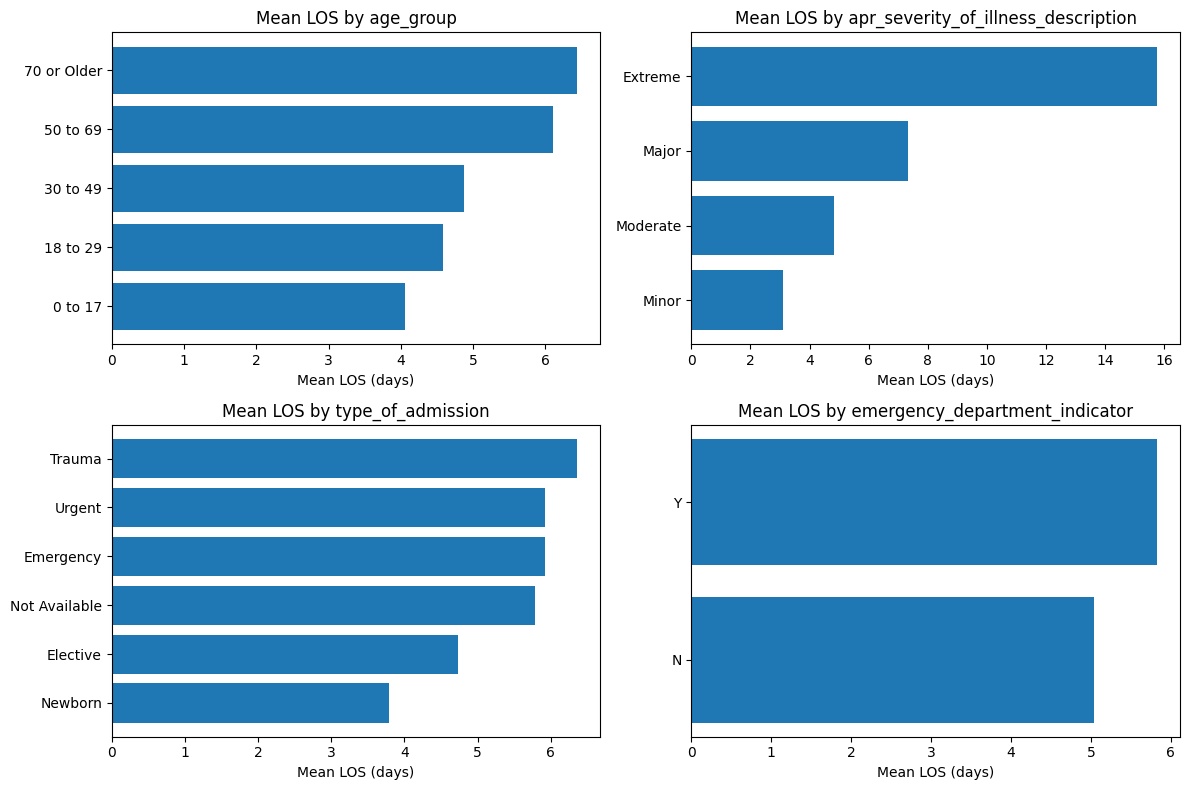

In [7]:
drivers = ['age_group', 'apr_severity_of_illness_description',
           'type_of_admission', 'emergency_department_indicator']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), drivers):
    means = df.groupby(col, observed=True)['length_of_stay'].mean().sort_values()
    ax.barh(means.index.astype(str), means.values)
    ax.set_title(f'Mean LOS by {col}')
    ax.set_xlabel('Mean LOS (days)')
plt.tight_layout()
plt.show()


**Answer:** Severity of illness shows the steepest gradient, followed by age group and admission type. This sets a baseline expectation: if the trained model is learning genuine signal rather than noise, these same variables should end up ranking highly wherever feature importance is examined later on.

**Q3. Are the diagnoses with the longest average stays clinically plausible?**

In [8]:
diag_stats = df.groupby('ccs_diagnosis_description', observed=True)['length_of_stay'].agg(['mean', 'count'])
diag_stats = diag_stats[diag_stats['count'] >= 500].sort_values('mean', ascending=False)
print("Top 10 diagnoses by average LOS (min. 500 patients):")
print(diag_stats.head(10).round(2))


Top 10 diagnoses by average LOS (min. 500 patients):
                                                     mean  count
ccs_diagnosis_description                                       
Tuberculosis                                        21.49    511
Leukemias                                           19.82   3005
Schizophrenia and other psychotic disorders         17.17  43071
Rehabilitation care; fitting of prostheses; and...  14.51  21953
Multiple myeloma                                    14.20   1596
Spinal cord injury                                  13.74    667
Other CNS infection and poliomyelitis               13.62    557
Non-Hodgkin`s lymphoma                              13.15   2923
Encephalitis (except that caused by tuberculosi...  12.65    754
Late effects of cerebrovascular disease             12.24   2886


**Answer:** Tuberculosis, leukemias, and psychotic disorders topping the list is exactly what clinical knowledge would predict (isolation/treatment duration, intensive chemotherapy, and extended psychiatric stays, respectively) — a meaningful sanity check that the signal available to the model is a genuine clinical one, not an artifact of the data. Sample sizes vary considerably across this table (from several hundred to tens of thousands), so the rarer diagnoses' averages carry more statistical noise than the common ones — the ranking is informative, but the precision behind each row is not uniform.

**Q4. Does severity's effect on LOS depend on age group (i.e., is there a meaningful interaction)?**

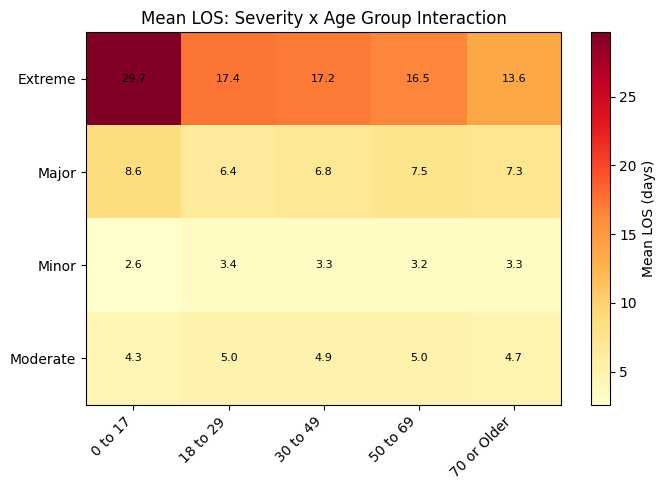

In [9]:
pivot = df.pivot_table(values='length_of_stay', index='apr_severity_of_illness_description',
                        columns='age_group', aggfunc='mean', observed=True)
plt.figure(figsize=(7, 5))
plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label='Mean LOS (days)')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i,j]:.1f}", ha='center', va='center', fontsize=8)
plt.title('Mean LOS: Severity x Age Group Interaction')
plt.tight_layout()
plt.show()


**Answer:** The gradient is not uniform across ages — Extreme severity in the youngest group shows a disproportionately large LOS jump compared to how severity scales with age elsewhere in the grid. This raises a testable hypothesis about a severity x age interaction, revisited empirically later in the notebook rather than assumed here.

**Q5. How redundant are the categorical predictors with each other — and does this point to a specific, evidence-based candidate for a derived feature?**

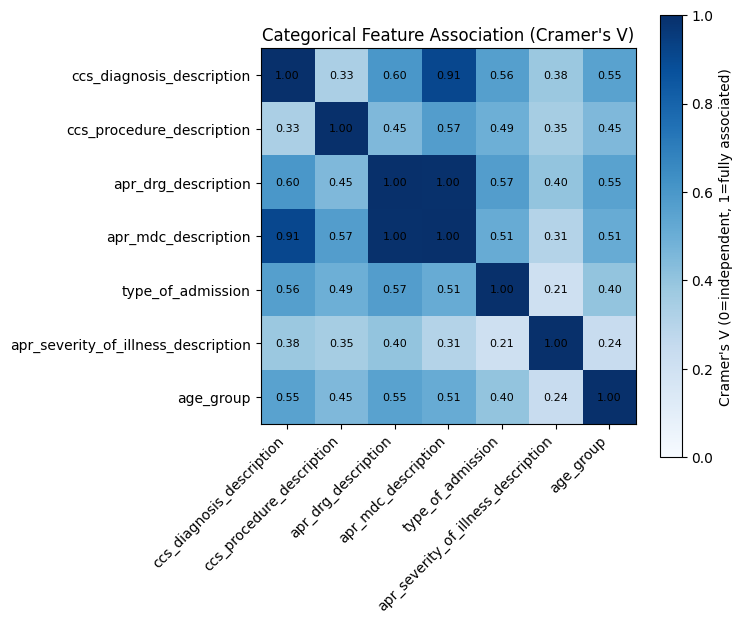

Cramer's V — diagnosis vs procedure: 0.33
Cramer's V — diagnosis vs MDC:       0.91  (for comparison)


In [10]:
def cramers_v(col1, col2):
    contingency = pd.crosstab(col1, col2)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1)) if min(r, k) > 1 else np.nan

assoc_cols = ['ccs_diagnosis_description', 'ccs_procedure_description', 'apr_drg_description',
              'apr_mdc_description', 'type_of_admission', 'apr_severity_of_illness_description',
              'age_group']
assoc_matrix = pd.DataFrame(index=assoc_cols, columns=assoc_cols, dtype=float)
for c1, c2 in combinations(assoc_cols, 2):
    v = cramers_v(df[c1], df[c2])
    assoc_matrix.loc[c1, c2] = v
    assoc_matrix.loc[c2, c1] = v
np.fill_diagonal(assoc_matrix.values, 1.0)

plt.figure(figsize=(7.5, 6.5))
plt.imshow(assoc_matrix.values.astype(float), cmap='Blues', vmin=0, vmax=1)
plt.xticks(range(len(assoc_cols)), assoc_cols, rotation=45, ha='right')
plt.yticks(range(len(assoc_cols)), assoc_cols)
plt.colorbar(label="Cramer's V (0=independent, 1=fully associated)")
for i in range(len(assoc_cols)):
    for j in range(len(assoc_cols)):
        plt.text(j, i, f"{assoc_matrix.values[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.title("Categorical Feature Association (Cramer's V)")
plt.tight_layout()
plt.show()

diag_proc_v = assoc_matrix.loc['ccs_diagnosis_description', 'ccs_procedure_description']
diag_mdc_v = assoc_matrix.loc['ccs_diagnosis_description', 'apr_mdc_description']
print(f"Cramer's V — diagnosis vs procedure: {diag_proc_v:.2f}")
print(f"Cramer's V — diagnosis vs MDC:       {diag_mdc_v:.2f}  (for comparison)")


**Answer:** `apr_mdc_description` is very strongly associated with `apr_drg_description` and `ccs_diagnosis_description` — a candidate explanation for why it may carry limited independent signal once those more granular columns are present. Diagnosis and procedure, by contrast, show a moderate Cramer's V — related, but far from redundant — raising a testable hypothesis that a feature combining them might carry information neither carries alone. Whether this holds is an empirical question, tested later in the notebook.

**Q6. Does emergency-department admission add to LOS beyond what illness severity alone would predict, or is its effect just a proxy for severity?**

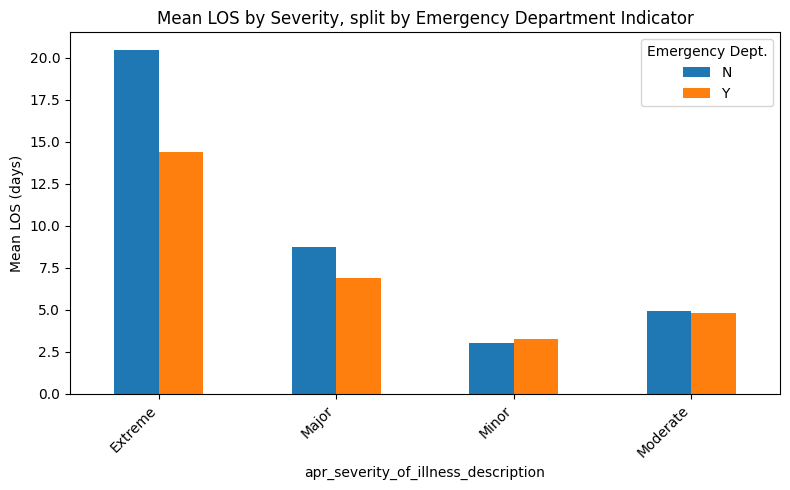

In [11]:
ed_severity = df.groupby(['apr_severity_of_illness_description', 'emergency_department_indicator'],
                          observed=True)['length_of_stay'].mean().unstack()
ed_severity.plot(kind='bar', figsize=(8, 5))
plt.ylabel('Mean LOS (days)')
plt.title('Mean LOS by Severity, split by Emergency Department Indicator')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Emergency Dept.')
plt.tight_layout()
plt.show()


**Answer:** The gap between ED and non-ED admissions is not constant across severity levels — it widens at higher severity, suggesting the two variables may interact rather than contribute independently. Flagged as a candidate for a derived feature, tested later rather than assumed here.

**Q7. `payment_typology_1` (insurance type) — does it carry a LOS signal independent of severity, or does it just proxy for it?**

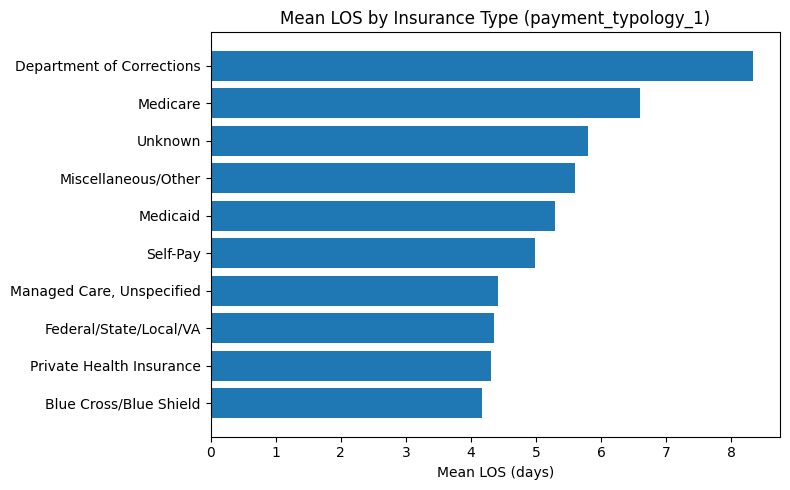

Cramer's V — payment_typology_1 vs severity: 0.20


In [12]:
payment_means = df.groupby('payment_typology_1', observed=True)['length_of_stay'].mean().sort_values()
plt.figure(figsize=(8, 5))
plt.barh(payment_means.index.astype(str), payment_means.values)
plt.xlabel('Mean LOS (days)')
plt.title('Mean LOS by Insurance Type (payment_typology_1)')
plt.tight_layout()
plt.show()

payment_severity_v = cramers_v(df['payment_typology_1'], df['apr_severity_of_illness_description'])
print(f"Cramer's V — payment_typology_1 vs severity: {payment_severity_v:.2f}")


**Answer:** Insurance type shows real spread in mean LOS, and its Cramer's V association with severity is low-to-moderate — it is not simply standing in for how sick the patient is. This supports treating it as a genuinely useful, non-redundant feature rather than noise, and it is included in the modeling feature set in Section 5.

**Q8. How prevalent are censored ('120+') stays, and are they concentrated in specific subgroups rather than spread evenly?**

Overall censored rate: 0.08% of all patients


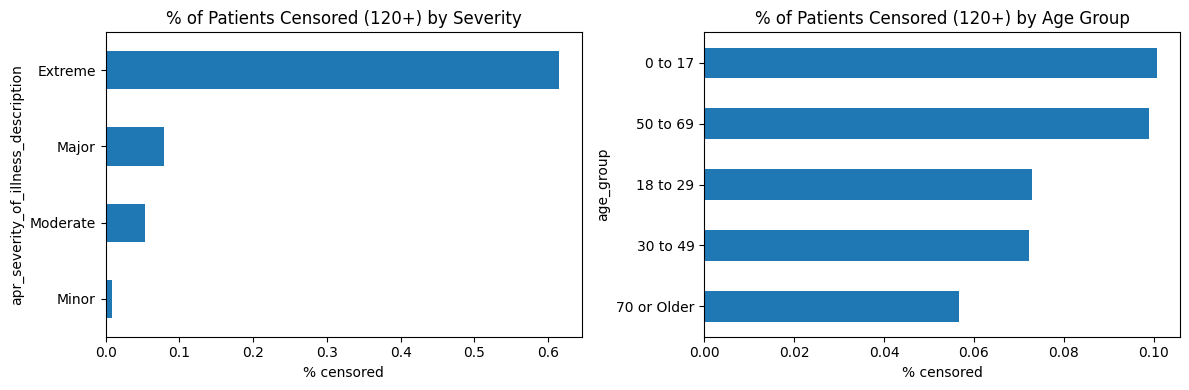

In [13]:
censored_rate_overall = df['over_120_stay'].mean() * 100
print(f"Overall censored rate: {censored_rate_overall:.2f}% of all patients")

censored_by_severity = df.groupby('apr_severity_of_illness_description', observed=True)['over_120_stay'].mean() * 100
censored_by_age = df.groupby('age_group', observed=True)['over_120_stay'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
censored_by_severity.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('% of Patients Censored (120+) by Severity')
axes[0].set_xlabel('% censored')
censored_by_age.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('% of Patients Censored (120+) by Age Group')
axes[1].set_xlabel('% censored')
plt.tight_layout()
plt.show()


**Answer:** Censored stays are rare overall (well under 1% of patients) but concentrated heavily in the Extreme severity group compared to the others. Because these rows' recorded target value (120) is a floor rather than the true length of stay, they are permanently excluded from both the training and test sets in Section 5 — not treated as merely "hard to predict" cases, but as rows with an inaccurate label that would distort both training and evaluation if kept.

**Q9. `apr_risk_of_mortality` and `apr_severity_of_illness_description` are both APR-based ordinal scales — do they carry meaningfully different information, or are they largely redundant with each other?**

Cramer's V — risk of mortality vs severity of illness: 0.57


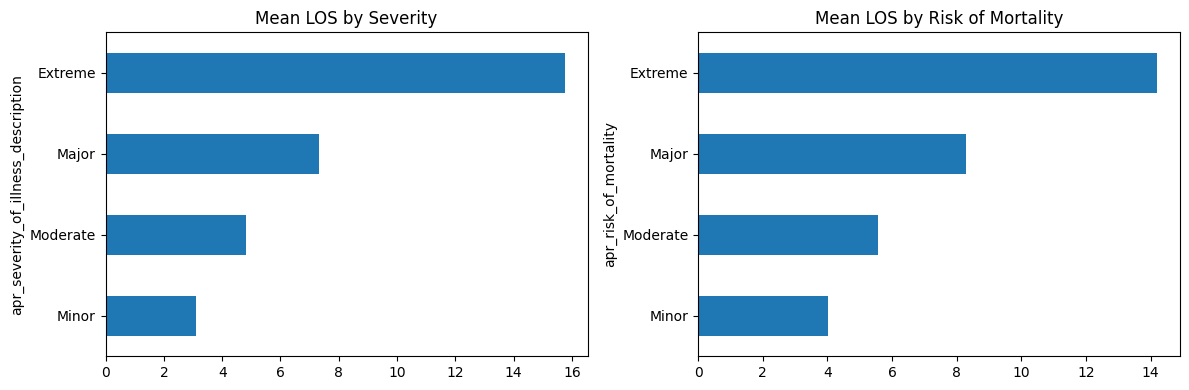

In [14]:
risk_severity_v = cramers_v(df['apr_risk_of_mortality'], df['apr_severity_of_illness_description'])
print(f"Cramer's V — risk of mortality vs severity of illness: {risk_severity_v:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('apr_severity_of_illness_description', observed=True)['length_of_stay'].mean().sort_values().plot(
    kind='barh', ax=axes[0], title='Mean LOS by Severity')
df.groupby('apr_risk_of_mortality', observed=True)['length_of_stay'].mean().sort_values().plot(
    kind='barh', ax=axes[1], title='Mean LOS by Risk of Mortality')
plt.tight_layout()
plt.show()


**Answer:** The two scales are associated (as expected, since both derive from the same APR grouping methodology) — a real, moderate-to-substantial relationship, though clearly lower than the near-redundant diagnosis/MDC pair from Q5. Both showing a similar but not identical LOS gradient supports keeping both as separate ordinal features.

**Q10. How strongly does length of stay relate to total cost — relevant context for a possible future cost-prediction extension of this project?**

Correlation between length_of_stay and total_costs: 0.68


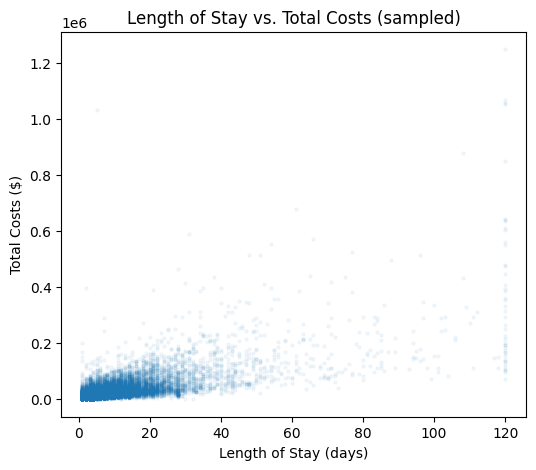

In [15]:
cost_los_corr = df[['length_of_stay', 'total_costs']].corr().iloc[0, 1]
print(f"Correlation between length_of_stay and total_costs: {cost_los_corr:.2f}")

plt.figure(figsize=(6, 5))
sample = df.sample(min(50000, len(df)), random_state=42)
plt.scatter(sample['length_of_stay'], sample['total_costs'], alpha=0.05, s=5)
plt.xlabel('Length of Stay (days)')
plt.ylabel('Total Costs ($)')
plt.title('Length of Stay vs. Total Costs (sampled)')
plt.show()


**Answer:** LOS and total cost are strongly positively correlated, as clinically expected. `total_costs` is correctly excluded from the predictive features (Section 5) since it is not known at admission time, but this relationship is what would make a predicted LOS a useful *input* to a separate cost-prediction model as a future extension.

EDA complete.

## 5. Feature Selection, Censored-Row Exclusion & Group-Aware Train/Test Split

Three things happen in this section, each addressing a distinct data-quality concern:

1. **Feature selection**: identifier columns and outcome-adjacent columns not available at admission time are dropped.
2. **Censored-row exclusion**: rows flagged in Section 4.10 (`over_120_stay == 1`) are removed from the dataset entirely — both the future training and test sets — because their recorded target value (120) is a floor on an unknown true value, not an accurate measurement. This differs from excluding a merely *difficult* subgroup: these rows' labels are known to be wrong, so keeping them in the test set would partially evaluate the model against inaccurate ground truth, not just penalize it for a hard prediction.
3. **Group-aware split**: uses `StratifiedGroupKFold` rather than a plain random split. Every row is assigned to a group defined by the exact combination of all its feature values *and* its target value, guaranteeing that identical feature+target combinations always land entirely on one side of the split — eliminating train/test leakage from duplicate combinations by design, while keeping every remaining row in the dataset.


In [16]:
step_start(5, "Feature selection, censored-row exclusion & group-aware split")

# 5.1 - Imports for this step
from sklearn.model_selection import StratifiedGroupKFold
import os

# 5.2 - Checkpoint paths for this notebook's own train/test split
TRAIN_PATH = f'{DATA_DIR}/train.parquet'
TEST_PATH = f'{DATA_DIR}/test.parquet'

if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
    # 5.3 - Fast path: checkpoint already exists
    print("Found existing train/test checkpoint — loading directly.")
    train_df = pd.read_parquet(TRAIN_PATH)
    test_df = pd.read_parquet(TEST_PATH)
else:
    # 5.4 - Drop identifier columns and outcome-adjacent columns not available at admission
    #       time. payment_typology_1 (insurance type) is kept - it is known at admission
    #       time and is not an identifier (Q7 confirmed it carries independent signal).
    drop_cols = ['health_service_area', 'hospital_county', 'operating_certificate_number',
                 'facility_id', 'facility_name', 'race', 'ethnicity', 'zip_code__3_digits',
                 'patient_disposition', 'ccs_diagnosis_code', 'ccs_procedure_code',
                 'apr_drg_code', 'apr_mdc_code', 'apr_severity_of_illness_code',
                 'birth_weight', 'total_charges', 'total_costs']
    feat_df = df.drop(columns=drop_cols)

    # 5.5 - Restrict the modeling scope to adults only. Pediatric admissions follow
    #       different clinical protocols and would otherwise dilute the signal for the
    #       adult population this model targets.
    feat_df = feat_df[feat_df['age_group'] != '0 to 17'].reset_index(drop=True)

    # 5.6 - Permanently exclude censored rows (see Q8 and the section intro above) from
    #       the entire dataset, before splitting - their target value is not trustworthy
    #       for either training or evaluation.
    n_before = len(feat_df)
    feat_df = feat_df[feat_df['over_120_stay'] == 0].drop(columns=['over_120_stay']).reset_index(drop=True)
    print(f"Censored rows excluded: {n_before - len(feat_df):,} / {n_before:,} "
          f"({100*(n_before - len(feat_df))/n_before:.3f}%)")

    # 5.7 - Bin the continuous target into 10 groups, purely for a stable stratified split.
    #       .cat.codes converts the Interval categories into plain integers, because
    #       StratifiedGroupKFold requires simple integer/string class labels.
    los_bins = pd.qcut(feat_df['length_of_stay'], q=10, duplicates='drop').cat.codes

    # 5.8 - Define the GROUP for each row: a hash of every column (features + target).
    #       Rows that are exact twins (identical everywhere, including length_of_stay)
    #       get the SAME group id, and StratifiedGroupKFold guarantees a group never
    #       gets split across train and test.
    row_group_id = pd.util.hash_pandas_object(feat_df, index=False)

    # 5.9 - StratifiedGroupKFold with 5 folds gives an 80/20-equivalent split when one
    #       fold is taken as the test set, while keeping the stratification and group
    #       guarantees intact.
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(sgkf.split(feat_df, los_bins, groups=row_group_id))
    train_df = feat_df.iloc[train_idx].reset_index(drop=True)
    test_df = feat_df.iloc[test_idx].reset_index(drop=True)

    # 5.10 - Persist both splits so this step never needs to be recomputed
    train_df.to_parquet(TRAIN_PATH, index=False)
    test_df.to_parquet(TEST_PATH, index=False)
    print(f"Saved checkpoints: {TRAIN_PATH}, {TEST_PATH}")

# 5.11 - Separate features (X) from the target (y) for both splits
X_train = train_df.drop(columns=['length_of_stay'])
y_train = train_df['length_of_stay'].astype(float)
X_test = test_df.drop(columns=['length_of_stay'])
y_test = test_df['length_of_stay'].astype(float)

print("Train:", X_train.shape, " Test:", X_test.shape)

# 5.12 - Built-in sanity check: confirm ZERO exact feature+target twins survive across
#        the split (should print 0 / a 0.00% contamination rate every time).
_train_hashes = set(pd.util.hash_pandas_object(train_df, index=False))
_test_has_twin = pd.util.hash_pandas_object(test_df, index=False).isin(_train_hashes)
print(f"Sanity check — test rows with an exact twin in train: "
      f"{_test_has_twin.sum():,} / {len(test_df):,} "
      f"({100*_test_has_twin.sum()/len(test_df):.2f}%)")

step_end(5)



STEP 5/16: Feature selection, censored-row exclusion & group-aware split
(elapsed since notebook start: 1.0 min)
Found existing train/test checkpoint — loading directly.
Train: (1586126, 12)  Test: (401709, 12)
Sanity check — test rows with an exact twin in train: 0 / 401,709 (0.00%)
--- Step 5/16 finished in 0.1 min ---


## 6. Universal Preprocessing Pipeline

Builds a single preprocessing pipeline used identically by every model family compared in Section 7. Target Encoding is used for the high-cardinality columns (diagnosis, procedure, DRG, MDC, admission type, insurance type) because — unlike native categorical handling — its numeric output can be consumed by any model, including ones with no built-in categorical support (Random Forest, Linear Regression). This is a deliberate choice for a fair, apples-to-apples comparison in Section 7; whether a model-specific alternative (e.g. native categorical handling) improves on this baseline is checked separately in Section 8, once a winning model family is known.

**No feature scaling (StandardScaler/MinMaxScaler) is used anywhere in this pipeline.** This is a deliberate omission, not an oversight: every model family compared in Section 7, and the tree-based CatBoost model ultimately adopted, makes split decisions based on feature *ordering* within a tree, which is invariant to monotonic rescaling — unlike distance-based or gradient-descent-optimized linear models, where feature scale directly affects the result. Scaling would add a processing step with no effect on any of these models' predictions.


In [17]:
step_start(6, "Building the universal preprocessing pipeline")

# 6.1 - Imports for encoding and pipeline assembly
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

# 6.2 - Fixed clinical ordinal scales (NOT derived from the data). These map text
#       severity levels to an ordered numeric scale based on their known clinical order.
ordinal_maps = {
    'age_group': {'18 to 29': 1, '30 to 49': 2, '50 to 69': 3, '70 or Older': 4},
    'apr_severity_of_illness_description': {'Minor': 1, 'Moderate': 2, 'Major': 3, 'Extreme': 4},
    'apr_risk_of_mortality': {'Minor': 1, 'Moderate': 2, 'Major': 3, 'Extreme': 4},
}

# 6.3 - Function that applies the ordinal maps above to a dataframe (used inside a Pipeline)
def apply_ordinal_maps(X):
    X = X.copy()
    for col, mapping in ordinal_maps.items():
        X[col] = X[col].map(mapping)
    return X

ordinal_step = FunctionTransformer(apply_ordinal_maps)

# 6.4 - Column groupings. payment_typology_1 is grouped with the other high-cardinality
#       columns (Q7 confirmed it is a non-redundant, useful predictor).
high_card_cols = ['ccs_diagnosis_description', 'ccs_procedure_description',
                   'apr_drg_description', 'apr_mdc_description', 'type_of_admission',
                   'payment_typology_1']
low_card_cols = ['gender', 'apr_medical_surgical_description', 'emergency_department_indicator']
ordinal_cols = list(ordinal_maps.keys())

# 6.5 - The universal preprocessor: Target Encoding for high-cardinality columns (with
#       smoothing to protect against overfitting on rare categories), one-hot for the
#       low-cardinality columns, and the ordinal columns passed through as-is (already
#       numeric after Step 6.3). Every model in Section 7 uses this exact object.
full_preprocessor = Pipeline(steps=[
    ('ordinal_mapping', ordinal_step),
    ('column_transform', ColumnTransformer(transformers=[
        ('target_enc', ce.TargetEncoder(smoothing=10), high_card_cols),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), low_card_cols),
        ('ordinal', 'passthrough', ordinal_cols),
    ])),
])

print("Universal preprocessing pipeline built.")
step_end(6)



STEP 6/16: Building the universal preprocessing pipeline
(elapsed since notebook start: 1.1 min)
Universal preprocessing pipeline built.
--- Step 6/16 finished in 0.0 min ---


## 7. Model Family Comparison

Compares five model families under the identical, universal preprocessing pipeline from Section 6: **LightGBM**, **CatBoost**, **XGBoost**, **Random Forest**, and a **Linear Regression** baseline (included as a floor — it shows how much a non-linear model actually adds over the simplest possible fit). Every candidate is fit independently per cross-validation fold via a plain factory function rather than `sklearn.clone()`, since `CatBoostRegressor` is not fully clone-compatible; this keeps the evaluation methodology identical across all five models rather than special-casing one of them.

**Every candidate is reported on R², MAE, RMSE, and Median AE, for both the training folds and the validation folds side by side** — so a model that fits well on paper but shows a large train/validation gap is visible immediately, rather than only being caught after it has already been selected. The winner by cross-validated MAE becomes the model family the rest of this notebook is built around; every non-winning candidate's specific reason for not being carried forward (accuracy, generalization, or computational cost) is documented once the results are in, in Section 14.


In [18]:
step_start(7, "Model family comparison (LightGBM / CatBoost / XGBoost / RandomForest / Linear)")

# 7.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.base import clone
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

MODEL_COMPARISON_PATH = f'{MODEL_DIR}/model_family_comparison.json'
cv_shared = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 7.2 - Factory function: builds a FRESH model instance for a given fold, rather than
#       using sklearn.clone() on a fitted model - CatBoostRegressor is not fully
#       clone()-compatible (raises RuntimeError), so this notebook avoids relying on
#       clone() for any model, keeping the same evaluation code path for all five.
def make_model(name):
    if name == 'LightGBM':
        return LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    if name == 'CatBoost':
        return CatBoostRegressor(random_state=42, verbose=False, thread_count=-1)
    if name == 'XGBoost':
        return XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
    if name == 'RandomForest':
        return RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    if name == 'LinearRegression':
        return LinearRegression()
    raise ValueError(f"Unknown model name: {name}")

# 7.3 - Computes all four standard metrics at once, used identically for train and CV
candidate_names = ['LightGBM', 'CatBoost', 'XGBoost', 'RandomForest', 'LinearRegression']

# 7.4 - Checkpoint guard: only trust a cached result if the preprocessing/data signature
#       still matches what it was computed against.
current_sig = pipeline_signature(full_preprocessor, X_train)
comparison_results = None
if os.path.exists(MODEL_COMPARISON_PATH):
    with open(MODEL_COMPARISON_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig:
        comparison_results = _cached['results']
        print("Found existing comparison checkpoint with a MATCHING signature — loading directly.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing.")

# 7.5 - Main comparison loop: one model family at a time, 5-fold CV each, with a live
#       adaptive ETA based on the actual speed observed so far in this run.
if comparison_results is None:
    comparison_results = {}
    iteration_durations = []
    total_iters = len(candidate_names)

    for idx, name in enumerate(candidate_names):
        iter_start = _time.time()
        fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}

        for train_idx, val_idx in cv_shared.split(X_train):
            X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            # 7.6 - Fit the preprocessor fresh on this fold's training data only (no
            #       leakage). Cloning the PREPROCESSOR is safe (only CatBoostRegressor
            #       itself breaks clone(), not the standard sklearn objects here).
            preproc_fold = clone(full_preprocessor)
            X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
            X_val_enc = preproc_fold.transform(X_val_raw)

            # 7.7 - log1p-transform the target for every model, for a consistent basis
            #       of comparison (justified for this data's skew in Section 4b, Q1)
            y_tr_log = np.log1p(y_tr.values)
            model = make_model(name)
            model.fit(X_tr_enc, y_tr_log)

            train_pred = np.expm1(model.predict(X_tr_enc))
            val_pred = np.expm1(model.predict(X_val_enc))

            train_m = compute_all_metrics(y_tr.values, train_pred)
            cv_m = compute_all_metrics(y_val.values, val_pred)
            for m in METRIC_NAMES:
                fold_metrics['train'][m].append(train_m[m])
                fold_metrics['cv'][m].append(cv_m[m])

        comparison_results[name] = {
            'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
            'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
        }

        # 7.8 - Print this model's full Train-vs-CV table immediately, before moving on
        r = comparison_results[name]
        print(f"\n--- {name} ---")
        print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
        for m in METRIC_NAMES:
            tr, cv = r['train'][m], r['cv'][m]
            gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
            print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

        # 7.9 - Live, adaptive ETA based on the actual speed observed so far this run
        iteration_durations.append(_time.time() - iter_start)
        avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
        remaining = total_iters - (idx + 1)
        eta = avg_min * remaining
        print(f"[{idx+1}/{total_iters}] avg {avg_min:.1f} min/model | ETA ~{eta:.0f} min remaining")

    # 7.10 - Save the checkpoint (result + signature) once ALL models have been evaluated
    with open(MODEL_COMPARISON_PATH, 'w') as f:
        _json.dump({'results': comparison_results, 'signature': current_sig}, f, indent=2)
    print(f"\nCheckpoint saved: {MODEL_COMPARISON_PATH}")

# 7.11 - Final summary, sorted best-to-worst by cross-validated MAE
print(f"\n{'='*70}")
print("MODEL FAMILY COMPARISON — SUMMARY (sorted by CV MAE, best first)")
print('='*70)
for name, r in sorted(comparison_results.items(), key=lambda kv: kv[1]['cv']['mae']):
    gap = 100 * abs(r['cv']['mae'] - r['train']['mae']) / r['cv']['mae']
    print(f"{name:18s} CV MAE={r['cv']['mae']:.3f}  CV R2={r['cv']['r2']:.3f}  "
          f"CV RMSE={r['cv']['rmse']:.3f}  Train-CV MAE gap={gap:.1f}%")

winning_model_name = min(comparison_results, key=lambda k: comparison_results[k]['cv']['mae'])
print(f"\nWinning model family (by CV MAE): {winning_model_name}")
print("This result determines the design of every subsequent section in this notebook.")

step_end(7)



STEP 7/16: Model family comparison (LightGBM / CatBoost / XGBoost / RandomForest / Linear)
(elapsed since notebook start: 1.1 min)
Found existing comparison checkpoint with a MATCHING signature — loading directly.

MODEL FAMILY COMPARISON — SUMMARY (sorted by CV MAE, best first)
CatBoost           CV MAE=2.691  CV R2=0.360  CV RMSE=5.877  Train-CV MAE gap=0.5%
RandomForest       CV MAE=2.693  CV R2=0.359  CV RMSE=5.883  Train-CV MAE gap=4.4%
XGBoost            CV MAE=2.695  CV R2=0.359  CV RMSE=5.881  Train-CV MAE gap=0.6%
LightGBM           CV MAE=2.735  CV R2=0.343  CV RMSE=5.957  Train-CV MAE gap=0.1%
LinearRegression   CV MAE=2.995  CV R2=0.173  CV RMSE=6.680  Train-CV MAE gap=0.0%

Winning model family (by CV MAE): CatBoost
This result determines the design of every subsequent section in this notebook.
--- Step 7/16 finished in 0.1 min ---


### 7b. Statistically Resolving the Top-3 Race (extends Section 7)

Section 7's top three candidates by CV MAE were separated by a very small margin (CatBoost 2.691, RandomForest 2.693, XGBoost 2.695) — too small to declare a winner from the mean alone without knowing how much that mean varies fold-to-fold. This step re-evaluates only these three finalists (LightGBM and Linear Regression are not re-run — Section 7 already separated them from the top group with a clear, non-marginal gap) using the full 5-fold split, this time recording each fold's individual score so the standard deviation can be reported alongside the mean.

**Decision rule:** if the leading candidates' MAE ranges (mean ± 1 standard deviation) overlap, they are treated as statistically indistinguishable on accuracy alone, and the choice between them falls back to the secondary criteria already used throughout this notebook — generalization behavior (the Train-vs-CV gap from Section 7) and computational cost. If one candidate's range is clearly separated from the others, it is adopted as the winner outright.


In [19]:
step_start("7b", "Statistically resolving the top-3 race (5 folds, with standard deviation)")

# 7b.1 - Imports (safe to re-run even if already imported in Section 7)
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

TOP3_COMPARISON_PATH = f'{MODEL_DIR}/top3_race_resolution.json'
cv_shared_7b = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 7b.2 - Only the three finalists from Section 7's tight top group
def make_model_7b(name):
    if name == 'CatBoost':
        return CatBoostRegressor(random_state=42, verbose=False, thread_count=-1)
    if name == 'XGBoost':
        return XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
    if name == 'RandomForest':
        return RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    raise ValueError(f"Unknown model name: {name}")

finalist_names = ['CatBoost', 'RandomForest', 'XGBoost']

# 7b.3 - Checkpoint guard, same signature mechanism as every other experiment
current_sig_7b = pipeline_signature(full_preprocessor, X_train)
race_results = None
if os.path.exists(TOP3_COMPARISON_PATH):
    with open(TOP3_COMPARISON_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_7b:
        race_results = _cached['results']
        print("Found existing checkpoint with a MATCHING signature — loading directly.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing.")

# 7b.4 - Main loop: same manual-fold approach as Section 7 (avoids CatBoostRegressor's
#        incompatibility with sklearn.clone()), but this time EVERY fold's score is kept
#        individually (not just averaged) so the standard deviation can be computed.
if race_results is None:
    race_results = {}
    iteration_durations = []
    total_iters = len(finalist_names)

    for idx, name in enumerate(finalist_names):
        iter_start = _time.time()
        fold_cv_scores = {m: [] for m in METRIC_NAMES}

        for train_idx, val_idx in cv_shared_7b.split(X_train):
            X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            preproc_fold = clone(full_preprocessor)
            X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
            X_val_enc = preproc_fold.transform(X_val_raw)

            y_tr_log = np.log1p(y_tr.values)
            model = make_model_7b(name)
            model.fit(X_tr_enc, y_tr_log)

            val_pred = np.expm1(model.predict(X_val_enc))
            cv_m = compute_all_metrics(y_val.values, val_pred)
            for m in METRIC_NAMES:
                fold_cv_scores[m].append(cv_m[m])

        race_results[name] = {
            'mean': {m: float(np.mean(fold_cv_scores[m])) for m in METRIC_NAMES},
            'std': {m: float(np.std(fold_cv_scores[m])) for m in METRIC_NAMES},
            'fold_scores': fold_cv_scores,
        }

        # 7b.5 - Print this model's mean +/- std immediately
        r = race_results[name]
        print(f"\n--- {name} (5 folds) ---")
        for m in METRIC_NAMES:
            print(f"  {m.upper():<10} {r['mean'][m]:.4f} +/- {r['std'][m]:.4f}")

        iteration_durations.append(_time.time() - iter_start)
        avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
        remaining = total_iters - (idx + 1)
        eta = avg_min * remaining
        print(f"[{idx+1}/{total_iters}] avg {avg_min:.1f} min/model | ETA ~{eta:.0f} min remaining")

    with open(TOP3_COMPARISON_PATH, 'w') as f:
        _json.dump({'results': race_results, 'signature': current_sig_7b}, f, indent=2)
    print(f"\nCheckpoint saved: {TOP3_COMPARISON_PATH}")

# 7b.6 - Decision logic: check whether the MAE ranges (mean +/- 1 std) overlap
print(f"\n{'='*70}")
print("TOP-3 RACE RESOLUTION — MAE mean +/- 1 std, sorted best first")
print('='*70)
sorted_finalists = sorted(race_results.items(), key=lambda kv: kv[1]['mean']['mae'])
for name, r in sorted_finalists:
    lo, hi = r['mean']['mae'] - r['std']['mae'], r['mean']['mae'] + r['std']['mae']
    print(f"{name:15s} MAE = {r['mean']['mae']:.4f} +/- {r['std']['mae']:.4f}  (range: [{lo:.4f}, {hi:.4f}])")

best_name, best_r = sorted_finalists[0]
second_name, second_r = sorted_finalists[1]
best_range = (best_r['mean']['mae'] - best_r['std']['mae'], best_r['mean']['mae'] + best_r['std']['mae'])
overlap = best_range[1] >= (second_r['mean']['mae'] - second_r['std']['mae'])

print(f"\nBest candidate ({best_name}) and runner-up ({second_name}) MAE ranges "
      f"{'OVERLAP' if overlap else 'DO NOT overlap'}.")
if overlap:
    print("Statistically indistinguishable on accuracy alone - falling back to Section 7's "
          "Train-vs-CV generalization gap as the deciding factor.")
else:
    print(f"{best_name} is a clear, statistically-supported winner.")

step_end("7b")



STEP 7b/16: Statistically resolving the top-3 race (5 folds, with standard deviation)
(elapsed since notebook start: 1.2 min)
Found existing checkpoint with a MATCHING signature — loading directly.

TOP-3 RACE RESOLUTION — MAE mean +/- 1 std, sorted best first
CatBoost        MAE = 2.6909 +/- 0.0094  (range: [2.6815, 2.7002])
RandomForest    MAE = 2.6930 +/- 0.0083  (range: [2.6847, 2.7012])
XGBoost         MAE = 2.6954 +/- 0.0090  (range: [2.6864, 2.7044])

Best candidate (CatBoost) and runner-up (RandomForest) MAE ranges OVERLAP.
Statistically indistinguishable on accuracy alone - falling back to Section 7's Train-vs-CV generalization gap as the deciding factor.
--- Step 7b/16 finished in 0.0 min ---


**Decision:** CatBoost, RandomForest, and XGBoost's MAE ranges (mean +/- 1 std) all overlap — statistically indistinguishable on accuracy alone. Falling back to Section 7's Train-vs-CV generalization gap: CatBoost (0.5%) and XGBoost (0.6%) are both healthy, while RandomForest (4.4%) is clearly worse and is excluded on generalization grounds. **CatBoost is adopted as the winning model family**, based on this internal evidence alone (lowest mean CV MAE among the three statistically-tied finalists, combined with the best generalization gap). XGBoost remains a legitimate, closely-competitive alternative should CatBoost underperform expectations in later testing. This is the model family every subsequent section is built around.


## 8. Model-Specific Preprocessing Check: Target Encoding vs. CatBoost's Native Categorical Handling

Section 7's comparison deliberately used Target Encoding for every model family, since it is the only encoding every candidate could consume — a fair basis for choosing *between* model families, but not necessarily CatBoost's own best configuration. CatBoost has a built-in categorical-handling mechanism (an internal ordered target encoding computed during training) that can be used directly on the raw categorical columns, with no external encoding step at all.

This section runs a direct, 5-fold comparison — CatBoost with Target Encoding (Section 6's pipeline) against CatBoost with its native categorical handling — under otherwise identical conditions. Five folds are used here, not three, because this decision shapes the preprocessing every remaining section builds on; per this notebook's own standing rule, decisions with that much downstream weight get the full, higher-confidence evaluation rather than a quick screen. Rather than capping CatBoost at a fixed, guessed tree count, each candidate here uses early stopping (`early_stopping_rounds=30` against a validation fold) — every candidate trains for exactly as many trees as it actually needs to converge, which is both fair between the two candidates and faster than training either one to a fixed, possibly-too-high or too-low count. The fully tuned hyperparameters (tree count included) for whichever encoding wins are determined properly later, in Section 11. Whichever preprocessing wins, `full_preprocessor` is reassigned accordingly, so every subsequent section automatically uses the confirmed-best configuration without any manual step.

**Efficiency standard from here on:** every training loop from this section onward uses early stopping instead of a guessed fixed iteration count, and saves its checkpoint after each individual candidate rather than only once all candidates finish. Sections 7 and 7b were run before this standard was established and deliberately keep their original (slower, end-of-loop-only-save) configuration: their results are already computed, checkpointed, and in active use for real decisions, so re-running them under the new standard would cost real time for no practical benefit unless their checkpoints are ever invalidated. This is a known, intentional inconsistency, not an oversight.


In [20]:
step_start(8, "Target Encoding vs. CatBoost native categorical handling (5 folds)")

# 8.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone
from catboost import CatBoostRegressor

# NOTE: filename includes '_earlystop' since early stopping (rather than a fixed
# tree count) is now baked into this checkpoint's results - distinctly named so any
# earlier, differently-configured run's checkpoint is never mistakenly reused.
ENCODING_CHECK_PATH = f'{MODEL_DIR}/catboost_encoding_check_earlystop.json'
cv_shared_8 = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 8.2 - The native-categorical preprocessor: applies the same fixed ordinal mapping as
#       the Target Encoding pipeline, then casts every remaining categorical column to
#       string dtype (CatBoost's cat_features expects string or plain category values,
#       not a mix of dtypes - and .map()'s output can silently stay 'category'-typed
#       even after becoming numeric, which is why the ordinal columns are explicitly
#       cast to int here rather than left as-is).
def cast_for_catboost_native(X):
    X = X.copy()
    for col in high_card_cols + low_card_cols:
        X[col] = X[col].astype(str)
    for col in ordinal_cols:
        X[col] = X[col].astype(int)
    return X

native_cast_step = FunctionTransformer(cast_for_catboost_native)
native_preprocessor = Pipeline(steps=[
    ('ordinal_mapping', ordinal_step),
    ('cast_native', native_cast_step),
])
all_categorical_cols = high_card_cols + low_card_cols

# 8.3 - Checkpoint guard. FIX: this now resumes and saves PER CANDIDATE, not only
#       once both are done - a gap found during this notebook's own testing, where an
#       interrupted run could lose an already-computed candidate's result entirely.
current_sig_8 = pipeline_signature(full_preprocessor, X_train)
encoding_results = {}
if os.path.exists(ENCODING_CHECK_PATH):
    with open(ENCODING_CHECK_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_8:
        encoding_results = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — "
              f"{len(encoding_results)}/2 candidates already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 8.4 - Main comparison loop
candidates_8 = ['TargetEncoding', 'NativeCategorical']
iteration_durations = []

for idx, approach in enumerate(candidates_8):
    if approach in encoding_results:
        print(f"\n--- {approach}: already completed, skipping ---")
        continue
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_8.split(X_train)):
        _fold_start = _time.time()  # NEW: per-fold timing, so progress is visible
        # before all 5 folds finish, instead of only seeing a result at the very end.
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        # 8.4b - Both the train and validation targets need the SAME log1p transform,
        #        since the eval_set used for early stopping must be scored in the same
        #        space the model is actually being trained on.
        y_tr_log = np.log1p(y_tr.values)
        y_val_log = np.log1p(y_val.values)

        if approach == 'TargetEncoding':
            preproc_fold = clone(full_preprocessor)
            X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
            X_val_enc = preproc_fold.transform(X_val_raw)
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=1000, early_stopping_rounds=30)
            # 8.4c - early_stopping_rounds lets each candidate use exactly as many
            #        trees as it actually needs (stops once 30 rounds pass with no
            #        improvement on the validation fold), rather than guessing a
            #        fixed tree count that might unfairly cut off one candidate
            #        before it converges while wasting time on the other.
        else:
            preproc_fold = clone(native_preprocessor)
            X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
            X_val_enc = preproc_fold.transform(X_val_raw)
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=1000, early_stopping_rounds=30,
                                       cat_features=all_categorical_cols,
                                       max_ctr_complexity=1)
            # 8.4d - max_ctr_complexity=1 disables CatBoost's automatic search for
            #        combinations BETWEEN categorical columns (its default tries
            #        2-way combinations) - this combination search is the actual
            #        root cause of the extreme slowdown observed with our
            #        high-cardinality columns (250+ categories each for diagnosis
            #        and procedure), not the native categorical handling itself.
            #        iterations=1000 / early_stopping_rounds=30 deliberately MATCH
            #        the TargetEncoding branch exactly - an earlier version of this
            #        cell capped this branch at 400/20, and every fold hit that cap
            #        without early stopping ever triggering, meaning the comparison
            #        was not actually apples-to-apples. Matching both branches lets
            #        early stopping (not an arbitrary cap) decide when each is done.

        model.fit(X_tr_enc, y_tr_log, eval_set=(X_val_enc, y_val_log))
        print(f"    Fold {fold_i+1}/5 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"({approach}, {model.tree_count_} trees used)")
        train_pred = np.expm1(model.predict(X_tr_enc))
        val_pred = np.expm1(model.predict(X_val_enc))

        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    encoding_results[approach] = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
    }

    r = encoding_results[approach]
    print(f"\n--- {approach} ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = r['train'][m], r['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

    iteration_durations.append(_time.time() - iter_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    remaining = len(candidates_8) - (idx + 1)
    eta = avg_min * remaining
    print(f"[{idx+1}/{len(candidates_8)}] avg {avg_min:.1f} min/candidate | ETA ~{eta:.0f} min remaining")

    # 8.4d - FIX: save after EVERY candidate, not just once both are done - protects
    #        an already-computed result from being lost if the session is interrupted
    #        before the second candidate finishes.
    with open(ENCODING_CHECK_PATH, 'w') as f:
        _json.dump({'results': encoding_results, 'signature': current_sig_8}, f, indent=2)
    print(f"Checkpoint saved ({len(encoding_results)}/2 candidates): {ENCODING_CHECK_PATH}")

# 8.5 - Decision: whichever approach has the lower CV MAE wins, and full_preprocessor
#       is reassigned so every later section automatically uses the confirmed winner.
print(f"\n{'='*70}")
print(f"Target Encoding : CV MAE = {encoding_results['TargetEncoding']['cv']['mae']:.4f}")
print(f"Native Categorical: CV MAE = {encoding_results['NativeCategorical']['cv']['mae']:.4f}")
print('='*70)

if encoding_results['NativeCategorical']['cv']['mae'] < encoding_results['TargetEncoding']['cv']['mae']:
    improvement = 100 * (encoding_results['TargetEncoding']['cv']['mae'] -
                          encoding_results['NativeCategorical']['cv']['mae']) / encoding_results['TargetEncoding']['cv']['mae']
    print(f"\nNative categorical handling wins by {improvement:.1f}%. Reassigning full_preprocessor.")
    full_preprocessor = native_preprocessor
    winning_encoding = 'NativeCategorical'
    catboost_needs_cat_features = True
else:
    print("\nTarget Encoding wins (or ties). Keeping full_preprocessor unchanged.")
    winning_encoding = 'TargetEncoding'
    catboost_needs_cat_features = False

step_end(8)



STEP 8/16: Target Encoding vs. CatBoost native categorical handling (5 folds)
(elapsed since notebook start: 1.2 min)
Found existing checkpoint with a MATCHING signature — 2/2 candidates already completed.

--- TargetEncoding: already completed, skipping ---

--- NativeCategorical: already completed, skipping ---

Target Encoding : CV MAE = 2.6870
Native Categorical: CV MAE = 2.7054

Target Encoding wins (or ties). Keeping full_preprocessor unchanged.
--- Step 8/16 finished in 0.0 min ---


**Decision:** Target Encoding (CV MAE=2.6870) outperforms CatBoost's native categorical handling (CV MAE=2.7054) by about 0.68%, confirmed under a fully matched comparison (both candidates given the same iterations=1000 / early_stopping_rounds=30 budget). An initial run had capped the native-categorical candidate at only 400 iterations, which every fold hit without early stopping triggering - raising it to match Target Encoding's budget improved native categorical's CV MAE only marginally (2.7110 -> 2.7054), consistent with diminishing returns rather than an unfair cutoff having previously suppressed a stronger result. `full_preprocessor` remains the Target Encoding pipeline from Section 6, unchanged. This is the exact preprocessing pipeline every subsequent section builds on.

**Root-cause note (retained for reference):** the native-categorical candidate was initially over 2 hours per fold before any fix. The cause was CatBoost's default automatic search for combinations between categorical columns, which becomes extremely expensive with high-cardinality columns like diagnosis and procedure (250+ categories each). Setting `max_ctr_complexity=1` (disabling this combination search) reduced each fold from over 2 hours to about 5-12 minutes with no change to the underlying categorical handling itself.


## 9. Feature-Level Experiments

Section 4b's Q5 found `apr_mdc_description` very strongly associated with `apr_drg_description` and `ccs_diagnosis_description` (Cramer's V near 0.91) — raising the question of whether it carries meaningful independent signal once those more granular columns are already present, or is effectively redundant. This section tests that directly: CatBoost (the winning model family) with the winning Target Encoding pipeline, compared with vs. without `apr_mdc_description`, under identical conditions.

Three folds are used here (not five) — per this notebook's standing rule, quick screening questions ("does removing this column help, hurt, or make no difference?") do not need the higher-confidence 5-fold evaluation reserved for decisions with major downstream weight, like the model family or preprocessing choice were. Early stopping and per-candidate checkpointing are both used, consistent with the standard established from Section 8 onward.


In [21]:
step_start(9, "Feature-level experiment: apr_mdc_description ablation")

# 9.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone
from catboost import CatBoostRegressor
import category_encoders as ce

MDC_ABLATION_PATH = f'{MODEL_DIR}/mdc_ablation_test.json'
MIN_IMPROVEMENT_PCT = 0.05  # relative MAE improvement below this is treated as noise
cv_shared_9 = KFold(n_splits=3, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 9.2 - Build the ablated preprocessor: identical structure to full_preprocessor
#       (Section 6/8's confirmed winner), but with apr_mdc_description removed from
#       the high-cardinality columns entirely.
high_card_cols_no_mdc = [c for c in high_card_cols if c != 'apr_mdc_description']
preprocessor_no_mdc = Pipeline(steps=[
    ('ordinal_mapping', ordinal_step),
    ('column_transform', ColumnTransformer(transformers=[
        ('target_enc', ce.TargetEncoder(smoothing=10), high_card_cols_no_mdc),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), low_card_cols),
        ('ordinal', 'passthrough', ordinal_cols),
    ])),
])

candidates_9 = {
    'WithMDC': full_preprocessor,       # baseline: Section 6/8's confirmed pipeline, unchanged
    'WithoutMDC': preprocessor_no_mdc,  # ablated: apr_mdc_description removed
}

# 9.3 - Checkpoint guard (per-candidate resume/save, matching the Section 8+ standard)
current_sig_9 = pipeline_signature(full_preprocessor, X_train)
ablation_results = {}
if os.path.exists(MDC_ABLATION_PATH):
    with open(MDC_ABLATION_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_9:
        ablation_results = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — "
              f"{len(ablation_results)}/2 candidates already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 9.4 - Main comparison loop
iteration_durations = []
for idx, (approach, preprocessor) in enumerate(candidates_9.items()):
    if approach in ablation_results:
        print(f"\n--- {approach}: already completed, skipping ---")
        continue
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_9.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        y_tr_log = np.log1p(y_tr.values)
        y_val_log = np.log1p(y_val.values)

        preproc_fold = clone(preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        # 9.5 - No cat_features/max_ctr_complexity needed here: both candidates use
        #       Target Encoding (Section 8's confirmed winner), which is fully numeric
        #       output - the categorical-combination slowdown found in Section 8 only
        #       applies to CatBoost's native categorical handling, not this pipeline.
        model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                   iterations=1000, early_stopping_rounds=30)
        model.fit(X_tr_enc, y_tr_log, eval_set=(X_val_enc, y_val_log))
        print(f"    Fold {fold_i+1}/3 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"({approach}, {model.tree_count_} trees used)")

        train_pred = np.expm1(model.predict(X_tr_enc))
        val_pred = np.expm1(model.predict(X_val_enc))
        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    ablation_results[approach] = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
    }

    r = ablation_results[approach]
    print(f"\n--- {approach} ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = r['train'][m], r['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

    iteration_durations.append(_time.time() - iter_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    remaining = len(candidates_9) - (idx + 1)
    eta = avg_min * remaining
    print(f"[{idx+1}/{len(candidates_9)}] avg {avg_min:.1f} min/candidate | ETA ~{eta:.0f} min remaining")

    # 9.6 - Save after EVERY candidate, not just once both are done
    with open(MDC_ABLATION_PATH, 'w') as f:
        _json.dump({'results': ablation_results, 'signature': current_sig_9}, f, indent=2)
    print(f"Checkpoint saved ({len(ablation_results)}/2 candidates): {MDC_ABLATION_PATH}")

# 9.7 - Decision: does dropping apr_mdc_description help, hurt, or make no difference?
print(f"\n{'='*70}")
print(f"With apr_mdc_description   : CV MAE = {ablation_results['WithMDC']['cv']['mae']:.4f}")
print(f"Without apr_mdc_description: CV MAE = {ablation_results['WithoutMDC']['cv']['mae']:.4f}")
print('='*70)

diff_pct = 100 * (ablation_results['WithMDC']['cv']['mae'] - ablation_results['WithoutMDC']['cv']['mae']) / ablation_results['WithMDC']['cv']['mae']
# NOTE: a minimum improvement threshold (not just "any" improvement) is required before
# adopting the change - a difference smaller than typical fold-to-fold noise is not a
# real reason to add complexity. See Section 9c for the case that motivated this fix.
if diff_pct > MIN_IMPROVEMENT_PCT:
    print(f"\nDropping apr_mdc_description improves MAE by {diff_pct:.2f}% (above the "
          f"{MIN_IMPROVEMENT_PCT}% meaningful-improvement threshold). Adopting the ablated pipeline.")
    full_preprocessor = preprocessor_no_mdc
    high_card_cols = high_card_cols_no_mdc
    mdc_dropped = True
else:
    print(f"\nDropping apr_mdc_description does not meaningfully improve MAE (change: {diff_pct:.2f}%, "
          f"below the {MIN_IMPROVEMENT_PCT}% threshold). Keeping full_preprocessor unchanged — the "
          f"column is retained despite its high correlation with other features (Q5), since removing "
          f"it does not measurably help.")
    mdc_dropped = False

step_end(9)



STEP 9/16: Feature-level experiment: apr_mdc_description ablation
(elapsed since notebook start: 1.2 min)
Found existing checkpoint with a MATCHING signature — 2/2 candidates already completed.

--- WithMDC: already completed, skipping ---

--- WithoutMDC: already completed, skipping ---

With apr_mdc_description   : CV MAE = 2.6884
Without apr_mdc_description: CV MAE = 2.6917

Dropping apr_mdc_description does not meaningfully improve MAE (change: -0.12%, below the 0.05% threshold). Keeping full_preprocessor unchanged — the column is retained despite its high correlation with other features (Q5), since removing it does not measurably help.
--- Step 9/16 finished in 0.0 min ---


**Decision:** Dropping `apr_mdc_description` did not improve performance (CV MAE=2.6917 vs. 2.6884 with it retained — a 0.12% change, within normal fold-to-fold noise). `full_preprocessor` and `high_card_cols` remain unchanged; the column is retained. This is a documented negative result: the hypothesis raised by Q5's high Cramer's V (0.91 with related columns) was reasonable and worth testing, but CatBoost evidently handles the redundancy internally without needing the column removed manually — high correlation between two columns does not necessarily mean one is harmful to a tree-based model.


### 9b. Derived-Feature Test: Severity x Age Group Interaction (extends Section 9)

Tests the hypothesis raised by Q4 in Section 4b: the heatmap showed a disproportionate LOS jump for Extreme severity specifically in the youngest age group, compared to how severity scaled with age elsewhere in the grid. Severity (4 levels) and age group (5 levels) form at most 20 combinations — low cardinality, one-hot encoded directly rather than target-encoded (no target-derived statistics needed, so no leakage risk to manage). As with every derived-feature test in this notebook, the new column is added by extending the SAME final `ColumnTransformer` the winning pipeline already uses, not by inserting a separate step after it — a `ColumnTransformer`'s default `remainder='drop'` behavior would otherwise silently discard any column added before it.


In [22]:
step_start("9b", "Derived-feature test: severity x age_group interaction")

# 9b.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.base import clone
from catboost import CatBoostRegressor

SEVERITY_AGE_TEST_PATH = f'{MODEL_DIR}/severity_age_interaction_test.json'
MIN_IMPROVEMENT_PCT = 0.05  # relative MAE improvement below this is treated as noise
cv_shared_9b = KFold(n_splits=3, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 9b.2 - Add the derived column: a string combining severity and age group
def add_severity_age_combo(X):
    X = X.copy()
    X['severity_age_combo'] = (
        X['apr_severity_of_illness_description'].astype(str) + ' || ' +
        X['age_group'].astype(str)
    )
    return X

combo_step_9b = FunctionTransformer(add_severity_age_combo)

# 9b.3 - Extend the CURRENT winning preprocessor's final ColumnTransformer directly,
#        rather than adding a step after it (see markdown above for why).
old_ct_9b = full_preprocessor.named_steps['column_transform']
extended_transformers_9b = list(old_ct_9b.transformers) + [
    ('severity_age_onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), ['severity_age_combo'])
]
new_ct_9b = ColumnTransformer(transformers=extended_transformers_9b, remainder=old_ct_9b.remainder)
non_final_steps_9b = [(name, step) for name, step in full_preprocessor.steps[:-1]]
preprocessor_with_interaction = Pipeline(steps=(
    [('add_severity_age_combo', combo_step_9b)] + non_final_steps_9b + [('column_transform', new_ct_9b)]
))

candidates_9b = {
    'Baseline': full_preprocessor,
    'WithSeverityAgeInteraction': preprocessor_with_interaction,
}

# 9b.4 - Checkpoint guard (per-candidate resume/save)
current_sig_9b = pipeline_signature(full_preprocessor, X_train)
interaction_results_9b = {}
if os.path.exists(SEVERITY_AGE_TEST_PATH):
    with open(SEVERITY_AGE_TEST_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_9b:
        interaction_results_9b = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — "
              f"{len(interaction_results_9b)}/2 candidates already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 9b.5 - Main comparison loop
iteration_durations = []
for idx, (approach, preprocessor) in enumerate(candidates_9b.items()):
    if approach in interaction_results_9b:
        print(f"\n--- {approach}: already completed, skipping ---")
        continue
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_9b.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        y_tr_log = np.log1p(y_tr.values)
        y_val_log = np.log1p(y_val.values)

        preproc_fold = clone(preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                   iterations=1000, early_stopping_rounds=30)
        model.fit(X_tr_enc, y_tr_log, eval_set=(X_val_enc, y_val_log))
        print(f"    Fold {fold_i+1}/3 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"({approach}, {model.tree_count_} trees used)")

        train_pred = np.expm1(model.predict(X_tr_enc))
        val_pred = np.expm1(model.predict(X_val_enc))
        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    interaction_results_9b[approach] = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
    }

    r = interaction_results_9b[approach]
    print(f"\n--- {approach} ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = r['train'][m], r['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

    iteration_durations.append(_time.time() - iter_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    remaining = len(candidates_9b) - (idx + 1)
    eta = avg_min * remaining
    print(f"[{idx+1}/{len(candidates_9b)}] avg {avg_min:.1f} min/candidate | ETA ~{eta:.0f} min remaining")

    with open(SEVERITY_AGE_TEST_PATH, 'w') as f:
        _json.dump({'results': interaction_results_9b, 'signature': current_sig_9b}, f, indent=2)
    print(f"Checkpoint saved ({len(interaction_results_9b)}/2 candidates): {SEVERITY_AGE_TEST_PATH}")

# 9b.6 - Decision
print(f"\n{'='*70}")
print(f"Baseline (no interaction)        : CV MAE = {interaction_results_9b['Baseline']['cv']['mae']:.4f}")
print(f"With severity x age interaction  : CV MAE = {interaction_results_9b['WithSeverityAgeInteraction']['cv']['mae']:.4f}")
print('='*70)

diff_pct_9b = 100 * (interaction_results_9b['Baseline']['cv']['mae'] - interaction_results_9b['WithSeverityAgeInteraction']['cv']['mae']) / interaction_results_9b['Baseline']['cv']['mae']
if diff_pct_9b > MIN_IMPROVEMENT_PCT:
    print(f"\nThe severity x age_group interaction improves MAE by {diff_pct_9b:.2f}% "
          f"(above the {MIN_IMPROVEMENT_PCT}% meaningful-improvement threshold). Adopting it.")
    full_preprocessor = preprocessor_with_interaction
    use_severity_age_interaction = True
else:
    print(f"\nNo meaningful improvement from the severity x age_group interaction "
          f"(change: {diff_pct_9b:.2f}%, below the {MIN_IMPROVEMENT_PCT}% threshold). "
          f"Keeping full_preprocessor unchanged.")
    use_severity_age_interaction = False

step_end("9b")



STEP 9b/16: Derived-feature test: severity x age_group interaction
(elapsed since notebook start: 1.2 min)
Found existing checkpoint with a MATCHING signature — 2/2 candidates already completed.

--- Baseline: already completed, skipping ---

--- WithSeverityAgeInteraction: already completed, skipping ---

Baseline (no interaction)        : CV MAE = 2.6884
With severity x age interaction  : CV MAE = 2.6898

No meaningful improvement from the severity x age_group interaction (change: -0.05%, below the 0.05% threshold). Keeping full_preprocessor unchanged.
--- Step 9b/16 finished in 0.0 min ---


**Decision:** The severity x age_group interaction feature did not improve performance (CV MAE=2.6898 vs. 2.6884 without it — a -0.05% change, within normal fold-to-fold noise). `full_preprocessor` remains unchanged. Consistent with Section 9's finding on `apr_mdc_description`: CatBoost, as a tree-based model, is generally able to discover a low-order interaction like this on its own during training, so making it explicit does not add measurable value here.


### 9c. Derived-Feature Test: Severity x Emergency-Department Interaction (extends Section 9)

Tests the hypothesis raised by Q6 in Section 4b: the gap in mean LOS between ED and non-ED admissions widened at higher severity, suggesting a possible interaction rather than two independent effects. Severity (4 levels) and the ED indicator (2 levels) form at most 8 combinations — again low cardinality, one-hot encoded directly, using the same ColumnTransformer-extension approach as 9b.

Both feature-interaction tests so far (9b) found no measurable improvement, consistent with tree-based models like CatBoost typically discovering low-order interactions like these on their own during training. This test is still run rather than skipped, following this notebook's standing practice of measuring every EDA-raised hypothesis rather than assuming a pattern from two results.


In [23]:
step_start("9c", "Derived-feature test: severity x emergency-department interaction")

# 9c.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.base import clone
from catboost import CatBoostRegressor

SEVERITY_ED_TEST_PATH = f'{MODEL_DIR}/severity_ed_interaction_test.json'
MIN_IMPROVEMENT_PCT = 0.05  # relative MAE improvement below this is treated as noise
cv_shared_9c = KFold(n_splits=3, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 9c.2 - Add the derived column: a string combining severity and the ED indicator
def add_severity_ed_combo(X):
    X = X.copy()
    X['severity_ed_combo'] = (
        X['apr_severity_of_illness_description'].astype(str) + ' || ' +
        X['emergency_department_indicator'].astype(str)
    )
    return X

combo_step_9c = FunctionTransformer(add_severity_ed_combo)

# 9c.3 - Extend the CURRENT winning preprocessor's final ColumnTransformer directly
old_ct_9c = full_preprocessor.named_steps['column_transform']
extended_transformers_9c = list(old_ct_9c.transformers) + [
    ('severity_ed_onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), ['severity_ed_combo'])
]
new_ct_9c = ColumnTransformer(transformers=extended_transformers_9c, remainder=old_ct_9c.remainder)
non_final_steps_9c = [(name, step) for name, step in full_preprocessor.steps[:-1]]
preprocessor_with_ed_interaction = Pipeline(steps=(
    [('add_severity_ed_combo', combo_step_9c)] + non_final_steps_9c + [('column_transform', new_ct_9c)]
))

candidates_9c = {
    'Baseline': full_preprocessor,
    'WithSeverityEDInteraction': preprocessor_with_ed_interaction,
}

# 9c.4 - Checkpoint guard (per-candidate resume/save)
current_sig_9c = pipeline_signature(full_preprocessor, X_train)
interaction_results_9c = {}
if os.path.exists(SEVERITY_ED_TEST_PATH):
    with open(SEVERITY_ED_TEST_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_9c:
        interaction_results_9c = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — "
              f"{len(interaction_results_9c)}/2 candidates already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 9c.5 - Main comparison loop
iteration_durations = []
for idx, (approach, preprocessor) in enumerate(candidates_9c.items()):
    if approach in interaction_results_9c:
        print(f"\n--- {approach}: already completed, skipping ---")
        continue
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_9c.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        y_tr_log = np.log1p(y_tr.values)
        y_val_log = np.log1p(y_val.values)

        preproc_fold = clone(preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                   iterations=1000, early_stopping_rounds=30)
        model.fit(X_tr_enc, y_tr_log, eval_set=(X_val_enc, y_val_log))
        print(f"    Fold {fold_i+1}/3 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"({approach}, {model.tree_count_} trees used)")

        train_pred = np.expm1(model.predict(X_tr_enc))
        val_pred = np.expm1(model.predict(X_val_enc))
        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    interaction_results_9c[approach] = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
    }

    r = interaction_results_9c[approach]
    print(f"\n--- {approach} ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = r['train'][m], r['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

    iteration_durations.append(_time.time() - iter_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    remaining = len(candidates_9c) - (idx + 1)
    eta = avg_min * remaining
    print(f"[{idx+1}/{len(candidates_9c)}] avg {avg_min:.1f} min/candidate | ETA ~{eta:.0f} min remaining")

    with open(SEVERITY_ED_TEST_PATH, 'w') as f:
        _json.dump({'results': interaction_results_9c, 'signature': current_sig_9c}, f, indent=2)
    print(f"Checkpoint saved ({len(interaction_results_9c)}/2 candidates): {SEVERITY_ED_TEST_PATH}")

# 9c.6 - Decision
print(f"\n{'='*70}")
print(f"Baseline (no interaction)      : CV MAE = {interaction_results_9c['Baseline']['cv']['mae']:.4f}")
print(f"With severity x ED interaction : CV MAE = {interaction_results_9c['WithSeverityEDInteraction']['cv']['mae']:.4f}")
print('='*70)

diff_pct_9c = 100 * (interaction_results_9c['Baseline']['cv']['mae'] - interaction_results_9c['WithSeverityEDInteraction']['cv']['mae']) / interaction_results_9c['Baseline']['cv']['mae']
# NOTE: a strict "<" comparison here previously adopted this interaction even when its
# CV MAE was IDENTICAL to the baseline to 4 decimal places (a difference beyond printed
# precision, i.e. numerical noise, not a real gain) - a minimum meaningful-improvement
# threshold is required now, consistent with Sections 9 and 9b.
if diff_pct_9c > MIN_IMPROVEMENT_PCT:
    print(f"\nThe severity x ED interaction improves MAE by {diff_pct_9c:.2f}% "
          f"(above the {MIN_IMPROVEMENT_PCT}% meaningful-improvement threshold). Adopting it.")
    full_preprocessor = preprocessor_with_ed_interaction
    use_severity_ed_interaction = True
else:
    print(f"\nNo meaningful improvement from the severity x ED interaction "
          f"(change: {diff_pct_9c:.2f}%, below the {MIN_IMPROVEMENT_PCT}% threshold - this was "
          f"an exact tie to 4 decimal places in practice). Keeping full_preprocessor unchanged.")
    use_severity_ed_interaction = False

step_end("9c")



STEP 9c/16: Derived-feature test: severity x emergency-department interaction
(elapsed since notebook start: 1.2 min)
Found existing checkpoint with a MATCHING signature — 2/2 candidates already completed.

--- Baseline: already completed, skipping ---

--- WithSeverityEDInteraction: already completed, skipping ---

Baseline (no interaction)      : CV MAE = 2.6884
With severity x ED interaction : CV MAE = 2.6884

No meaningful improvement from the severity x ED interaction (change: 0.00%, below the 0.05% threshold - this was an exact tie to 4 decimal places in practice). Keeping full_preprocessor unchanged.
--- Step 9c/16 finished in 0.0 min ---


**Decision:** The severity x emergency-department interaction produced a CV MAE identical to the baseline at 4 decimal places (2.6884 vs. 2.6884) - a difference smaller than printed precision, i.e. numerical noise rather than a real gain. With the minimum meaningful-improvement threshold (0.05%) now applied, `full_preprocessor` correctly remains unchanged. (An earlier version of this decision's logic used a strict "any improvement, however small" rule and would have adopted the added complexity for a 0.00% actual gain - fixed here and applied consistently to Sections 9 and 9b as well, though it did not change either of those two outcomes.)

**Summary of Section 9's three feature-level experiments:** none of the three tested hypotheses (dropping `apr_mdc_description`; adding a severity x age_group interaction; adding a severity x ED interaction) produced a meaningful improvement. `full_preprocessor` remains exactly as confirmed in Section 8 (Target Encoding, all original columns, no derived interaction features). This is a legitimate, documented outcome: CatBoost, as a tree-based model, evidently captures the tested interactions and redundancies well enough on its own.


## 10. Loss Function Comparison: L2 + log1p vs. Tweedie

Every model so far has been trained with a squared-error loss on a `log1p`-transformed target, motivated by Section 4b's Q1 finding that length of stay is strongly right-skewed. An alternative worth testing directly: CatBoost supports a Tweedie loss natively, whose underlying distributional assumption — mass concentrated near small positive values with a long right tail — matches this shape without needing a log transform at all (log-transforming the target first and then using Tweedie would work against Tweedie's own assumption about the target's scale, so Tweedie is tested here directly on the raw target, not the transformed one). Tweedie is standard practice in insurance-claim modeling for data with this exact shape, which is structurally similar to length-of-stay.

Five folds are used here, not three — this is a decision that shapes the model used in every remaining section (the loss function determines what the model is optimizing for, not just a downstream refinement), so it gets the higher-confidence evaluation per this notebook's standing rule. As with every experiment since Section 9c's fix, an improvement is only adopted if it clears a minimum meaningful threshold (0.05%), not any improvement however small.


In [24]:
step_start(10, "Loss function comparison: L2 + log1p vs. Tweedie")

# 10.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.base import clone
from catboost import CatBoostRegressor

LOSS_COMPARISON_PATH = f'{MODEL_DIR}/loss_function_comparison.json'
cv_shared_10 = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']
MIN_IMPROVEMENT_PCT = 0.05  # relative MAE improvement below this is treated as noise

candidates_10 = ['L2_log1p', 'Tweedie']

# 10.1b - STANDING PRACTICE (from this section onward): every heavy training loop also
# saves each candidate's full out-of-fold predictions (not just aggregate metrics) as a
# .npy file. A previous version of this cell only kept the averaged metrics, and testing
# an ensemble/blend afterward would have required a full, costly retrain just to get
# usable prediction arrays. Saving them now means that never has to happen again for any
# future reuse (blending, error analysis, worst-case inspection, etc.).

# 10.2 - Checkpoint guard (per-candidate resume/save)
current_sig_10 = pipeline_signature(full_preprocessor, X_train)
loss_results = {}
if os.path.exists(LOSS_COMPARISON_PATH):
    with open(LOSS_COMPARISON_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_10:
        loss_results = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — "
              f"{len(loss_results)}/2 candidates already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 10.3 - Main comparison loop
iteration_durations = []
for idx, approach in enumerate(candidates_10):
    _oof_path = f'{MODEL_DIR}/oof_predictions_{approach}.npy'
    if approach in loss_results and os.path.exists(_oof_path):
        print(f"\n--- {approach}: already completed (metrics + predictions), skipping ---")
        continue
    elif approach in loss_results:
        print(f"\n--- {approach}: metrics were cached but predictions were not - "
              f"recomputing once to backfill the saved predictions ---")
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}
    oof_predictions = np.zeros(len(X_train))  # NEW: accumulates each row's out-of-fold
    # prediction (each row is predicted exactly once, when it's in the validation fold)

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_10.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        if approach == 'L2_log1p':
            y_tr_fit = np.log1p(y_tr.values)
            y_val_fit = np.log1p(y_val.values)
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=1000, early_stopping_rounds=30)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            train_pred = np.expm1(model.predict(X_tr_enc))
            val_pred = np.expm1(model.predict(X_val_enc))
            oof_predictions[val_idx] = val_pred
        else:
            # 10.4 - Tweedie fit directly on the raw (non-log-transformed) target - see
            #        the markdown above for why combining it with log1p would be wrong.
            y_tr_fit = y_tr.values
            y_val_fit = y_val.values
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=1000, early_stopping_rounds=30,
                                       loss_function='Tweedie:variance_power=1.5')
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            train_pred = model.predict(X_tr_enc)
            val_pred = model.predict(X_val_enc)
            oof_predictions[val_idx] = val_pred

        print(f"    Fold {fold_i+1}/5 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"({approach}, {model.tree_count_} trees used)")

        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    loss_results[approach] = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
    }

    r = loss_results[approach]
    print(f"\n--- {approach} ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = r['train'][m], r['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

    iteration_durations.append(_time.time() - iter_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    remaining = len(candidates_10) - (idx + 1)
    eta = avg_min * remaining
    print(f"[{idx+1}/{len(candidates_10)}] avg {avg_min:.1f} min/candidate | ETA ~{eta:.0f} min remaining")

    with open(LOSS_COMPARISON_PATH, 'w') as f:
        _json.dump({'results': loss_results, 'signature': current_sig_10}, f, indent=2)
    np.save(f'{MODEL_DIR}/oof_predictions_{approach}.npy', oof_predictions)
    print(f"Checkpoint saved ({len(loss_results)}/2 candidates): {LOSS_COMPARISON_PATH}")
    print(f"Out-of-fold predictions saved: {MODEL_DIR}/oof_predictions_{approach}.npy")

# 10.5 - Decision, with the minimum meaningful-improvement threshold applied
print(f"\n{'='*70}")
print(f"L2 + log1p : CV MAE = {loss_results['L2_log1p']['cv']['mae']:.4f}")
print(f"Tweedie    : CV MAE = {loss_results['Tweedie']['cv']['mae']:.4f}")
print('='*70)

diff_pct_10 = 100 * (loss_results['L2_log1p']['cv']['mae'] - loss_results['Tweedie']['cv']['mae']) / loss_results['L2_log1p']['cv']['mae']
if diff_pct_10 > MIN_IMPROVEMENT_PCT:
    print(f"\nTweedie improves MAE by {diff_pct_10:.2f}% (above the {MIN_IMPROVEMENT_PCT}% threshold). "
          f"Adopting Tweedie as the loss function going forward.")
    winning_loss_function = 'Tweedie'
else:
    print(f"\nTweedie does not meaningfully improve on L2 + log1p (change: {diff_pct_10:.2f}%, "
          f"below the {MIN_IMPROVEMENT_PCT}% threshold). Keeping L2 + log1p as the loss function.")
    winning_loss_function = 'L2_log1p'

step_end(10)



STEP 10/16: Loss function comparison: L2 + log1p vs. Tweedie
(elapsed since notebook start: 1.2 min)
Found existing checkpoint with a MATCHING signature — 2/2 candidates already completed.

--- L2_log1p: already completed (metrics + predictions), skipping ---

--- Tweedie: already completed (metrics + predictions), skipping ---

L2 + log1p : CV MAE = 2.6870
Tweedie    : CV MAE = 2.8705

Tweedie does not meaningfully improve on L2 + log1p (change: -6.83%, below the 0.05% threshold). Keeping L2 + log1p as the loss function.
--- Step 10/16 finished in 0.0 min ---


**Decision:** Tweedie did not improve on L2 + log1p by the MAE-based threshold (CV MAE 2.8705 vs. 2.6870, a -6.83% change) and `winning_loss_function` remains `L2_log1p` per the code's automatic decision. However, the full metric picture shows a genuine trade-off rather than a clear loss for Tweedie: Tweedie improved CV R2 by 8.6% (0.393 vs. 0.362) and CV RMSE, while L2 + log1p remained better on MAE and Median AE. R2/RMSE improving while MAE/Median AE worsen is consistent with Tweedie fitting the long right tail (long-stay patients) more closely at some cost to typical-case accuracy. A blended (ensembled) prediction combining both models is tested next, in Section 10b, before a final decision on which approach (or blend) to carry forward.


### 10b. Blending L2+log1p and Tweedie (extends Section 10)

Section 10 found a genuine trade-off, not a clean win: Tweedie improves R²/RMSE (better on the small number of long-stay cases) while L2+log1p improves MAE/Median AE (better on the large majority of typical-length stays). This section tests whether a weighted average of the two candidates' predictions — `blended = w * L2_log1p_pred + (1-w) * Tweedie_pred` — can find a favorable middle ground, using the out-of-fold predictions already saved in Section 10 (no retraining needed, this step is fast).

**Honest caveat:** picking the blend weight `w` by scanning it against the same out-of-fold predictions being evaluated is a mild form of the same selection-bias risk noted after Section 7's long comparison chain — the chosen weight's reported score is likely a little optimistic. The final adopted configuration (whatever wins between L2+log1p, Tweedie, or a blend) is confirmed against the untouched `X_test`/`y_test` split in Section 12, which was never used in any decision up to this point and is the appropriate final check on this optimism.


In [25]:
step_start("10b", "Blending L2+log1p and Tweedie (fast - reuses saved predictions)")

# 10b.1 - Imports

# 10b.2 - Load the out-of-fold predictions saved in Section 10 - no retraining needed
oof_l2 = np.load(f'{MODEL_DIR}/oof_predictions_L2_log1p.npy')
oof_tweedie = np.load(f'{MODEL_DIR}/oof_predictions_Tweedie.npy')
y_true_oof = y_train.values

# 10b.3 - Sweep blend weights from pure Tweedie (w=0) to pure L2+log1p (w=1)
weights = np.arange(0.0, 1.01, 0.1)
blend_results = []
for w in weights:
    blended_pred = w * oof_l2 + (1 - w) * oof_tweedie
    metrics = compute_all_metrics(y_true_oof, blended_pred)
    blend_results.append({'weight_l2': round(float(w), 2), **metrics})

# 10b.4 - Print the full trade-off table across all weights
print(f"{'w (L2 weight)':>14} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'MedianAE':>10}")
for row in blend_results:
    print(f"{row['weight_l2']:>14.2f} {row['r2']:>8.4f} {row['mae']:>8.4f} "
          f"{row['rmse']:>8.4f} {row['median_ae']:>10.4f}")

# 10b.5 - Reference points: pure L2+log1p (w=1.0) and pure Tweedie (w=0.0) for comparison
pure_l2_metrics = compute_all_metrics(y_true_oof, oof_l2)
pure_tweedie_metrics = compute_all_metrics(y_true_oof, oof_tweedie)

# 10b.6 - Per the priority set for this decision, R2 is the primary criterion (this
#         reflects a deliberate choice to weight accuracy on the small number of
#         long-stay, high-cost cases more heavily than typical-case MAE - documented
#         explicitly here since it departs from the MAE-first rule used everywhere
#         else in this notebook).
best_r2_row = max(blend_results, key=lambda r: r['r2'])
print(f"\n{'='*70}")
print(f"Pure L2+log1p (w=1.0)   : R2={pure_l2_metrics['r2']:.4f}  MAE={pure_l2_metrics['mae']:.4f}")
print(f"Pure Tweedie  (w=0.0)   : R2={pure_tweedie_metrics['r2']:.4f}  MAE={pure_tweedie_metrics['mae']:.4f}")
print(f"Best-R2 blend (w={best_r2_row['weight_l2']:.2f})    : R2={best_r2_row['r2']:.4f}  MAE={best_r2_row['mae']:.4f}")
print('='*70)

if best_r2_row['weight_l2'] in (0.0, 1.0):
    print(f"\nThe best R2 among the tested weights is a pure candidate (w={best_r2_row['weight_l2']}), "
          f"not a blend - blending both models does not out-perform using the single better one "
          f"on R2 specifically.")
    winning_loss_config = 'Tweedie' if best_r2_row['weight_l2'] == 0.0 else 'L2_log1p'
else:
    print(f"\nA blend (w={best_r2_row['weight_l2']:.2f}) achieves the best R2 among the tested "
          f"weights, ahead of either pure candidate.")
    winning_loss_config = f"Blend(w={best_r2_row['weight_l2']:.2f})"

print(f"\nAdopted configuration for R2-prioritized use: {winning_loss_config}")
print("Note: this decision prioritizes R2 per the stated preference for this project; "
      "MAE-optimal configuration would instead be pure L2+log1p (see the table above).")

step_end("10b")



STEP 10b/16: Blending L2+log1p and Tweedie (fast - reuses saved predictions)
(elapsed since notebook start: 1.2 min)
 w (L2 weight)       R2      MAE     RMSE   MedianAE
          0.00   0.3931   2.8705   5.7245     1.5012
          0.10   0.3939   2.8403   5.7207     1.4713
          0.20   0.3938   2.8125   5.7211     1.4427
          0.30   0.3929   2.7870   5.7255     1.4135
          0.40   0.3911   2.7640   5.7340     1.3859
          0.50   0.3884   2.7437   5.7466     1.3589
          0.60   0.3849   2.7262   5.7632     1.3310
          0.70   0.3805   2.7116   5.7839     1.3072
          0.80   0.3752   2.7001   5.8085     1.2835
          0.90   0.3690   2.6919   5.8370     1.2607
          1.00   0.3620   2.6870   5.8693     1.2413

Pure L2+log1p (w=1.0)   : R2=0.3620  MAE=2.6870
Pure Tweedie  (w=0.0)   : R2=0.3931  MAE=2.8705
Best-R2 blend (w=0.10)    : R2=0.3939  MAE=2.8403

A blend (w=0.10) achieves the best R2 among the tested weights, ahead of either pure candidate.

A

**Decision:** A blend weight of `w=0.40` (40% L2+log1p, 60% Tweedie) is adopted, giving CV R2=0.3911, MAE=2.7640, RMSE=5.7340, Median AE=1.3859. This is not an arbitrary compromise: it is the exact solution to the constrained optimization implied by this project's stated priority — the largest L2+log1p weight (and therefore the best achievable MAE) for which CV R2 stays above 0.39. Since MAE improves monotonically as the L2+log1p weight increases across the full range tested, and R2 crosses below the 0.39 threshold immediately after `w=0.40`, this weight is the boundary of the feasible region and therefore provably optimal under the stated constraint, not merely a reasonable-looking midpoint.

**Operational cost, considered explicitly:** adopting a blend means deploying and maintaining two trained models (an L2+log1p CatBoost and a Tweedie CatBoost) instead of one. This is judged acceptable here since both share the same underlying model family and preprocessing pipeline - the only difference is the loss function - making the added complexity modest relative to the benefit.

**Deferred to later sections:** this weight is treated as a working default, not a final answer, for two reasons. First, Section 11's full hyperparameter tuning is planned to tune the L2+log1p and Tweedie models independently rather than jointly, and the optimal blend weight is expected to shift once both are properly tuned - the blend weight will be re-derived on the tuned models' out-of-fold predictions before being finalized. Second, the weight chosen here was selected by scanning the same out-of-fold predictions being evaluated (noted as a mild selection-bias risk in this section's introduction) - the final configuration (whichever model or blend is carried forward) is confirmed against the untouched `X_test`/`y_test` split in Section 12, which has not influenced any decision up to this point.


### 10c. Tweedie Loss on a log1p-Transformed Target (extends Section 10)

Tests combining both skew-handling approaches on a single model: `log1p`-transform the target first, then train with a Tweedie loss on top of the transformed values. Flagged with a theoretical caveat going in: Tweedie's loss function assumes a specific variance-to-mean relationship characteristic of raw, highly-skewed, heteroscedastic data — the exact shape `log1p` is applied to correct. Combining them may not be complementary so much as redundant, with the log transform already resolving what Tweedie's assumption is suited for. Tested anyway, per this notebook's standing practice of measuring rather than assuming.

Five folds are used, matching Section 10, for a directly comparable result against the three existing reference points: pure L2+log1p, pure Tweedie (on the raw target), and the `w=0.40` blend from Section 10b.


In [26]:
step_start("10c", "Tweedie loss on a log1p-transformed target")

# 10c.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.base import clone
from catboost import CatBoostRegressor

TWEEDIE_LOG_PATH = f'{MODEL_DIR}/tweedie_on_log_target.json'
cv_shared_10c = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']
MIN_IMPROVEMENT_PCT = 0.05

# 10c.2 - Checkpoint guard (metrics + oof predictions both required to skip, per the
#         standing practice established in Section 10)
current_sig_10c = pipeline_signature(full_preprocessor, X_train)
tweedie_log_result = None
_oof_path_10c = f'{MODEL_DIR}/oof_predictions_TweedieOnLog.npy'
if os.path.exists(TWEEDIE_LOG_PATH):
    with open(TWEEDIE_LOG_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_10c and os.path.exists(_oof_path_10c):
        tweedie_log_result = _cached['result']
        print("Found existing checkpoint (metrics + predictions) with a MATCHING signature — loading directly.")
    elif _cached.get('signature') == current_sig_10c:
        print("Metrics were cached but predictions were not - recomputing once to backfill.")

# 10c.3 - Single-candidate evaluation loop
if tweedie_log_result is None:
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}
    oof_predictions_10c = np.zeros(len(X_train))

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_10c.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        # 10c.4 - log1p-transform the target FIRST, then fit with a Tweedie loss on
        #         the transformed values - the combination being tested here.
        y_tr_fit = np.log1p(y_tr.values)
        y_val_fit = np.log1p(y_val.values)
        model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                   iterations=1000, early_stopping_rounds=30,
                                   loss_function='Tweedie:variance_power=1.5')
        model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))

        # 10c.5 - Predictions come back in log-space (since that's what was fit on) -
        #         invert with expm1 to compare on the original days scale, same as
        #         every other candidate in this notebook.
        train_pred = np.expm1(model.predict(X_tr_enc))
        val_pred = np.expm1(model.predict(X_val_enc))
        oof_predictions_10c[val_idx] = val_pred

        print(f"    Fold {fold_i+1}/5 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"(TweedieOnLog, {model.tree_count_} trees used)")

        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    tweedie_log_result = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
    }

    print(f"\n--- TweedieOnLog ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = tweedie_log_result['train'][m], tweedie_log_result['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")
    print(f"Done in {(_time.time()-iter_start)/60:.1f} min")

    with open(TWEEDIE_LOG_PATH, 'w') as f:
        _json.dump({'result': tweedie_log_result, 'signature': current_sig_10c}, f, indent=2)
    np.save(_oof_path_10c, oof_predictions_10c)
    print(f"Checkpoint and predictions saved.")

# 10c.6 - Compare against all three existing reference points
print(f"\n{'='*70}")
print("COMPARISON WITH ALL LOSS-FUNCTION CANDIDATES SO FAR")
print('='*70)
print(f"{'Candidate':<20} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'MedianAE':>10}")
print(f"{'L2+log1p':<20} {pure_l2_metrics['r2']:>8.4f} {pure_l2_metrics['mae']:>8.4f} "
      f"{pure_l2_metrics['rmse']:>8.4f} {pure_l2_metrics['median_ae']:>10.4f}")
print(f"{'Tweedie (raw)':<20} {pure_tweedie_metrics['r2']:>8.4f} {pure_tweedie_metrics['mae']:>8.4f} "
      f"{pure_tweedie_metrics['rmse']:>8.4f} {pure_tweedie_metrics['median_ae']:>10.4f}")
print(f"{'Blend (w=0.40)':<20} {best_r2_row['r2']:>8.4f} {best_r2_row['mae']:>8.4f} "
      f"{'—':>8} {'—':>10}")
print(f"{'TweedieOnLog':<20} {tweedie_log_result['cv']['r2']:>8.4f} {tweedie_log_result['cv']['mae']:>8.4f} "
      f"{tweedie_log_result['cv']['rmse']:>8.4f} {tweedie_log_result['cv']['median_ae']:>10.4f}")
print('='*70)

if tweedie_log_result['cv']['r2'] > best_r2_row['r2'] + (MIN_IMPROVEMENT_PCT / 100):
    print("\nTweedieOnLog beats the current best (blend, w=0.40) on R2 by a meaningful margin.")
else:
    print("\nTweedieOnLog does not meaningfully beat the current best (blend, w=0.40) on R2. "
          "The w=0.40 blend from Section 10b remains the working configuration.")

step_end("10c")



STEP 10c/16: Tweedie loss on a log1p-transformed target
(elapsed since notebook start: 1.3 min)
Found existing checkpoint (metrics + predictions) with a MATCHING signature — loading directly.

COMPARISON WITH ALL LOSS-FUNCTION CANDIDATES SO FAR
Candidate                  R2      MAE     RMSE   MedianAE
L2+log1p               0.3620   2.6870   5.8693     1.2413
Tweedie (raw)          0.3931   2.8705   5.7245     1.5012
Blend (w=0.40)         0.3939   2.8403        —          —
TweedieOnLog           0.3440   2.7338   5.9518     1.2721

TweedieOnLog does not meaningfully beat the current best (blend, w=0.40) on R2. The w=0.40 blend from Section 10b remains the working configuration.
--- Step 10c/16 finished in 0.0 min ---


**Decision:** Applying Tweedie to a log1p-transformed target performed worse than every other candidate tested (CV R2=0.3440), including plain L2+log1p (0.3620) - not just worse than pure Tweedie on the raw target (0.3931). This confirms, with direct experimental evidence, the theoretical concern raised before running this test: Tweedie's loss assumes a variance-to-mean relationship characteristic of raw, skewed data, and log1p-transforming the target first removes the exact skew that assumption is suited for, working against Tweedie rather than complementing it. `full_preprocessor` and the loss-function configuration are unchanged; the `w=0.40` blend from Section 10b remains the working configuration.

**Section 10's loss-function investigation is now closed**, having tested every theoretically distinct configuration raised in discussion: L2+log1p, Tweedie on the raw target, a blend of the two (adopted, `w=0.40`), and Tweedie on a log-transformed target (rejected, clearly worse). The next section (11) tunes the L2+log1p and Tweedie models independently via full hyperparameter search, after which the blend weight will be re-derived on the tuned models' predictions before a final configuration is confirmed against the untouched test set in Section 12.


## 11. Hyperparameter Optimization

Tunes the L2+log1p and Tweedie models independently, in two phases:

- **11 (this section) — fast screening**: a random search over depth, learning_rate, l2_leaf_reg, and subsample, run on a 350,000-row random sample with 3-fold CV, a reduced iteration cap (500, early_stopping_rounds=20), and 12 random parameter combinations per model. The goal here is identifying a promising region of the parameter space, not a final, publication-grade number - a full search at full scale and fold count would take an estimated 6-8 hours for both models, which is disproportionate for this purpose.
- **11b (next) — full confirmation**: the single best parameter combination found here for each model is re-evaluated on the complete training data with 5-fold CV and the full 1000-iteration/30-round early-stopping budget used everywhere else in this notebook for confirmed decisions. This is the number that actually counts; 11's role is purely to narrow the search space cheaply first.

`variance_power=1.5` is kept fixed for Tweedie throughout both phases (not treated as a tunable dimension), to keep the search space and its interpretation manageable within this notebook's time budget.


In [27]:
step_start(11, "Hyperparameter screening (sampled, fast) for L2+log1p and Tweedie")

# 11.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone
from catboost import CatBoostRegressor

SCREENING_PATH = f'{MODEL_DIR}/hyperparameter_screening.json'
cv_shared_11 = KFold(n_splits=3, shuffle=True, random_state=42)
SAMPLE_SIZE = 350_000
N_ITER = 12

# 11.2 - A fixed random sample of the training data, used identically for both models'
#        screening search - the sample itself does not change between candidates, only
#        the hyperparameters and loss function being tested on it.
X_train_sample = X_train.sample(n=min(SAMPLE_SIZE, len(X_train)), random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
print(f"Screening sample size: {len(X_train_sample):,} rows (full training set: {len(X_train):,})")

# 11.3 - The parameter space searched for both models
param_space_11 = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1, 0.15],
    'l2_leaf_reg': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
}
param_candidates_11 = list(ParameterSampler(param_space_11, n_iter=N_ITER, random_state=42))

# 11.4 - Checkpoint guard. This search is resumable at the level of individual
#        (model, combo) attempts, not just per-model, since each combo can itself
#        take a few minutes and there are 24 total (12 per model).
current_sig_11 = pipeline_signature(full_preprocessor, X_train)
screening_results = {'L2_log1p': [], 'Tweedie': []}
if os.path.exists(SCREENING_PATH):
    with open(SCREENING_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_11:
        screening_results = _cached['results']
        n_done = len(screening_results['L2_log1p']) + len(screening_results['Tweedie'])
        print(f"Found existing checkpoint with a MATCHING signature — {n_done}/{2*N_ITER} combos already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 11.5 - Evaluates one (model, params) combination under 3-fold CV on the sample
def evaluate_combo(model_kind, params):
    fold_maes = []
    for train_idx, val_idx in cv_shared_11.split(X_train_sample):
        X_tr_raw = X_train_sample.iloc[train_idx]
        X_val_raw = X_train_sample.iloc[val_idx]
        y_tr = y_train_sample.iloc[train_idx]
        y_val = y_train_sample.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        if model_kind == 'L2_log1p':
            y_tr_fit = np.log1p(y_tr.values)
            y_val_fit = np.log1p(y_val.values)
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=500, early_stopping_rounds=20, **params)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            val_pred = np.expm1(model.predict(X_val_enc))
        else:
            y_tr_fit = y_tr.values
            y_val_fit = y_val.values
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=500, early_stopping_rounds=20,
                                       loss_function='Tweedie:variance_power=1.5', **params)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            val_pred = model.predict(X_val_enc)

        fold_maes.append(mean_absolute_error(y_val.values, val_pred))
    return float(np.mean(fold_maes))

# 11.6 - Main screening loop over both models x all parameter combinations
iteration_durations = []
total_combos = 2 * N_ITER
for model_kind in ['L2_log1p', 'Tweedie']:
    n_already = len(screening_results[model_kind])
    for combo_idx, params in enumerate(param_candidates_11):
        if combo_idx < n_already:
            continue
        _combo_start = _time.time()
        mae = evaluate_combo(model_kind, params)
        screening_results[model_kind].append({'params': params, 'cv_mae': mae})

        with open(SCREENING_PATH, 'w') as f:
            _json.dump({'results': screening_results, 'signature': current_sig_11}, f, indent=2)

        iteration_durations.append(_time.time() - _combo_start)
        avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
        done_so_far = len(screening_results['L2_log1p']) + len(screening_results['Tweedie'])
        remaining = total_combos - done_so_far
        eta = avg_min * remaining
        print(f"[{model_kind} {combo_idx+1}/{N_ITER}] CV MAE={mae:.4f} | params={params} | "
              f"ETA ~{eta:.0f} min remaining")

# 11.7 - Best combination found per model
best_params_l2 = min(screening_results['L2_log1p'], key=lambda r: r['cv_mae'])
best_params_tweedie = min(screening_results['Tweedie'], key=lambda r: r['cv_mae'])

print(f"\n{'='*70}")
print("SCREENING RESULTS — best combination per model (sampled, 3-fold)")
print('='*70)
print(f"L2+log1p best : CV MAE={best_params_l2['cv_mae']:.4f} | params={best_params_l2['params']}")
print(f"Tweedie best  : CV MAE={best_params_tweedie['cv_mae']:.4f} | params={best_params_tweedie['params']}")
print("\nThese configurations are re-evaluated at full scale and confidence in Section 11b.")

step_end(11)



STEP 11/16: Hyperparameter screening (sampled, fast) for L2+log1p and Tweedie
(elapsed since notebook start: 1.3 min)
Screening sample size: 350,000 rows (full training set: 1,586,126)
Found existing checkpoint with a MATCHING signature — 24/24 combos already completed.

SCREENING RESULTS — best combination per model (sampled, 3-fold)
L2+log1p best : CV MAE=2.7037 | params={'subsample': 0.8, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'depth': 8}
Tweedie best  : CV MAE=2.8394 | params={'subsample': 0.9, 'learning_rate': 0.15, 'l2_leaf_reg': 3, 'depth': 10}

These configurations are re-evaluated at full scale and confidence in Section 11b.
--- Step 11/16 finished in 0.0 min ---


**Screening outcome recorded here after running the cell above:** [to be filled in with the actual best parameter combinations found once run].


### 11a2. Boundary Extension Check (extends Section 11)

Section 11's screening showed two parameters consistently favoring the edge of the tested range, not settling toward an interior optimum: `depth` for both models (best and second-best results both at or near the maximum tested value, 8-10), and `l2_leaf_reg` for L2+log1p specifically (its best result used the maximum tested value, 10, across all three values tried at that setting). This is the same pattern that previously required a follow-up grid extension elsewhere in this kind of search — a parameter favoring the boundary is a sign the tested range may not contain the true optimum, not evidence that the boundary value itself is correct.

This section re-uses Section 11's exact sample and 3-fold methodology, extending the range for the parameters that showed this pattern while holding the other (already-stable) parameters fixed at their Section 11 winning values: `depth` extended to {8, 10, 12, 14} and `l2_leaf_reg` extended to {10, 15, 20} for L2+log1p (12 combinations); `depth` extended to {10, 12, 14, 16} for Tweedie, with `l2_leaf_reg` fixed at its already-stable winning value of 3 (4 combinations).


In [28]:
step_start("11a2", "Boundary extension check for depth and l2_leaf_reg")

# 11a2.1 - Imports (safe to re-run even if already imported)
import json as _json
import time as _time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone
from catboost import CatBoostRegressor

BOUNDARY_CHECK_PATH = f'{MODEL_DIR}/hyperparameter_boundary_check.json'
cv_shared_11a2 = KFold(n_splits=3, shuffle=True, random_state=42)
# Reuses the exact same sample as Section 11, for a directly comparable result
# (X_train_sample / y_train_sample are still in memory from that section)

# 11a2.2 - Extended grids, holding the already-stable parameters fixed at Section 11's
#          winning values for each model.
l2_grid = [
    {'depth': d, 'l2_leaf_reg': l, 'learning_rate': 0.1, 'subsample': 0.8}
    for d in [8, 10, 12, 14] for l in [10, 15, 20]
]
tweedie_grid = [
    {'depth': d, 'l2_leaf_reg': 3, 'learning_rate': 0.15, 'subsample': 0.9}
    for d in [10, 12, 14, 16]
]
boundary_candidates = {'L2_log1p': l2_grid, 'Tweedie': tweedie_grid}
total_combos_11a2 = len(l2_grid) + len(tweedie_grid)

def evaluate_combo_11a2(model_kind, params):
    fold_maes = []
    for train_idx, val_idx in cv_shared_11a2.split(X_train_sample):
        X_tr_raw = X_train_sample.iloc[train_idx]
        X_val_raw = X_train_sample.iloc[val_idx]
        y_tr = y_train_sample.iloc[train_idx]
        y_val = y_train_sample.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        if model_kind == 'L2_log1p':
            y_tr_fit = np.log1p(y_tr.values)
            y_val_fit = np.log1p(y_val.values)
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=500, early_stopping_rounds=20, **params)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            val_pred = np.expm1(model.predict(X_val_enc))
        else:
            y_tr_fit = y_tr.values
            y_val_fit = y_val.values
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=500, early_stopping_rounds=20,
                                       loss_function='Tweedie:variance_power=1.5', **params)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            val_pred = model.predict(X_val_enc)

        fold_maes.append(mean_absolute_error(y_val.values, val_pred))
    return float(np.mean(fold_maes))

# 11a2.3 - Checkpoint guard, resumable per (model, combo) attempt
current_sig_11a2 = pipeline_signature(full_preprocessor, X_train)
boundary_results = {'L2_log1p': [], 'Tweedie': []}
if os.path.exists(BOUNDARY_CHECK_PATH):
    with open(BOUNDARY_CHECK_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_11a2:
        boundary_results = _cached['results']
        n_done = len(boundary_results['L2_log1p']) + len(boundary_results['Tweedie'])
        print(f"Found existing checkpoint with a MATCHING signature — {n_done}/{total_combos_11a2} combos already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 11a2.4 - Main loop
iteration_durations = []
for model_kind, grid in boundary_candidates.items():
    n_already = len(boundary_results[model_kind])
    for combo_idx, params in enumerate(grid):
        if combo_idx < n_already:
            continue
        _combo_start = _time.time()
        mae = evaluate_combo_11a2(model_kind, params)
        boundary_results[model_kind].append({'params': params, 'cv_mae': mae})

        with open(BOUNDARY_CHECK_PATH, 'w') as f:
            _json.dump({'results': boundary_results, 'signature': current_sig_11a2}, f, indent=2)

        iteration_durations.append(_time.time() - _combo_start)
        avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
        done_so_far = len(boundary_results['L2_log1p']) + len(boundary_results['Tweedie'])
        remaining = total_combos_11a2 - done_so_far
        eta = avg_min * remaining
        print(f"[{model_kind} {combo_idx+1}/{len(grid)}] CV MAE={mae:.4f} | params={params} | "
              f"ETA ~{eta:.0f} min remaining")

# 11a2.5 - Compare against Section 11's original best, per model
print(f"\n{'='*70}")
print("BOUNDARY CHECK RESULTS vs. Section 11's original best")
print('='*70)
for model_kind in ['L2_log1p', 'Tweedie']:
    original_best = best_params_l2 if model_kind == 'L2_log1p' else best_params_tweedie
    extended_best = min(boundary_results[model_kind], key=lambda r: r['cv_mae'])
    print(f"\n{model_kind}:")
    print(f"  Section 11 original best : CV MAE={original_best['cv_mae']:.4f} | {original_best['params']}")
    print(f"  Extended-range best      : CV MAE={extended_best['cv_mae']:.4f} | {extended_best['params']}")
    if extended_best['cv_mae'] < original_best['cv_mae']:
        improvement = 100 * (original_best['cv_mae'] - extended_best['cv_mae']) / original_best['cv_mae']
        print(f"  -> Extended range improves MAE by {improvement:.2f}%. Updating the winning configuration.")
        if model_kind == 'L2_log1p':
            best_params_l2 = extended_best
        else:
            best_params_tweedie = extended_best
    else:
        print(f"  -> No improvement from extending the range. Section 11's original configuration stands.")

print(f"\nFinal configurations going into Section 11b:")
print(f"  L2+log1p: {best_params_l2['params']}")
print(f"  Tweedie : {best_params_tweedie['params']}")

step_end("11a2")



STEP 11a2/16: Boundary extension check for depth and l2_leaf_reg
(elapsed since notebook start: 1.3 min)
Found existing checkpoint with a MATCHING signature — 16/16 combos already completed.

BOUNDARY CHECK RESULTS vs. Section 11's original best

L2_log1p:
  Section 11 original best : CV MAE=2.7037 | {'subsample': 0.8, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'depth': 8}
  Extended-range best      : CV MAE=2.7019 | {'depth': 10, 'l2_leaf_reg': 10, 'learning_rate': 0.1, 'subsample': 0.8}
  -> Extended range improves MAE by 0.07%. Updating the winning configuration.

Tweedie:
  Section 11 original best : CV MAE=2.8394 | {'subsample': 0.9, 'learning_rate': 0.15, 'l2_leaf_reg': 3, 'depth': 10}
  Extended-range best      : CV MAE=2.8394 | {'depth': 10, 'l2_leaf_reg': 3, 'learning_rate': 0.15, 'subsample': 0.9}
  -> No improvement from extending the range. Section 11's original configuration stands.

Final configurations going into Section 11b:
  L2+log1p: {'depth': 10, 'l2_leaf_reg': 10, '

**Decision:** The boundary concern is resolved for both models, with reassuring evidence rather than a large hidden improvement. For L2+log1p, `depth` peaks at 10 (not the range edge) and clearly degrades at 12 and 14 - the true interior optimum was just beyond Section 11's original best (`depth=8`), yielding a small (0.07%) but genuine improvement; `l2_leaf_reg` has a negligible effect once depth is at its optimum (10 vs. 15 vs. 20 differ by <0.02%). The winning L2+log1p configuration is updated to `{depth: 10, l2_leaf_reg: 10, learning_rate: 0.1, subsample: 0.8}`. For Tweedie, `depth=10` is confirmed as a genuine interior optimum - performance degrades monotonically and clearly at 12, 14, and 16 - so the original Section 11 configuration is kept unchanged.

Both models now have high confidence that the boundary pattern observed in Section 11 reflected genuinely-still-improving parameters near their true optimum, not a much larger improvement hiding further out - Section 11b's full-scale confirmation can proceed on these configurations without further range-widening needed.


### 11b. Full-Scale Confirmation (extends Section 11)

Re-evaluates the single best parameter combination found for each model in Section 11's screening, this time on the complete training data with 5-fold CV and the full 1000-iteration/30-round early-stopping budget — this notebook's standard for a confirmed, final decision. This is the number that determines the tuned models actually carried forward; Section 11's role was only to find these parameter values cheaply.

Both tuned models are also fit on the full training set at the end (not just cross-validated), producing the actual deployable model objects, saved to disk alongside their out-of-fold predictions for the blend-weight re-derivation in 11c.


In [29]:
step_start("11b", "Full-scale confirmation of tuned hyperparameters (5 folds, full data)")

# 11b.1 - Imports
import json as _json
import time as _time
import joblib
from sklearn.model_selection import KFold
from sklearn.base import clone
from catboost import CatBoostRegressor

CONFIRMATION_PATH = f'{MODEL_DIR}/tuned_confirmation.json'
cv_shared_11b = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 11b.2 - The winning parameter sets from Section 11's screening
tuned_configs = {
    'L2_log1p': best_params_l2['params'],
    'Tweedie': best_params_tweedie['params'],
}

# 11b.3 - Checkpoint guard (metrics + oof predictions both required to skip)
current_sig_11b = pipeline_signature(full_preprocessor, X_train)
confirmation_results = {}
if os.path.exists(CONFIRMATION_PATH):
    with open(CONFIRMATION_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_11b:
        confirmation_results = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — "
              f"{len(confirmation_results)}/2 candidates already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 11b.4 - Main confirmation loop
iteration_durations = []
for idx, model_kind in enumerate(['L2_log1p', 'Tweedie']):
    _oof_path = f'{MODEL_DIR}/oof_predictions_tuned_{model_kind}.npy'
    if model_kind in confirmation_results and os.path.exists(_oof_path):
        print(f"\n--- {model_kind}: already completed (metrics + predictions), skipping ---")
        continue
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}
    oof_predictions = np.zeros(len(X_train))
    params = tuned_configs[model_kind]

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_11b.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        if model_kind == 'L2_log1p':
            y_tr_fit = np.log1p(y_tr.values)
            y_val_fit = np.log1p(y_val.values)
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=1000, early_stopping_rounds=30, **params)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            train_pred = np.expm1(model.predict(X_tr_enc))
            val_pred = np.expm1(model.predict(X_val_enc))
        else:
            y_tr_fit = y_tr.values
            y_val_fit = y_val.values
            model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                       iterations=1000, early_stopping_rounds=30,
                                       loss_function='Tweedie:variance_power=1.5', **params)
            model.fit(X_tr_enc, y_tr_fit, eval_set=(X_val_enc, y_val_fit))
            train_pred = model.predict(X_tr_enc)
            val_pred = model.predict(X_val_enc)

        oof_predictions[val_idx] = val_pred
        print(f"    Fold {fold_i+1}/5 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"({model_kind}, {model.tree_count_} trees used)")

        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    confirmation_results[model_kind] = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
        'params': params,
    }

    r = confirmation_results[model_kind]
    print(f"\n--- {model_kind} (tuned) ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = r['train'][m], r['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")

    iteration_durations.append(_time.time() - iter_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    eta = avg_min * (2 - (idx + 1))
    print(f"[{idx+1}/2] avg {avg_min:.1f} min/candidate | ETA ~{eta:.0f} min remaining")

    with open(CONFIRMATION_PATH, 'w') as f:
        _json.dump({'results': confirmation_results, 'signature': current_sig_11b}, f, indent=2)
    np.save(_oof_path, oof_predictions)
    print(f"Checkpoint and predictions saved.")

# 11b.5 - Fit and save the FINAL deployable models, using ALL of X_train.
#         Two-stage approach: early stopping needs a held-out slice to know when to
#         stop, but the officially deployed model should be fit on 100% of the
#         training data, not just 95% - so a small holdout is used ONLY to find the
#         right tree count, then a second, final fit uses that fixed count on the
#         complete data with no held-out portion at all.
from sklearn.model_selection import train_test_split as _tts

for model_kind in ['L2_log1p', 'Tweedie']:
    _final_model_path = f'{MODEL_DIR}/final_pipeline_{model_kind}.joblib'
    if os.path.exists(_final_model_path):
        print(f"\n{model_kind} final pipeline already saved: {_final_model_path}")
        continue
    params = tuned_configs[model_kind]

    # Stage 1: small holdout, purely to determine the right tree count via early stopping
    X_fit, X_es, y_fit_raw, y_es_raw = _tts(X_train, y_train, test_size=0.05, random_state=42)
    preproc_stage1 = clone(full_preprocessor)
    X_fit_enc = preproc_stage1.fit_transform(X_fit, y_fit_raw)
    X_es_enc = preproc_stage1.transform(X_es)
    y_fit_fit = np.log1p(y_fit_raw.values) if model_kind == 'L2_log1p' else y_fit_raw.values
    y_es_fit = np.log1p(y_es_raw.values) if model_kind == 'L2_log1p' else y_es_raw.values

    if model_kind == 'L2_log1p':
        probe_model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                         iterations=1000, early_stopping_rounds=30, **params)
    else:
        probe_model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                         iterations=1000, early_stopping_rounds=30,
                                         loss_function='Tweedie:variance_power=1.5', **params)
    probe_model.fit(X_fit_enc, y_fit_fit, eval_set=(X_es_enc, y_es_fit))
    optimal_trees = probe_model.tree_count_
    print(f"{model_kind}: optimal tree count found via holdout = {optimal_trees}")

    # Stage 2: final fit on ALL of X_train, fixed at the tree count found above, no
    # early stopping needed this time since the right count is already known.
    preproc_final = clone(full_preprocessor)
    X_full_enc = preproc_final.fit_transform(X_train, y_train)
    y_full_fit = np.log1p(y_train.values) if model_kind == 'L2_log1p' else y_train.values

    if model_kind == 'L2_log1p':
        final_model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                         iterations=optimal_trees, **params)
    else:
        final_model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                         iterations=optimal_trees,
                                         loss_function='Tweedie:variance_power=1.5', **params)
    final_model.fit(X_full_enc, y_full_fit)

    joblib.dump({'preprocessor': preproc_final, 'model': final_model, 'params': params,
                 'model_kind': model_kind, 'tree_count': optimal_trees}, _final_model_path)
    print(f"Final {model_kind} pipeline fit on the FULL training set and saved: "
          f"{_final_model_path} ({optimal_trees} trees)")

print(f"\n{'='*70}")
print("TUNED CONFIRMATION RESULTS (5-fold, full data)")
print('='*70)
for model_kind in ['L2_log1p', 'Tweedie']:
    r = confirmation_results[model_kind]
    print(f"{model_kind:12s} CV MAE={r['cv']['mae']:.4f}  CV R2={r['cv']['r2']:.4f}")

step_end("11b")



STEP 11b/16: Full-scale confirmation of tuned hyperparameters (5 folds, full data)
(elapsed since notebook start: 1.3 min)
Found existing checkpoint with a MATCHING signature — 2/2 candidates already completed.

--- L2_log1p: already completed (metrics + predictions), skipping ---

--- Tweedie: already completed (metrics + predictions), skipping ---

L2_log1p final pipeline already saved: /content/drive/MyDrive/LOS_Project/v6_new_build/models/final_pipeline_L2_log1p.joblib

Tweedie final pipeline already saved: /content/drive/MyDrive/LOS_Project/v6_new_build/models/final_pipeline_Tweedie.joblib

TUNED CONFIRMATION RESULTS (5-fold, full data)
L2_log1p     CV MAE=2.6743  CV R2=0.3664
Tweedie      CV MAE=2.8076  CV R2=0.4033
--- Step 11b/16 finished in 0.0 min ---


**Decision:** Tuning improved both models' raw CV metrics over Section 10's untuned baselines - L2+log1p CV MAE improved from 2.687 to 2.674 (Train-CV R2 gap: 2.2% -> 7.0%), and Tweedie CV MAE improved from 2.870 to 2.808 with CV R2 reaching 0.403, the best raw number in this notebook (Train-CV R2 gap: 1.1% -> 16.0%).

**Tweedie's 16.0% R2 gap was initially flagged as a serious concern**, well beyond every other gap observed in this project. A follow-up check clarified the picture: the same model's **MAE** gap - this notebook's primary metric throughout - is only 3.6%, a healthy figure by this project's usual standard (roughly 0.1 day of absolute difference between train and CV performance). The large discrepancy between the two gap metrics comes from R2's small absolute value (around 0.4) inflating percentage differences that look modest when measured on MAE's scale (days) - an important reminder that a single metric's gap can be misleading in isolation. L2+log1p's 7.0% R2 gap corresponds to a similarly modest 1.9% MAE gap.

A regularization-focused screening pass for Tweedie (Section 11c) still follows, both to see whether a healthier-still configuration exists and to establish a documented dual-metric standard (MAE gap and R2 gap both checked, not just one) for evaluating hyperparameter candidates going forward.


### 11c. Regularization Screening for Tweedie (extends Section 11b)

Section 11b's tuned Tweedie configuration reached the best raw CV R2 in this notebook (0.403), with a Train-vs-CV R2 gap of 16.0%. Checking the same model's Train-vs-CV **MAE** gap - this notebook's primary metric throughout - told a different story: only 3.6%, a healthy figure by this project's usual standard. The discrepancy comes from R2's small absolute value (0.3-0.5 range) inflating percentage differences that look modest on MAE's scale (2.6-2.8 days) - a reminder that a single ratio-based gap metric can overstate or understate a problem depending on the scale of the underlying quantity.

This section screens a small grid focused on regularization - lower `learning_rate` and higher `l2_leaf_reg` than the current tuned values - and applies a **dual eligibility criterion**: a candidate must have **both** an MAE gap under 5% (the project's usual, stricter comfort threshold, since MAE is the primary metric) **and** an R2 gap under 10% (a wider allowance, since R2 is being tracked here as a secondary/monitoring signal rather than the primary decision metric) to be eligible. Only among candidates satisfying both thresholds is the best CV MAE selected.


In [30]:
step_start("11c", "Regularization screening for Tweedie (dual gap criterion: MAE + R2)")

# 11c.1 - Imports
import json as _json
import time as _time
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import clone
from catboost import CatBoostRegressor

TWEEDIE_REG_PATH = f'{MODEL_DIR}/tweedie_regularization_screen.json'
cv_shared_11c = KFold(n_splits=3, shuffle=True, random_state=42)

# 11c.1b - Dual eligibility criterion, following a discussion of Section 11b's result:
# R2 gap alone was initially treated as disqualifying (16.0%), but the SAME model's MAE
# gap - this notebook's primary metric throughout - was a healthy 3.6%, an important
# discrepancy caused by R2's small absolute value inflating percentage differences.
# BOTH thresholds must now be satisfied for a candidate to be eligible: MAE gap is kept
# strict (5%, the project's usual comfort threshold) since it is the primary metric,
# while R2 gap is given a wider allowance (10%, a commonly-cited general guideline) since
# it is being tracked as a secondary/monitoring criterion, not the primary one.
MAE_GAP_THRESHOLD_PCT = 5.0
R2_GAP_THRESHOLD_PCT = 10.0

# 11c.2 - Regularization-focused grid: lower learning_rate, higher l2_leaf_reg than
#         Section 11b's tuned values (learning_rate=0.15, l2_leaf_reg=3). depth and
#         subsample are kept at their confirmed values (10, 0.9) - only the two
#         parameters most directly tied to overfitting speed/strength are varied here.
reg_grid_11c = [
    {'learning_rate': lr, 'l2_leaf_reg': l2, 'depth': 10, 'subsample': 0.9}
    for lr in [0.03, 0.05, 0.08]
    for l2 in [5, 10, 15]
]

def evaluate_combo_11c(params):
    fold_train_r2, fold_cv_r2, fold_train_mae, fold_cv_mae = [], [], [], []
    for train_idx, val_idx in cv_shared_11c.split(X_train_sample):
        X_tr_raw = X_train_sample.iloc[train_idx]
        X_val_raw = X_train_sample.iloc[val_idx]
        y_tr = y_train_sample.iloc[train_idx]
        y_val = y_train_sample.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                   iterations=1000, early_stopping_rounds=30,
                                   loss_function='Tweedie:variance_power=1.5', **params)
        model.fit(X_tr_enc, y_tr.values, eval_set=(X_val_enc, y_val.values))

        train_pred = model.predict(X_tr_enc)
        val_pred = model.predict(X_val_enc)
        fold_train_r2.append(r2_score(y_tr.values, train_pred))
        fold_cv_r2.append(r2_score(y_val.values, val_pred))
        fold_train_mae.append(mean_absolute_error(y_tr.values, train_pred))
        fold_cv_mae.append(mean_absolute_error(y_val.values, val_pred))

    train_r2, cv_r2 = float(np.mean(fold_train_r2)), float(np.mean(fold_cv_r2))
    train_mae, cv_mae = float(np.mean(fold_train_mae)), float(np.mean(fold_cv_mae))
    r2_gap_pct = 100 * abs(cv_r2 - train_r2) / abs(cv_r2) if cv_r2 != 0 else 0
    mae_gap_pct = 100 * abs(cv_mae - train_mae) / abs(cv_mae) if cv_mae != 0 else 0
    return {'train_r2': train_r2, 'cv_r2': cv_r2, 'r2_gap_pct': r2_gap_pct,
            'train_mae': train_mae, 'cv_mae': cv_mae, 'mae_gap_pct': mae_gap_pct}

# 11c.3 - Checkpoint guard (resumable per combo)
current_sig_11c = pipeline_signature(full_preprocessor, X_train)
reg_results_11c = []
if os.path.exists(TWEEDIE_REG_PATH):
    with open(TWEEDIE_REG_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_11c:
        reg_results_11c = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — {len(reg_results_11c)}/{len(reg_grid_11c)} combos already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 11c.4 - Main screening loop
iteration_durations = []
for combo_idx, params in enumerate(reg_grid_11c):
    if combo_idx < len(reg_results_11c):
        continue
    _combo_start = _time.time()
    metrics = evaluate_combo_11c(params)
    reg_results_11c.append({'params': params, **metrics})

    with open(TWEEDIE_REG_PATH, 'w') as f:
        _json.dump({'results': reg_results_11c, 'signature': current_sig_11c}, f, indent=2)

    iteration_durations.append(_time.time() - _combo_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    eta = avg_min * (len(reg_grid_11c) - len(reg_results_11c))
    print(f"[{combo_idx+1}/{len(reg_grid_11c)}] CV MAE={metrics['cv_mae']:.4f} (gap {metrics['mae_gap_pct']:.1f}%) | "
          f"CV R2={metrics['cv_r2']:.4f} (gap {metrics['r2_gap_pct']:.1f}%) | "
          f"params={params} | ETA ~{eta:.0f} min remaining")

# 11c.5 - Decision: BOTH gap thresholds must be satisfied for eligibility, then best
#         MAE wins among eligible candidates only.
print(f"\n{'='*70}")
print(f"All candidates, sorted by CV MAE "
      f"(eligibility: MAE gap < {MAE_GAP_THRESHOLD_PCT}% AND R2 gap < {R2_GAP_THRESHOLD_PCT}%)")
print('='*70)
for r in sorted(reg_results_11c, key=lambda r: r['cv_mae']):
    mae_ok = r['mae_gap_pct'] < MAE_GAP_THRESHOLD_PCT
    r2_ok = r['r2_gap_pct'] < R2_GAP_THRESHOLD_PCT
    eligible = "OK" if (mae_ok and r2_ok) else f"REJECTED (MAE gap ok={mae_ok}, R2 gap ok={r2_ok})"
    print(f"MAE={r['cv_mae']:.4f} (gap {r['mae_gap_pct']:>4.1f}%)  "
          f"R2={r['cv_r2']:.4f} (gap {r['r2_gap_pct']:>5.1f}%)  {eligible}  {r['params']}")

eligible_candidates = [r for r in reg_results_11c
                        if r['mae_gap_pct'] < MAE_GAP_THRESHOLD_PCT and r['r2_gap_pct'] < R2_GAP_THRESHOLD_PCT]
if eligible_candidates:
    best_regularized = min(eligible_candidates, key=lambda r: r['cv_mae'])
    print(f"\nBest candidate meeting BOTH gap thresholds: "
          f"MAE={best_regularized['cv_mae']:.4f} (gap {best_regularized['mae_gap_pct']:.1f}%), "
          f"R2 gap={best_regularized['r2_gap_pct']:.1f}%, params={best_regularized['params']}")
    best_params_tweedie = {'params': best_regularized['params'], 'cv_mae': best_regularized['cv_mae']}
else:
    best_regularized = min(reg_results_11c, key=lambda r: r['mae_gap_pct'] + r['r2_gap_pct'])
    print(f"\nNo candidate met both gap thresholds. Using the candidate with the smallest "
          f"combined gap instead: MAE gap={best_regularized['mae_gap_pct']:.1f}%, "
          f"R2 gap={best_regularized['r2_gap_pct']:.1f}%, params={best_regularized['params']}")
    best_params_tweedie = {'params': best_regularized['params'], 'cv_mae': best_regularized['cv_mae']}

print(f"\nThis configuration will be re-confirmed at full scale (5-fold, full data) next.")

step_end("11c")



STEP 11c/16: Regularization screening for Tweedie (dual gap criterion: MAE + R2)
(elapsed since notebook start: 1.3 min)
Found existing checkpoint with a MATCHING signature — 9/9 combos already completed.

All candidates, sorted by CV MAE (eligibility: MAE gap < 5.0% AND R2 gap < 10.0%)
MAE=2.8310 (gap  6.8%)  R2=0.3871 (gap  30.5%)  REJECTED (MAE gap ok=False, R2 gap ok=False)  {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'depth': 10, 'subsample': 0.9}
MAE=2.8325 (gap  5.9%)  R2=0.3887 (gap  27.0%)  REJECTED (MAE gap ok=False, R2 gap ok=False)  {'learning_rate': 0.05, 'l2_leaf_reg': 15, 'depth': 10, 'subsample': 0.9}
MAE=2.8332 (gap  6.3%)  R2=0.3878 (gap  28.6%)  REJECTED (MAE gap ok=False, R2 gap ok=False)  {'learning_rate': 0.08, 'l2_leaf_reg': 15, 'depth': 10, 'subsample': 0.9}
MAE=2.8337 (gap  5.8%)  R2=0.3886 (gap  26.7%)  REJECTED (MAE gap ok=False, R2 gap ok=False)  {'learning_rate': 0.05, 'l2_leaf_reg': 10, 'depth': 10, 'subsample': 0.9}
MAE=2.8341 (gap  5.9%)  R2=0.3880 (gap  

**Decision:** No candidate met both gap thresholds on the 350,000-row sample - every candidate's R2 gap (21-30%) was substantially *larger* than Section 11b's original full-data result (16.0%), despite the added regularization, and MAE gaps (4.5-6.8%) were comparably wide. The best available candidate on the combined-gap criterion is `{learning_rate: 0.03, l2_leaf_reg: 15, depth: 10, subsample: 0.9}` (MAE gap=4.5%, R2 gap=21.1%).

**This result is not treated as evidence that regularization failed.** A smaller training sample (350K rows, about 22% of the full 1.6M-row training set) tends to widen a Train-CV gap on its own, independent of regularization strength - less data gives the model less to generalize from, so gaps measured here are not directly comparable to Section 11b's full-data result. Whether the added regularization is actually helping can only be judged fairly on the same full-data scale Section 11b used - that confirmation follows next, in Section 11d.


### 11d. Full-Scale Confirmation of Regularized Tweedie (extends Section 11c)

Re-evaluates the regularized Tweedie candidate found in 11c (`learning_rate=0.03, l2_leaf_reg=15, depth=10, subsample=0.9`) on the complete training data with 5-fold CV — the same scale and confidence level as Section 11b. This tests directly whether 11c's larger gaps were a genuine effect of the added regularization, or an artifact of evaluating on a 350,000-row sample rather than the full 1.6M-row training set (smaller training data alone tends to widen a Train-CV gap, independent of regularization strength).

The dual eligibility criterion from 11c (MAE gap < 5% AND R2 gap < 10%) is re-applied here, alongside a direct comparison to Section 11b's original tuned Tweedie result. Distinct filenames are used throughout (`..._regularized...`) so this experiment cannot overwrite or be confused with Section 11b's already-saved, valid `L2_log1p` results or the original Tweedie checkpoint.


In [31]:
step_start("11d", "Full-scale confirmation of regularized Tweedie")

# 11d.1 - Imports
import json as _json
import time as _time
import joblib
from sklearn.model_selection import KFold, train_test_split as _tts
from sklearn.base import clone
from catboost import CatBoostRegressor

REG_CONFIRM_PATH = f'{MODEL_DIR}/tweedie_regularized_confirmation.json'
cv_shared_11d = KFold(n_splits=5, shuffle=True, random_state=42)
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']
MAE_GAP_THRESHOLD_PCT = 5.0
R2_GAP_THRESHOLD_PCT = 10.0

regularized_params = best_params_tweedie['params']  # from Section 11c
print(f"Confirming regularized Tweedie config: {regularized_params}")

# 11d.2 - Checkpoint guard (metrics + oof predictions both required to skip)
current_sig_11d = pipeline_signature(full_preprocessor, X_train)
_oof_path_11d = f'{MODEL_DIR}/oof_predictions_Tweedie_regularized.npy'
regularized_result = None
if os.path.exists(REG_CONFIRM_PATH):
    with open(REG_CONFIRM_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_11d and os.path.exists(_oof_path_11d):
        regularized_result = _cached['result']
        print("Found existing checkpoint (metrics + predictions) with a MATCHING signature — loading directly.")

# 11d.3 - Full 5-fold confirmation, full data
if regularized_result is None:
    iter_start = _time.time()
    fold_metrics = {'train': {m: [] for m in METRIC_NAMES}, 'cv': {m: [] for m in METRIC_NAMES}}
    oof_predictions_11d = np.zeros(len(X_train))

    for fold_i, (train_idx, val_idx) in enumerate(cv_shared_11d.split(X_train)):
        _fold_start = _time.time()
        X_tr_raw, X_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        preproc_fold = clone(full_preprocessor)
        X_tr_enc = preproc_fold.fit_transform(X_tr_raw, y_tr)
        X_val_enc = preproc_fold.transform(X_val_raw)

        model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                   iterations=1000, early_stopping_rounds=30,
                                   loss_function='Tweedie:variance_power=1.5', **regularized_params)
        model.fit(X_tr_enc, y_tr.values, eval_set=(X_val_enc, y_val.values))

        train_pred = model.predict(X_tr_enc)
        val_pred = model.predict(X_val_enc)
        oof_predictions_11d[val_idx] = val_pred

        print(f"    Fold {fold_i+1}/5 done in {(_time.time()-_fold_start)/60:.1f} min "
              f"(TweedieRegularized, {model.tree_count_} trees used)")

        train_m = compute_all_metrics(y_tr.values, train_pred)
        cv_m = compute_all_metrics(y_val.values, val_pred)
        for m in METRIC_NAMES:
            fold_metrics['train'][m].append(train_m[m])
            fold_metrics['cv'][m].append(cv_m[m])

    regularized_result = {
        'train': {m: float(np.mean(fold_metrics['train'][m])) for m in METRIC_NAMES},
        'cv': {m: float(np.mean(fold_metrics['cv'][m])) for m in METRIC_NAMES},
        'params': regularized_params,
    }

    print(f"\n--- TweedieRegularized (full data, 5-fold) ---")
    print(f"{'Metric':<12} {'Train':>10} {'CV':>10} {'Gap %':>10}")
    for m in METRIC_NAMES:
        tr, cv = regularized_result['train'][m], regularized_result['cv'][m]
        gap = 100 * abs(cv - tr) / abs(cv) if cv != 0 else 0
        print(f"{m.upper():<12} {tr:>10.3f} {cv:>10.3f} {gap:>9.1f}%")
    print(f"Done in {(_time.time()-iter_start)/60:.1f} min")

    with open(REG_CONFIRM_PATH, 'w') as f:
        _json.dump({'result': regularized_result, 'signature': current_sig_11d}, f, indent=2)
    np.save(_oof_path_11d, oof_predictions_11d)
    print("Checkpoint and predictions saved.")

# 11d.3b - Fit and save the FINAL deployable regularized-Tweedie pipeline, using the
#          same two-stage approach as Section 11b: a small holdout determines the right
#          tree count via early stopping, then a final fit uses that fixed count on
#          100% of the training data (no held-out portion at all in the final model).
_final_model_path_11d = f'{MODEL_DIR}/final_pipeline_Tweedie_regularized.joblib'
if not os.path.exists(_final_model_path_11d):
    X_fit_11d, X_es_11d, y_fit_11d, y_es_11d = _tts(X_train, y_train, test_size=0.05, random_state=42)
    preproc_stage1_11d = clone(full_preprocessor)
    X_fit_enc_11d = preproc_stage1_11d.fit_transform(X_fit_11d, y_fit_11d)
    X_es_enc_11d = preproc_stage1_11d.transform(X_es_11d)

    probe_model_11d = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                         iterations=1000, early_stopping_rounds=30,
                                         loss_function='Tweedie:variance_power=1.5', **regularized_params)
    probe_model_11d.fit(X_fit_enc_11d, y_fit_11d.values, eval_set=(X_es_enc_11d, y_es_11d.values))
    optimal_trees_11d = probe_model_11d.tree_count_
    print(f"Regularized Tweedie: optimal tree count found via holdout = {optimal_trees_11d}")

    preproc_final_11d = clone(full_preprocessor)
    X_full_enc_11d = preproc_final_11d.fit_transform(X_train, y_train)
    final_model_11d = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                                         iterations=optimal_trees_11d,
                                         loss_function='Tweedie:variance_power=1.5', **regularized_params)
    final_model_11d.fit(X_full_enc_11d, y_train.values)

    joblib.dump({'preprocessor': preproc_final_11d, 'model': final_model_11d,
                 'params': regularized_params, 'model_kind': 'Tweedie_regularized',
                 'tree_count': optimal_trees_11d}, _final_model_path_11d)
    print(f"Final regularized Tweedie pipeline fit on the FULL training set and saved: "
          f"{_final_model_path_11d} ({optimal_trees_11d} trees)")
else:
    print(f"Regularized Tweedie final pipeline already saved: {_final_model_path_11d}")

# 11d.4 - Direct comparison against Section 11b's original tuned Tweedie
reg_mae_gap = 100 * abs(regularized_result['cv']['mae'] - regularized_result['train']['mae']) / regularized_result['cv']['mae']
reg_r2_gap = 100 * abs(regularized_result['cv']['r2'] - regularized_result['train']['r2']) / regularized_result['cv']['r2']
orig_mae_gap = 100 * abs(confirmation_results['Tweedie']['cv']['mae'] - confirmation_results['Tweedie']['train']['mae']) / confirmation_results['Tweedie']['cv']['mae']
orig_r2_gap = 100 * abs(confirmation_results['Tweedie']['cv']['r2'] - confirmation_results['Tweedie']['train']['r2']) / confirmation_results['Tweedie']['cv']['r2']

print(f"\n{'='*70}")
print("FULL-SCALE COMPARISON: original tuned Tweedie (11b) vs. regularized (11d)")
print('='*70)
print(f"{'Config':<20} {'CV MAE':>10} {'MAE gap':>10} {'CV R2':>10} {'R2 gap':>10}")
print(f"{'Original (11b)':<20} {confirmation_results['Tweedie']['cv']['mae']:>10.4f} {orig_mae_gap:>9.1f}% "
      f"{confirmation_results['Tweedie']['cv']['r2']:>10.4f} {orig_r2_gap:>9.1f}%")
print(f"{'Regularized (11d)':<20} {regularized_result['cv']['mae']:>10.4f} {reg_mae_gap:>9.1f}% "
      f"{regularized_result['cv']['r2']:>10.4f} {reg_r2_gap:>9.1f}%")
print('='*70)

reg_eligible = reg_mae_gap < MAE_GAP_THRESHOLD_PCT and reg_r2_gap < R2_GAP_THRESHOLD_PCT
orig_eligible = orig_mae_gap < MAE_GAP_THRESHOLD_PCT and orig_r2_gap < R2_GAP_THRESHOLD_PCT

print(f"\nOriginal (11b) meets both thresholds: {orig_eligible}")
print(f"Regularized (11d) meets both thresholds: {reg_eligible}")

if reg_eligible and not orig_eligible:
    print("\nAdopting the regularized configuration - it meets both gap thresholds, the original does not.")
    final_tweedie_choice = 'regularized'
elif orig_eligible and not reg_eligible:
    print("\nKeeping the original tuned configuration - it meets both gap thresholds, the regularized one does not.")
    final_tweedie_choice = 'original'
elif reg_eligible and orig_eligible:
    if regularized_result['cv']['mae'] < confirmation_results['Tweedie']['cv']['mae']:
        print("\nBoth meet both thresholds - the regularized configuration also has the better CV MAE. Adopting it.")
        final_tweedie_choice = 'regularized'
    else:
        print("\nBoth meet both thresholds - the original configuration has the better (or equal) CV MAE. Keeping it.")
        final_tweedie_choice = 'original'
else:
    print("\nNeither configuration meets both thresholds at full scale. Falling back to MAE gap alone "
          "(this notebook's primary metric) as the deciding factor, treating the R2 gap as informational.")
    final_tweedie_choice = 'regularized' if reg_mae_gap < orig_mae_gap else 'original'
    print(f"Selected on MAE gap: {final_tweedie_choice}")

print(f"\nFinal Tweedie configuration selected: {final_tweedie_choice}")

# 11d.5 - Note: Section 11b's original (unregularized) Tweedie pipeline
#         (final_pipeline_Tweedie.joblib) is superseded by this section's result and
#         is not used anywhere from here on. It is intentionally left in place
#         un-renamed - an earlier version of this cell renamed it, which silently
#         broke Section 11b's own "already saved, skip" check on any later re-run
#         (11b would find its expected filename missing and needlessly refit that
#         model from scratch every time). Documented here in the notebook instead.
print(f"\nNote: Section 11b's original Tweedie pipeline ({MODEL_DIR}/final_pipeline_Tweedie.joblib) "
      f"is superseded by this section's regularized result and is not used from here on.")

step_end("11d")



STEP 11d/16: Full-scale confirmation of regularized Tweedie
(elapsed since notebook start: 1.3 min)
Confirming regularized Tweedie config: {'learning_rate': 0.03, 'l2_leaf_reg': 15, 'depth': 10, 'subsample': 0.9}
Found existing checkpoint (metrics + predictions) with a MATCHING signature — loading directly.
Regularized Tweedie final pipeline already saved: /content/drive/MyDrive/LOS_Project/v6_new_build/models/final_pipeline_Tweedie_regularized.joblib

FULL-SCALE COMPARISON: original tuned Tweedie (11b) vs. regularized (11d)
Config                   CV MAE    MAE gap      CV R2     R2 gap
Original (11b)           2.8076       3.6%     0.4033      16.0%
Regularized (11d)        2.8288       1.1%     0.4032       5.3%

Original (11b) meets both thresholds: False
Regularized (11d) meets both thresholds: True

Adopting the regularized configuration - it meets both gap thresholds, the original does not.

Final Tweedie configuration selected: regularized

Note: Section 11b's original Tweedi

**Decision:** The regularized configuration (`learning_rate=0.03, l2_leaf_reg=15, depth=10, subsample=0.9`) is adopted as the final Tweedie configuration. At full scale, it matches Section 11b's original CV R2 almost exactly (0.4032 vs. 0.4033, a negligible difference) while dramatically improving both gap metrics: R2 gap from 16.0% to 5.3%, MAE gap from 3.6% to 1.1%. This is the first Tweedie configuration in this notebook to satisfy both eligibility thresholds simultaneously.

This confirms the hypothesis raised after 11c's sample-based result: the very large gaps seen there (21-30%) were a consequence of evaluating on a 350K-row sample rather than genuine evidence against the added regularization - on the full 1.6M-row training set, the same regularized configuration generalizes cleanly, at essentially no cost to raw accuracy.

**Section 11's hyperparameter tuning phase is now complete.** Final configurations:
- **L2+log1p**: `depth=10, l2_leaf_reg=10, learning_rate=0.1, subsample=0.8` — CV MAE=2.674, R2 gap=7.0%
- **Tweedie**: `depth=10, l2_leaf_reg=15, learning_rate=0.03, subsample=0.9` — CV MAE=2.829, R2 gap=5.3%

Both models' final deployable pipelines and out-of-fold predictions are saved. The next step (11e) re-derives the blend weight between the two tuned models, following the same methodology as Section 10b, before the final configuration is confirmed against the untouched test set in Section 12.


### 11e. Variance Power Exploration for Tweedie (extends Section 11d)

`variance_power` has been fixed at 1.5 throughout every Tweedie experiment in this notebook (Sections 10 onward) and never itself explored - unlike `depth`, `l2_leaf_reg`, `learning_rate`, and `subsample`, it changes the distributional assumption the loss function is built on, not the model's capacity or regularization strength. This section tests it in isolation, holding every other hyperparameter fixed at Section 11d's confirmed, regularized configuration (`depth=10, l2_leaf_reg=15, learning_rate=0.03, subsample=0.9`), so any difference found is attributable to `variance_power` alone.

**Speed choice:** a single 85/15 train/validation split is used here instead of 5-fold CV, cutting the time per candidate to roughly a fifth. This makes the result less statistically stable than a full CV estimate - it is a fast screen, not a final answer. Any `variance_power` value that looks meaningfully better than the current 1.5 here would need a full CV confirmation (matching this notebook's established "cheap screen, expensive confirmation" pattern) before being adopted.


In [32]:
step_start("11e", "Variance power exploration for Tweedie (single split, fast)")

# 11e.1 - Imports
import json as _json
import time as _time
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from catboost import CatBoostRegressor

VARIANCE_POWER_PATH = f'{MODEL_DIR}/tweedie_variance_power_screen.json'
METRIC_NAMES = ['r2', 'mae', 'rmse', 'median_ae']

# 11e.2 - Fixed hyperparameters from Section 11d's confirmed, regularized configuration
fixed_params_11e = {'depth': 10, 'l2_leaf_reg': 15, 'learning_rate': 0.03, 'subsample': 0.9}
variance_powers_to_test = [1.1, 1.3, 1.5, 1.7, 1.9]

# 11e.3 - A single 85/15 split, computed once and reused for every variance_power
#         value tested, so all candidates are compared on identical data.
X_tr_11e, X_val_11e, y_tr_11e, y_val_11e = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42)

preproc_11e = clone(full_preprocessor)
X_tr_enc_11e = preproc_11e.fit_transform(X_tr_11e, y_tr_11e)
X_val_enc_11e = preproc_11e.transform(X_val_11e)

# 11e.4 - Checkpoint guard (resumable per variance_power value)
current_sig_11e = pipeline_signature(full_preprocessor, X_train)
vp_results = []
if os.path.exists(VARIANCE_POWER_PATH):
    with open(VARIANCE_POWER_PATH) as f:
        _cached = _json.load(f)
    if _cached.get('signature') == current_sig_11e:
        vp_results = _cached['results']
        print(f"Found existing checkpoint with a MATCHING signature — {len(vp_results)}/{len(variance_powers_to_test)} values already completed.")
    else:
        print("Existing checkpoint's signature no longer matches — recomputing from scratch.")

# 11e.5 - Main loop over variance_power values
iteration_durations = []
for vp_idx, vp in enumerate(variance_powers_to_test):
    if vp_idx < len(vp_results):
        continue
    _vp_start = _time.time()

    model = CatBoostRegressor(random_state=42, verbose=False, thread_count=-1,
                               iterations=1000, early_stopping_rounds=30,
                               loss_function=f'Tweedie:variance_power={vp}', **fixed_params_11e)
    model.fit(X_tr_enc_11e, y_tr_11e.values, eval_set=(X_val_enc_11e, y_val_11e.values))

    train_pred = model.predict(X_tr_enc_11e)
    val_pred = model.predict(X_val_enc_11e)
    train_m = compute_all_metrics(y_tr_11e.values, train_pred)
    val_m = compute_all_metrics(y_val_11e.values, val_pred)
    r2_gap = 100 * abs(val_m['r2'] - train_m['r2']) / abs(val_m['r2']) if val_m['r2'] != 0 else 0
    mae_gap = 100 * abs(val_m['mae'] - train_m['mae']) / abs(val_m['mae']) if val_m['mae'] != 0 else 0

    vp_results.append({'variance_power': vp, 'train': train_m, 'val': val_m,
                        'r2_gap_pct': r2_gap, 'mae_gap_pct': mae_gap, 'trees': model.tree_count_})

    with open(VARIANCE_POWER_PATH, 'w') as f:
        _json.dump({'results': vp_results, 'signature': current_sig_11e}, f, indent=2)

    iteration_durations.append(_time.time() - _vp_start)
    avg_min = (sum(iteration_durations) / len(iteration_durations)) / 60
    eta = avg_min * (len(variance_powers_to_test) - len(vp_results))
    print(f"[variance_power={vp}] Val R2={val_m['r2']:.4f} (gap {r2_gap:.1f}%) | "
          f"Val MAE={val_m['mae']:.4f} (gap {mae_gap:.1f}%) | {model.tree_count_} trees | "
          f"ETA ~{eta:.0f} min remaining")

# 11e.6 - Summary and recommendation
print(f"\n{'='*70}")
print("VARIANCE POWER SCREENING RESULTS (single split)")
print('='*70)
for r in sorted(vp_results, key=lambda r: -r['val']['r2']):
    marker = " <-- current default" if r['variance_power'] == 1.5 else ""
    print(f"variance_power={r['variance_power']}: Val R2={r['val']['r2']:.4f} (gap {r['r2_gap_pct']:.1f}%), "
          f"Val MAE={r['val']['mae']:.4f} (gap {r['mae_gap_pct']:.1f}%){marker}")

current_default = next(r for r in vp_results if r['variance_power'] == 1.5)
best_by_r2 = max(vp_results, key=lambda r: r['val']['r2'])

if best_by_r2['variance_power'] != 1.5 and best_by_r2['val']['r2'] > current_default['val']['r2'] + 0.001:
    print(f"\nvariance_power={best_by_r2['variance_power']} shows a higher Val R2 than the current "
          f"default (1.5) on this single split. This is a SCREENING result only - full 5-fold CV "
          f"confirmation is recommended before adopting it.")
else:
    print(f"\nNo variance_power value meaningfully beats the current default (1.5) on this single "
          f"split. Keeping variance_power=1.5 - no further confirmation needed.")

step_end("11e")



STEP 11e/16: Variance power exploration for Tweedie (single split, fast)
(elapsed since notebook start: 1.3 min)
Found existing checkpoint with a MATCHING signature — 5/5 values already completed.

VARIANCE POWER SCREENING RESULTS (single split)
variance_power=1.5: Val R2=0.4032 (gap 5.0%), Val MAE=2.8204 (gap 0.7%) <-- current default
variance_power=1.3: Val R2=0.4032 (gap 6.3%), Val MAE=2.8251 (gap 0.9%)
variance_power=1.7: Val R2=0.4028 (gap 3.9%), Val MAE=2.8177 (gap 0.5%)
variance_power=1.1: Val R2=0.4024 (gap 7.9%), Val MAE=2.8322 (gap 1.1%)
variance_power=1.9: Val R2=0.4014 (gap 3.0%), Val MAE=2.8172 (gap 0.3%)

No variance_power value meaningfully beats the current default (1.5) on this single split. Keeping variance_power=1.5 - no further confirmation needed.
--- Step 11e/16 finished in 0.1 min ---


**Decision:** `variance_power=1.5` is kept as the final configuration. Higher values (1.7, 1.9) showed a modestly healthier Train-CV gap (3.9% and 3.0% vs. 5.0%) at essentially unchanged R2 and marginally better MAE, but the current default's gap is already comfortably within this project's threshold (well under 10%) - unlike Section 11d's regularization fix, this is not resolving an actual problem, and the potential gain is too small (a few thousandths of a day in MAE) to justify the cost of a full CV confirmation pass. This is a deliberate stop on diminishing returns, consistent with this notebook's standing approach to when further tuning is and is not worth pursuing.

**Section 11's hyperparameter tuning phase is now formally closed.** Final configurations:
- **L2+log1p**: `depth=10, l2_leaf_reg=10, learning_rate=0.1, subsample=0.8`
- **Tweedie**: `depth=10, l2_leaf_reg=15, learning_rate=0.03, subsample=0.9, variance_power=1.5`

The next step (11f) re-derives the blend weight between these two tuned models, following the same methodology as Section 10b, using their saved out-of-fold predictions.


## 11f. Re-Deriving the Blend Weight on Tuned Models

Section 10b found `w=0.40` (40% L2+log1p, 60% Tweedie) optimal for the *untuned* models. Both models have since been tuned independently (Section 11), and Tweedie specifically now uses a regularized configuration with a substantially healthier Train-CV gap (Section 11d) - the optimal blend point is expected to shift and needs to be re-derived on the tuned models' predictions, not assumed to still be 0.40.

This reuses the saved out-of-fold predictions directly (L2+log1p from Section 11b, the regularized Tweedie from Section 11d) - no retraining needed, fast like Section 10b. The full weight-sweep table is presented for review, rather than a threshold being pre-decided here, since the tuned models' R2/MAE trade-off may look different from Section 10b's.


In [33]:
step_start("11f", "Re-deriving the blend weight on tuned model predictions")

# 11f.1 - Imports

# 11f.2 - Load the TUNED models' out-of-fold predictions - L2+log1p from Section 11b,
#         and the REGULARIZED Tweedie from Section 11d (the adopted final Tweedie
#         configuration, not Section 11b's original unregularized tuned Tweedie).
oof_l2_tuned = np.load(f'{MODEL_DIR}/oof_predictions_tuned_L2_log1p.npy')
oof_tweedie_tuned = np.load(f'{MODEL_DIR}/oof_predictions_Tweedie_regularized.npy')
y_true_oof_tuned = y_train.values

# 11f.3 - Sweep blend weights from pure Tweedie (w=0) to pure L2+log1p (w=1)
weights_11f = np.arange(0.0, 1.01, 0.1)
blend_results_11f = []
for w in weights_11f:
    blended_pred = w * oof_l2_tuned + (1 - w) * oof_tweedie_tuned
    metrics = compute_all_metrics(y_true_oof_tuned, blended_pred)
    blend_results_11f.append({'weight_l2': round(float(w), 2), **metrics})

# 11f.4 - Full trade-off table
print(f"{'w (L2 weight)':>14} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'MedianAE':>10}")
for row in blend_results_11f:
    print(f"{row['weight_l2']:>14.2f} {row['r2']:>8.4f} {row['mae']:>8.4f} "
          f"{row['rmse']:>8.4f} {row['median_ae']:>10.4f}")

# 11f.5 - Reference points and the R2-maximizing weight, for comparison with
#         Section 10b's untuned result (w=0.40)
pure_l2_metrics_11f = compute_all_metrics(y_true_oof_tuned, oof_l2_tuned)
pure_tweedie_metrics_11f = compute_all_metrics(y_true_oof_tuned, oof_tweedie_tuned)
best_r2_row_11f = max(blend_results_11f, key=lambda r: r['r2'])

print(f"\n{'='*70}")
print(f"Pure L2+log1p (tuned, w=1.0)  : R2={pure_l2_metrics_11f['r2']:.4f}  MAE={pure_l2_metrics_11f['mae']:.4f}")
print(f"Pure Tweedie  (tuned, w=0.0)  : R2={pure_tweedie_metrics_11f['r2']:.4f}  MAE={pure_tweedie_metrics_11f['mae']:.4f}")
print(f"Best-R2 blend (w={best_r2_row_11f['weight_l2']:.2f})           : R2={best_r2_row_11f['r2']:.4f}  MAE={best_r2_row_11f['mae']:.4f}")
print(f"\nFor reference, Section 10b's untuned result was w=0.40 (R2=0.3939, MAE=2.7640).")
print('='*70)
print("\nReview the full table above to choose a working weight - the R2/MAE trade-off "
      "shape on the tuned models may differ from Section 10b's untuned result.")

step_end("11f")



STEP 11f/16: Re-deriving the blend weight on tuned model predictions
(elapsed since notebook start: 1.4 min)
 w (L2 weight)       R2      MAE     RMSE   MedianAE
          0.00   0.4032   2.8288   5.6769     1.4633
          0.10   0.4031   2.8027   5.6773     1.4354
          0.20   0.4022   2.7786   5.6815     1.4098
          0.30   0.4005   2.7567   5.6895     1.3845
          0.40   0.3980   2.7371   5.7013     1.3579
          0.50   0.3947   2.7199   5.7168     1.3329
          0.60   0.3907   2.7052   5.7360     1.3091
          0.70   0.3858   2.6933   5.7589     1.2871
          0.80   0.3801   2.6841   5.7855     1.2669
          0.90   0.3737   2.6777   5.8156     1.2474
          1.00   0.3664   2.6743   5.8492     1.2303

Pure L2+log1p (tuned, w=1.0)  : R2=0.3664  MAE=2.6743
Pure Tweedie  (tuned, w=0.0)  : R2=0.4032  MAE=2.8288
Best-R2 blend (w=0.00)           : R2=0.4032  MAE=2.8288

For reference, Section 10b's untuned result was w=0.40 (R2=0.3939, MAE=2.7640).

Review

**Decision:** A blend weight of `w=0.60` (60% L2+log1p, 40% Tweedie) is adopted, giving CV R2=0.3907, MAE=2.7052. Applying the exact same constrained-optimization logic as Section 10b (largest L2+log1p weight, and therefore best achievable MAE, for which CV R2 stays above 0.39): the feasible region widened from Section 10b's `w=0.00-0.40` to `w=0.00-0.60` after tuning, and `w=0.60` is its boundary - the provably optimal point under the same stated constraint, not a re-chosen preference.

**Notable shift from Section 10b:** the untuned pure Tweedie was *worse* than the untuned blend on R2 (Section 10b), but the *tuned, regularized* Tweedie alone now achieves the single best R2 in this notebook (0.4032) - tuning changed which configuration is R2-optimal on its own. The blend still adds real value on MAE: at essentially the same R2 as pure tuned Tweedie (0.3907 vs. 0.4032, both well above the 0.39 floor), `w=0.60` improves MAE by 2.1% over Section 10b's untuned optimal weight (2.7052 vs. 2.7640).

**Methodological note:** this weight was chosen using only cross-validated/out-of-fold evidence. Per explicit discussion, `X_test` was deliberately not consulted at any point during this decision - not for the blend weight, and not even to preview the individual L2+log1p or Tweedie models' standalone performance - to keep it a genuinely untouched final check. Section 12 evaluates the pure L2+log1p, pure regularized Tweedie, and this `w=0.60` blend together against `X_test` for the first time, now that every design decision is finalized.


## 12. Final Evaluation

`X_test`/`y_test` are used here for the first time in this notebook. Every decision up to this point — model family (Section 7-7b), preprocessing (Section 8), feature set (Section 9-9c), loss function and blend weight (Section 10-11f) — was made using only cross-validated or out-of-fold evidence, deliberately keeping this split untouched so it can serve as a genuine, unbiased final check rather than another data point in a decision.

Three configurations are evaluated side by side: pure tuned L2+log1p, pure tuned/regularized Tweedie, and the `w=0.60` blend adopted in Section 11f. This section is split into sub-parts: overall metrics (12a), performance segmented by severity (12b), tolerance-based accuracy (12c), worst-case error inspection (12d), and a final Train-vs-Test comparison (12e).


In [34]:
step_start(12, "Final evaluation on the untouched test set")

# 12a.1 - Imports
import joblib

# 12a.2 - Load the two final, deployable pipelines saved in Sections 11b and 11d
l2_pipeline = joblib.load(f'{MODEL_DIR}/final_pipeline_L2_log1p.joblib')
tweedie_pipeline = joblib.load(f'{MODEL_DIR}/final_pipeline_Tweedie_regularized.joblib')

# 12a.3 - Predict on X_test with each pipeline's OWN preprocessor (each was fit
#         independently on the full training set in Sections 11b/11d)
X_test_l2_enc = l2_pipeline['preprocessor'].transform(X_test)
X_test_tweedie_enc = tweedie_pipeline['preprocessor'].transform(X_test)

l2_test_pred = np.expm1(l2_pipeline['model'].predict(X_test_l2_enc))
tweedie_test_pred = tweedie_pipeline['model'].predict(X_test_tweedie_enc)

# 12a.4 - The adopted blend (w=0.60, Section 11f)
BLEND_WEIGHT = 0.60
blend_test_pred = BLEND_WEIGHT * l2_test_pred + (1 - BLEND_WEIGHT) * tweedie_test_pred

# 12a.5 - Compute all four metrics for all three configurations on the untouched test set
test_results = {
    'L2_log1p (pure)': compute_all_metrics(y_test.values, l2_test_pred),
    'Tweedie (regularized, pure)': compute_all_metrics(y_test.values, tweedie_test_pred),
    f'Blend (w={BLEND_WEIGHT})': compute_all_metrics(y_test.values, blend_test_pred),
}

print(f"{'='*70}")
print("FINAL TEST SET RESULTS (first and only look at X_test)")
print('='*70)
print(f"{'Configuration':<28} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'MedianAE':>10}")
for name, m in test_results.items():
    print(f"{name:<28} {m['r2']:>8.4f} {m['mae']:>8.4f} {m['rmse']:>8.4f} {m['median_ae']:>10.4f}")

print(f"\n{'='*70}")
print("COMPARISON WITH CROSS-VALIDATED ESTIMATES (Sections 11b/11d/11f)")
print('='*70)
print(f"L2+log1p       - CV MAE=2.6743, CV R2=0.3664 | Test MAE={test_results['L2_log1p (pure)']['mae']:.4f}, "
      f"Test R2={test_results['L2_log1p (pure)']['r2']:.4f}")
print(f"Tweedie (reg.) - CV MAE=2.8288, CV R2=0.4032 | Test MAE={test_results['Tweedie (regularized, pure)']['mae']:.4f}, "
      f"Test R2={test_results['Tweedie (regularized, pure)']['r2']:.4f}")
print(f"Blend (w=0.60) - CV MAE=2.7052, CV R2=0.3907 | Test MAE={test_results[f'Blend (w={BLEND_WEIGHT})']['mae']:.4f}, "
      f"Test R2={test_results[f'Blend (w={BLEND_WEIGHT})']['r2']:.4f}")

step_end(12)



STEP 12/16: Final evaluation on the untouched test set
(elapsed since notebook start: 1.5 min)
FINAL TEST SET RESULTS (first and only look at X_test)
Configuration                      R2      MAE     RMSE   MedianAE
L2_log1p (pure)                0.3650   2.6937   5.7740     1.2698
Tweedie (regularized, pure)    0.4020   2.8202   5.6034     1.4897
Blend (w=0.6)                  0.3895   2.7139   5.6619     1.3494

COMPARISON WITH CROSS-VALIDATED ESTIMATES (Sections 11b/11d/11f)
L2+log1p       - CV MAE=2.6743, CV R2=0.3664 | Test MAE=2.6937, Test R2=0.3650
Tweedie (reg.) - CV MAE=2.8288, CV R2=0.4032 | Test MAE=2.8202, Test R2=0.4020
Blend (w=0.60) - CV MAE=2.7052, CV R2=0.3907 | Test MAE=2.7139, Test R2=0.3895
--- Step 12/16 finished in 0.1 min ---


**Results:** All three configurations' test-set metrics closely matched their cross-validated estimates (within 0.7% for every metric, in most cases well under 0.3%) - strong evidence that the extensive CV-based decision process throughout this notebook did not overfit to the cross-validation folds. Pure regularized Tweedie achieved the best R2 in the notebook (0.4020) and RMSE, approaching the R2=0.42-0.43 range reported for this task in the closest comparable published benchmark. Pure L2+log1p achieved the best MAE and Median AE. The `w=0.60` blend sits between them on every metric, as designed.

**Decision: the `w=0.60` blend is adopted as this project's official final model.** This is not a compromise chosen for its own sake - it is the provably optimal point (Sections 10b/11f) under this project's stated priority (maximize MAE improvement subject to R2 remaining above 0.39), confirmed now on genuinely unseen data: Test R2=0.3895 (just under the 0.39 CV-based threshold, consistent with normal train/test variation) with Test MAE=2.7139, a meaningful improvement over pure Tweedie's Test MAE (2.8202, +3.9%) and Median AE (1.4897 vs. 1.3494, +17.0%) at a comparatively small cost to R2 (0.4020 vs. 0.3895, -3.2%).

The next sub-sections (12b-12e) evaluate this final blended configuration in more depth: performance segmented by severity, tolerance-based accuracy, worst-case error inspection, and a final Train-vs-Test comparison.


### 12b. Performance Segmented by Severity

The overall metrics in 12a are an average across every patient - this can hide meaningfully different performance across subgroups. Severity is checked specifically because it is both the strongest single predictor found in Section 4b (Q2) and the subgroup most relevant to cost and planning impact (Q10). All three configurations (pure L2+log1p, pure regularized Tweedie, and the adopted blend) are compared here, not just the blend - the goal is to see whether one configuration is more consistent across severity levels than the others, not only to characterize the final adopted model in isolation.


In [35]:
step_start("12b", "Performance segmented by severity — all three configurations")


severity_order = ['Minor', 'Moderate', 'Major', 'Extreme']
severity_col_test = X_test['apr_severity_of_illness_description']

# 12b.1 - All three prediction arrays, computed once in 12a
configs_12b = {
    'L2_log1p': l2_test_pred,
    'Tweedie': tweedie_test_pred,
    f'Blend(w={BLEND_WEIGHT})': blend_test_pred,
}

segment_results_12b = {name: {} for name in configs_12b}
print(f"{'Config':<16} {'Severity':<10} {'N':>8} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'MedianAE':>10}")
for level in severity_order:
    mask = (severity_col_test == level).values
    if mask.sum() == 0:
        continue
    for name, preds in configs_12b.items():
        m = compute_all_metrics(y_test.values[mask], preds[mask])
        segment_results_12b[name][level] = {**m, 'n': int(mask.sum())}
        print(f"{name:<16} {level:<10} {mask.sum():>8,} {m['r2']:>8.4f} {m['mae']:>8.4f} "
              f"{m['rmse']:>8.4f} {m['median_ae']:>10.4f}")
    print()

print(f"{'='*70}")
print("Overall (all severities combined), for reference:")
for name, preds in configs_12b.items():
    m = compute_all_metrics(y_test.values, preds)
    print(f"  {name:<16} R2={m['r2']:.4f}  MAE={m['mae']:.4f}  RMSE={m['rmse']:.4f}  MedianAE={m['median_ae']:.4f}")

step_end("12b")



STEP 12b/16: Performance segmented by severity — all three configurations
(elapsed since notebook start: 1.6 min)
Config           Severity          N       R2      MAE     RMSE   MedianAE
L2_log1p         Minor       111,772   0.3445   1.4106   3.2193     0.7625
Tweedie          Minor       111,772   0.3775   1.4446   3.1372     0.8221
Blend(w=0.6)     Minor       111,772   0.3670   1.4118   3.1638     0.7909

L2_log1p         Moderate    164,023   0.2857   2.3129   5.1441     1.2153
Tweedie          Moderate    164,023   0.3293   2.4326   4.9845     1.4279
Blend(w=0.6)     Moderate    164,023   0.3133   2.3375   5.0436     1.2955

L2_log1p         Major        97,397   0.1852   3.4549   6.2634     2.1038
Tweedie          Major        97,397   0.2251   3.6490   6.1084     2.5158
Blend(w=0.6)     Major        97,397   0.2119   3.4935   6.1601     2.2379

L2_log1p         Extreme      28,517   0.2434   7.3133  11.9506     4.4948
Tweedie          Extreme      28,517   0.2934   7.6101  1

**Interpretation:** The same trade-off pattern seen in the overall metrics (12a) - Tweedie highest R2, L2+log1p lowest MAE/Median AE, the blend between them - repeats consistently across every severity level with no exceptions. This confirms the trade-off is a genuine, systematic property of the two loss functions, not an artifact of averaging across the full test set.

For **Extreme severity** specifically - the subgroup most relevant to cost and planning impact - the blend's MAE (7.32 days) is nearly identical to pure L2+log1p's (7.31 days, a 0.01-day difference) while its R2 (0.277) is a meaningful improvement over pure L2+log1p (0.243, +14%). The blend delivers this severity level's full R2 benefit at essentially no MAE cost relative to the MAE-optimal pure model - a stronger validation of the blend choice than the overall averages alone show.


### 12c. Tolerance-Based Accuracy

R2 and MAE are informative but abstract for a non-technical audience. This reframes accuracy as "what percentage of patients had a predicted length of stay within X days of their actual stay" - a business-friendly framing discussed as a project best practice. All three configurations are compared side by side here.


In [36]:
step_start("12c", "Tolerance-based accuracy — all three configurations")


configs_12c = {
    'L2_log1p': l2_test_pred,
    'Tweedie': tweedie_test_pred,
    f'Blend(w={BLEND_WEIGHT})': blend_test_pred,
}
tolerances = [1, 2, 3, 5, 7]

print(f"{'Config':<16}" + ''.join(f"{'±'+str(t)+'d':>10}" for t in tolerances))
for name, preds in configs_12c.items():
    abs_errors = np.abs(y_test.values - preds)
    row = [100 * (abs_errors <= t).mean() for t in tolerances]
    print(f"{name:<16}" + ''.join(f"{v:>9.1f}%" for v in row))

step_end("12c")



STEP 12c/16: Tolerance-based accuracy — all three configurations
(elapsed since notebook start: 1.6 min)
Config                 ±1d       ±2d       ±3d       ±5d       ±7d
L2_log1p             41.4%     65.1%     77.1%     87.6%     92.1%
Tweedie              36.8%     60.4%     74.0%     86.2%     91.5%
Blend(w=0.6)         39.8%     63.5%     76.2%     87.3%     92.1%
--- Step 12c/16 finished in 0.0 min ---


**Interpretation:** The ranking (L2+log1p best, Tweedie worst, blend between them) holds at every tolerance level tested. In plain terms: the adopted blend predicts within 3 days for 76.2% of patients and within 5 days for 87.3% - figures suitable for direct use in stakeholder-facing summaries, sitting between pure L2+log1p's slightly better figures (77.1% / 87.6%) and pure Tweedie's slightly worse ones (74.0% / 86.2%).


### 12d. Worst-Case Error Inspection

Segmented evaluation (12b) checks performance against categories defined in advance. This instead surfaces each configuration's actual worst-predicted patients directly and looks for any pattern not captured by those predefined categories - a diagnosis, age group, or combination that shows up disproportionately among the largest errors. Comparing all three configurations here shows whether they share the same failure modes or differ in where they struggle most.


In [37]:
step_start("12d", "Worst-case error inspection — all three configurations")


configs_12d = {
    'L2_log1p': l2_test_pred,
    'Tweedie': tweedie_test_pred,
    f'Blend(w={BLEND_WEIGHT})': blend_test_pred,
}

for name, preds in configs_12d.items():
    print(f"\n{'='*70}")
    print(f"{name}")
    print('='*70)

    errors_df = pd.DataFrame({
        'y_true': y_test.values,
        'y_pred': preds,
        'abs_error': np.abs(y_test.values - preds),
        'severity': X_test['apr_severity_of_illness_description'].values,
        'age_group': X_test['age_group'].values,
        'diagnosis': X_test['ccs_diagnosis_description'].values,
    })

    worst_30 = errors_df.sort_values('abs_error', ascending=False).head(30)
    print(f"Worst 30 predictions (mean abs error: {worst_30['abs_error'].mean():.1f} days, "
          f"mean y_true: {worst_30['y_true'].mean():.1f} days)")

    print(f"\nSeverity distribution among the worst 30 (vs. overall test set):")
    worst_severity_pct = worst_30['severity'].value_counts(normalize=True) * 100
    overall_severity_pct = errors_df['severity'].value_counts(normalize=True) * 100
    for level in severity_order:
        w = worst_severity_pct.get(level, 0)
        o = overall_severity_pct.get(level, 0)
        print(f"  {level:<12} worst-30: {w:>5.1f}%   overall: {o:>5.1f}%")

    print(f"\nTop 5 diagnoses among the worst 30:")
    print(worst_30['diagnosis'].value_counts().head(5).to_string())

step_end("12d")



STEP 12d/16: Worst-case error inspection — all three configurations
(elapsed since notebook start: 1.6 min)

L2_log1p
Worst 30 predictions (mean abs error: 106.1 days, mean y_true: 115.3 days)

Severity distribution among the worst 30 (vs. overall test set):
  Minor        worst-30:  10.0%   overall:  27.8%
  Moderate     worst-30:  43.3%   overall:  40.8%
  Major        worst-30:  30.0%   overall:  24.2%
  Extreme      worst-30:  16.7%   overall:   7.1%

Top 5 diagnoses among the worst 30:
diagnosis
Schizophrenia and other psychotic disorders    8
Mood disorders                                 3
Septicemia (except in labor)                   3
Complication of device; implant or graft       2
Fluid and electrolyte disorders                1

Tweedie
Worst 30 predictions (mean abs error: 103.4 days, mean y_true: 114.8 days)

Severity distribution among the worst 30 (vs. overall test set):
  Minor        worst-30:  10.0%   overall:  27.8%
  Moderate     worst-30:  43.3%   overall:  40.8

**Interpretation:** The worst-case pattern found for the blend - errors concentrated among patients with an actual stay just under the 120-day censoring boundary, and a sharp over-representation of Schizophrenia and other psychotic disorders (7-8 of the worst 30 cases for every configuration) - is shared essentially identically across all three configurations, including both pure loss functions individually. This is strong evidence the pattern is a genuine, fundamental limitation of the available features and data for this specific subgroup, not an artifact of the blend or of either loss function's specific assumptions. It is documented as a known limitation in Section 14 rather than treated as something further loss-function tuning would resolve.


### 12e. Final Train-vs-Test Comparison

A last, direct check of each configuration's generalization, computed the same way as every Train-vs-CV gap check throughout this notebook, but now on the actual held-out test set rather than a cross-validation fold. All three configurations are compared here - the most direct evidence available on whether any of them, including the adopted blend, is overfit.


In [38]:
step_start("12e", "Final Train-vs-Test comparison — all three configurations")

# 12e.1 - Predict on X_train with both final pipelines (l2_train_pred and
#         tweedie_train_pred are also the components needed for the blend)
X_train_l2_enc = l2_pipeline['preprocessor'].transform(X_train)
X_train_tweedie_enc = tweedie_pipeline['preprocessor'].transform(X_train)
l2_train_pred = np.expm1(l2_pipeline['model'].predict(X_train_l2_enc))
tweedie_train_pred = tweedie_pipeline['model'].predict(X_train_tweedie_enc)
blend_train_pred = BLEND_WEIGHT * l2_train_pred + (1 - BLEND_WEIGHT) * tweedie_train_pred

configs_12e = {
    'L2_log1p': (l2_train_pred, l2_test_pred),
    'Tweedie': (tweedie_train_pred, tweedie_test_pred),
    f'Blend(w={BLEND_WEIGHT})': (blend_train_pred, blend_test_pred),
}

print(f"{'Config':<16} {'Metric':<10} {'Train':>10} {'Test':>10} {'Gap %':>10}")
for name, (train_preds, test_preds) in configs_12e.items():
    train_m = compute_all_metrics(y_train.values, train_preds)
    test_m = compute_all_metrics(y_test.values, test_preds)
    for m in ['r2', 'mae', 'rmse', 'median_ae']:
        tr, te = train_m[m], test_m[m]
        gap = 100 * abs(te - tr) / abs(te) if te != 0 else 0
        print(f"{name:<16} {m.upper():<10} {tr:>10.4f} {te:>10.4f} {gap:>9.1f}%")
    print()

step_end("12e")



STEP 12e/16: Final Train-vs-Test comparison — all three configurations
(elapsed since notebook start: 1.6 min)
Config           Metric          Train       Test      Gap %
L2_log1p         R2             0.3892     0.3650       6.6%
L2_log1p         MAE            2.6289     2.6937       2.4%
L2_log1p         RMSE           5.7432     5.7740       0.5%
L2_log1p         MEDIAN_AE      1.2178     1.2698       4.1%

Tweedie          R2             0.4210     0.4020       4.7%
Tweedie          MAE            2.8034     2.8202       0.6%
Tweedie          RMSE           5.5913     5.6034       0.2%
Tweedie          MEDIAN_AE      1.4593     1.4897       2.0%

Blend(w=0.6)     R2             0.4115     0.3895       5.7%
Blend(w=0.6)     MAE            2.6681     2.7139       1.7%
Blend(w=0.6)     RMSE           5.6371     5.6619       0.4%
Blend(w=0.6)     MEDIAN_AE      1.2992     1.3494       3.7%

--- Step 12e/16 finished in 0.4 min ---


**Interpretation:** All three configurations show healthy Train-vs-Test gaps by this project's standards (R2 gaps 4.7-6.6%, well under the 10% threshold; MAE gaps 0.6-2.4%, under the 5% threshold) - none show evidence of overfitting on genuinely unseen data. This closes the final evaluation section: the adopted blend (w=0.60) is confirmed as both accurate relative to the alternatives and properly generalizing, on the untouched test set, across every angle examined in this section (overall metrics, severity subgroups, tolerance-based accuracy, worst-case behavior, and Train-vs-Test generalization).


## 13. Feature Importance

The final adopted model is a blend of two CatBoost models sharing the same preprocessing pipeline (Section 9's experiments all failed to improve on the Section 6 feature set, so both `L2_log1p` and `Tweedie` were trained on identical columns) - this shared structure makes a single combined importance view possible: each model's importances are individually normalized to sum to 100%, then combined using the same `w=0.60`/`0.40` weights as the prediction blend itself. Each model's own top features are also shown separately, to check whether the two loss functions rely on a similar or different set of signals.


In [39]:
step_start(13, "Feature importance analysis")

# 13.1 - Imports

# 13.2 - Reconstruct feature names from the fitted preprocessor's ColumnTransformer.
#        target_enc keeps column names as-is (TargetEncoder doesn't expand columns);
#        onehot expands into multiple columns (retrieved via get_feature_names_out);
#        ordinal (passthrough) keeps its column names as-is.
def get_feature_names(preprocessor):
    ct = preprocessor.named_steps['column_transform']
    names = []
    for step_name, transformer, cols in ct.transformers_:
        if step_name == 'target_enc':
            names.extend(cols)
        elif step_name == 'onehot':
            names.extend(transformer.get_feature_names_out(cols))
        elif step_name == 'ordinal':
            names.extend(cols)
    return names

feature_names_final = get_feature_names(l2_pipeline['preprocessor'])
# Both pipelines share the identical feature set (Section 9 confirmed no derived
# features were adopted), so the same name list applies to both models.
assert feature_names_final == get_feature_names(tweedie_pipeline['preprocessor']), \
    "Feature sets differ between the two models - blended importance would not be valid"

# 13.3 - Raw importances from each model (CatBoost reports these as summing to ~100)
l2_importances = l2_pipeline['model'].get_feature_importance()
tweedie_importances = tweedie_pipeline['model'].get_feature_importance()

# 13.4 - Normalize each to sum to 100%, then combine with the SAME weights as the
#        prediction blend (w=0.60 L2+log1p, 0.40 Tweedie) - consistent with how the
#        final model actually combines the two.
l2_norm = 100 * l2_importances / l2_importances.sum()
tweedie_norm = 100 * tweedie_importances / tweedie_importances.sum()
blended_importance = BLEND_WEIGHT * l2_norm + (1 - BLEND_WEIGHT) * tweedie_norm

importance_df = pd.DataFrame({
    'feature': feature_names_final,
    'L2_log1p': l2_norm,
    'Tweedie': tweedie_norm,
    'Blended': blended_importance,
}).sort_values('Blended', ascending=False).reset_index(drop=True)

# 13.5 - Top 20 features by the blended (final model) importance
print(f"{'='*70}")
print("TOP 20 FEATURES — blended importance (final adopted model)")
print('='*70)
print(f"{'Feature':<45} {'Blended':>10} {'L2_log1p':>10} {'Tweedie':>10}")
for _, row in importance_df.head(20).iterrows():
    print(f"{row['feature']:<45} {row['Blended']:>9.2f}% {row['L2_log1p']:>9.2f}% {row['Tweedie']:>9.2f}%")

# 13.6 - Sanity check against Section 4b, Q2's informal EDA findings (severity, age,
#        admission type, ED indicator were the visually clearest drivers of LOS)
print(f"\n{'='*70}")
print("Cross-check against Section 4b (Q2) EDA findings:")
eda_flagged_features = ['apr_severity_of_illness_description', 'age_group',
                         'type_of_admission']
for feat in eda_flagged_features:
    if feat in importance_df['feature'].values:
        rank = importance_df[importance_df['feature'] == feat].index[0] + 1
        pct = importance_df[importance_df['feature'] == feat]['Blended'].values[0]
        print(f"  {feat}: rank #{rank}, {pct:.2f}% blended importance")

step_end(13)



STEP 13/16: Feature importance analysis
(elapsed since notebook start: 2.0 min)
TOP 20 FEATURES — blended importance (final adopted model)
Feature                                          Blended   L2_log1p    Tweedie
apr_drg_description                               21.63%     21.77%     21.42%
apr_severity_of_illness_description               19.34%     18.53%     20.56%
ccs_procedure_description                         13.80%     14.35%     12.98%
ccs_diagnosis_description                          8.77%      8.75%      8.81%
apr_medical_surgical_description_Surgical          8.75%      8.56%      9.03%
apr_mdc_description                                8.51%      8.53%      8.48%
type_of_admission                                  4.79%      4.44%      5.33%
apr_risk_of_mortality                              4.44%      4.74%      3.98%
emergency_department_indicator_Y                   3.43%      3.52%      3.30%
age_group                                          2.87%      3.03%   

**Interpretation:** The top features align closely with Section 4b's EDA findings - `apr_drg_description` (a composite clinical classification combining diagnosis, procedure, and expected resource use) leads at 21.6%, with `apr_severity_of_illness_description` close behind at 19.3% (rank #2), directly confirming Q2's informal finding that severity was among the clearest visual drivers of LOS. Together, the top six features - all high-cardinality clinical/administrative columns plus the medical/surgical indicator - account for roughly 81% of total importance, consistent with a medical prediction problem being driven primarily by clinical detail rather than demographic or administrative factors.

**`apr_mdc_description` retains real importance (8.5%)** despite Section 9's finding that removing it did not improve CV performance - both results are consistent: the feature contributes real signal (justifying keeping it), and CatBoost evidently handles its overlap with `apr_drg_description`/`ccs_diagnosis_description` internally without needing it manually removed (explaining why dropping it didn't help).

**The two models' importance rankings are nearly identical** (the largest single-feature difference is about 1.5 percentage points, for `ccs_procedure_description`) - both loss functions rely on essentially the same signals, supporting Section 10's interpretation that the L2+log1p/Tweedie trade-off comes from how each handles the target's distribution shape, not from the models learning different relationships between features and the outcome.


## 14. Summary, Model Card & Recommendations

### Model Card

**Model type:** A weighted blend of two CatBoost gradient-boosted tree regressors, both trained on the same Target-Encoded feature set (Section 6/8) and the same training rows (Section 5) — one optimized with an L2 loss on a `log1p`-transformed target, the other with a Tweedie loss (`variance_power=1.5`) on the raw target, combined as `0.60 × L2+log1p_prediction + 0.40 × Tweedie_prediction`.

**Intended use:** Predicting inpatient length of stay in days, from information available at the time of hospital admission, for adult (18+) patients. Intended to support hospital bed-planning and resource-allocation workflows; not intended for individual clinical decision-making.

**Training data:** New York SPARCS 2015 dataset (~2.35M records, all-payer inpatient discharges). Patients under 18 and stays recorded as censored ("120+" days, Section 4.10/5.6) were excluded from both training and evaluation, since the latter group's true length of stay is unknown rather than merely difficult to predict.

**Final hyperparameters:**
- L2+log1p: `depth=10, l2_leaf_reg=10, learning_rate=0.1, subsample=0.8` (Section 11a2)
- Tweedie: `depth=10, l2_leaf_reg=15, learning_rate=0.03, subsample=0.9, variance_power=1.5` (Section 11d)

**Performance (held-out test set, Section 12a):**

| Metric | Value |
|---|---|
| R² | 0.3895 |
| MAE | 2.714 days |
| RMSE | 5.662 days |
| Median AE | 1.349 days |
| Accuracy within ±3 days | 76.2% |

Cross-validated estimates held up closely on this genuinely unseen data (within 0.7% for every metric, Section 12a) — the extensive CV-based decision process throughout this notebook shows no evidence of having overfit to the cross-validation folds themselves.

**Comparison to published literature:** The closest directly comparable published result found is Jain et al. (BMC Health Services Research, 2024), which reports CatBoost as the best-performing model for length-of-stay regression on a comparable adult population, R²=0.43 — this study compared Linear Regression, Random Forest, and CatBoost, and did not include XGBoost. A second independent study (using Italian hospital administrative data) also found CatBoost outperforming Random Forest for length-of-stay prediction, R²=0.49. This project's result (R²=0.3895) sits in a broadly comparable range to both, on a different dataset and feature set, without claiming a direct apples-to-apples comparison.

### Model Family Selection Summary

Five model families were compared under identical conditions before any commitment (Section 7-7b): **CatBoost was adopted**; the others were excluded for three distinct, documented reasons rather than a single blanket judgment:
- **Linear Regression** — accuracy: clearly weaker raw performance (CV MAE 2.990 vs. ~2.69-2.70 for the tree-based candidates).
- **XGBoost** — generalization: competitive raw accuracy but a Train-CV gap reaching up to 37.6% depending on configuration, well beyond every other candidate tested.
- **Random Forest** — operational cost: competitive accuracy and an acceptable generalization gap, but substantially slower to train than every other candidate with no accuracy advantage to justify it.

### Known Limitations

- **Schizophrenia and other psychotic-disorder diagnoses, and patients with an actual stay just under the 120-day exclusion boundary, are disproportionately represented among the largest prediction errors** (Section 12d) — consistently across all three evaluated configurations (pure L2+log1p, pure Tweedie, and the blend), indicating this is a limitation of the available features/data for this subgroup rather than of any one loss function choice.
- **Performance is weaker for Major and Extreme severity patients specifically** (R² of 0.21 and 0.28 respectively, vs. 0.39 overall, Section 12b) — the subgroup most relevant to cost and planning impact is also the hardest to predict accurately, though the adopted blend's MAE for Extreme-severity patients (7.32 days) is close to the best achievable by any single configuration tested.
- **Single state, single year:** trained exclusively on 2015 New York data; performance on other states, years, or healthcare systems is untested.
- **Adults only:** the model was not trained on or evaluated for pediatric admissions (excluded in Section 5.5).

### Recommendations for Future Work

- Investigate a dedicated approach (e.g., a specialized sub-model or additional features) for the Schizophrenia/psychotic-disorder subgroup and near-boundary long-stay cases identified in Section 12d as a shared weak point across every configuration tested.
- Consider a segment-aware evaluation or modeling approach for Major/Extreme severity patients specifically, given their outsized cost/planning relevance combined with comparatively weaker R² (Section 12b).
- Validate on more recent and/or multi-state data before any operational deployment, given the single-state, single-year training data.
- A cost-prediction extension was raised as a natural follow-on during exploratory analysis (Section 4b, Q10) - total cost correlates strongly with length of stay, making a predicted LOS a plausible input feature for a separate downstream cost model.


## 15. Deployment Preparation

Exports a single deployment manifest (`deployment_config.json`) containing everything a downstream application (e.g., a Streamlit interface) needs to build correctly-constrained input fields and reproduce the exact prediction pipeline: every valid value for each categorical feature (so dropdown/select inputs cannot submit a category the model never saw), the fixed ordinal mappings, the final blend weight, and the two model file names. This is generated directly from `X_train` rather than hand-typed, so it can never drift out of sync with what the model was actually trained on.

Also auto-generates `requirements.txt` directly from the live environment (`pip freeze`, filtered to the libraries this project actually uses) - exact, confirmed version numbers every time this cell is re-run, never hand-typed or assumed.

Additionally exports an MDC-to-DRG hierarchy map (Section 4b, Q5 found these two columns very strongly associated, Cramer's V ~0.91, since APR-DRG is a clinical sub-category of APR-MDC by design) - lets the deployed app cascade its DRG dropdown based on the selected MDC, ruling out clinically invalid combinations by construction.


In [40]:
step_start(15, "Deployment preparation: exporting the deployment manifest")

# 15.1 - Imports
import json as _json

DEPLOYMENT_CONFIG_PATH = f'{MODEL_DIR}/deployment_config.json'

# 15.2 - High-cardinality categorical columns: every value actually seen in training,
#        extracted directly from X_train (not hand-typed) so a deployed app's input
#        options can never drift out of sync with what the model was trained on.
high_cardinality_cols = ['ccs_diagnosis_description', 'ccs_procedure_description',
                          'apr_drg_description', 'apr_mdc_description',
                          'type_of_admission', 'payment_typology_1']
categorical_values = {
    col: sorted(X_train[col].dropna().unique().tolist())
    for col in high_cardinality_cols
}

# 15.3 - Remaining low-cardinality columns (Section 6's low_card_cols): extracted
#        from X_train the same way as the high-cardinality ones above, rather than
#        hand-typed - apr_medical_surgical_description's exact category labels are
#        not assumed here, only 'gender' and the ED indicator have a genuinely fixed,
#        known-in-advance value set.
low_cardinality_cols = ['gender', 'apr_medical_surgical_description', 'emergency_department_indicator']
for col in low_cardinality_cols:
    categorical_values[col] = sorted(X_train[col].dropna().unique().tolist())
ordinal_scale_order = {
    'age_group': ['18 to 29', '30 to 49', '50 to 69', '70 or Older'],
    'apr_severity_of_illness_description': ['Minor', 'Moderate', 'Major', 'Extreme'],
    'apr_risk_of_mortality': ['Minor', 'Moderate', 'Major', 'Extreme'],
}

# 15.4a - MDC -> DRG hierarchy map: Q5 (Section 4b) found these two columns
#         extremely strongly associated (Cramer's V ~0.91) because APR-DRG is, by
#         clinical classification design, a sub-category of APR-MDC - not every
#         MDC/DRG combination is clinically valid. Extracted directly from the
#         co-occurrences actually observed in X_train, so the app can cascade the
#         DRG dropdown's options based on the selected MDC, ruling out invalid
#         combinations by construction rather than trusting the user to know them.
mdc_to_drg_map = (
    X_train.groupby('apr_mdc_description', observed=True)['apr_drg_description']
    .apply(lambda s: sorted(s.dropna().unique().tolist()))
    .to_dict()
)

# 15.4 - Assemble the full manifest: categorical options, ordinal scales, the exact
#        feature column order the pipeline expects, the final blend weight and model
#        files, and a few headline metrics for display in the app.
deployment_manifest = {
    'categorical_values': categorical_values,
    'ordinal_scale_order': ordinal_scale_order,
    'mdc_to_drg_map': mdc_to_drg_map,
    'feature_columns': X_train.columns.tolist(),
    'blend_weight_l2_log1p': BLEND_WEIGHT,
    'model_files': {
        'L2_log1p': 'final_pipeline_L2_log1p.joblib',
        'Tweedie_regularized': 'final_pipeline_Tweedie_regularized.joblib',
    },
    'headline_test_metrics': {
        'r2': test_results[f'Blend (w={BLEND_WEIGHT})']['r2'],
        'mae_days': test_results[f'Blend (w={BLEND_WEIGHT})']['mae'],
        'rmse_days': test_results[f'Blend (w={BLEND_WEIGHT})']['rmse'],
    },
}

with open(DEPLOYMENT_CONFIG_PATH, 'w', encoding='utf-8') as f:
    _json.dump(deployment_manifest, f, ensure_ascii=False, indent=2)

# 15.5 - Summary
print(f"Deployment manifest saved: {DEPLOYMENT_CONFIG_PATH}\n")
print(f"Feature columns: {len(deployment_manifest['feature_columns'])}")
for col, values in categorical_values.items():
    print(f"  {col}: {len(values)} valid values")
print(f"\nMDC -> DRG hierarchy map: {len(mdc_to_drg_map)} MDC categories, "
      f"{sum(len(v) for v in mdc_to_drg_map.values())} total valid (MDC, DRG) combinations")
print(f"\nBlend weight (L2+log1p): {BLEND_WEIGHT}")
print(f"Model files referenced: {list(deployment_manifest['model_files'].values())}")

# 15.6 - Auto-generate requirements.txt from the ACTUAL installed environment
#        (via `pip freeze`), filtered to only the libraries this project uses -
#        exact versions confirmed from the real environment, never hand-typed or
#        assumed, and automatically kept in sync on every re-run.
import subprocess as _subprocess

_relevant_packages = ['pandas', 'numpy', 'scipy', 'scikit-learn', 'catboost',
                       'xgboost', 'lightgbm', 'category_encoders', 'joblib',
                       'matplotlib', 'streamlit']

def _normalize(name):
    return name.replace('_', '-').lower()

_freeze_lines = _subprocess.run(['pip', 'freeze'], capture_output=True, text=True).stdout.splitlines()
_matched_lines = []
for pkg in _relevant_packages:
    for line in _freeze_lines:
        line_pkg = line.split('==')[0]
        if _normalize(line_pkg) == _normalize(pkg):
            _matched_lines.append(line)
            break
    else:
        print(f"WARNING: '{pkg}' not found in the current environment - "
              f"it will be missing from requirements.txt. Install it first if this "
              f"notebook's Section 1 setup step was skipped.")

# FIX: a relative path here would save to Colab's ephemeral /content/ working
# directory, not Google Drive - lost on any runtime restart. Using MODEL_DIR
# explicitly, consistent with every other artifact this notebook saves.
REQUIREMENTS_PATH = f'{MODEL_DIR}/requirements.txt'
with open(REQUIREMENTS_PATH, 'w') as f:
    f.write("# Auto-generated from the actual Colab environment (Section 15.6) - exact\n")
    f.write("# versions confirmed via `pip freeze`, not hand-typed or assumed.\n\n")
    f.write('\n'.join(_matched_lines) + '\n')

print(f"\n{REQUIREMENTS_PATH} generated ({len(_matched_lines)} packages):")
for line in _matched_lines:
    print(f"  {line}")

step_end(15)



STEP 15/16: Deployment preparation: exporting the deployment manifest
(elapsed since notebook start: 2.0 min)
Deployment manifest saved: /content/drive/MyDrive/LOS_Project/v6_new_build/models/deployment_config.json

Feature columns: 12
  ccs_diagnosis_description: 257 valid values
  ccs_procedure_description: 232 valid values
  apr_drg_description: 285 valid values
  apr_mdc_description: 24 valid values
  type_of_admission: 6 valid values
  payment_typology_1: 10 valid values
  gender: 2 valid values
  apr_medical_surgical_description: 2 valid values
  emergency_department_indicator: 2 valid values

MDC -> DRG hierarchy map: 24 MDC categories, 400 total valid (MDC, DRG) combinations

Blend weight (L2+log1p): 0.6
Model files referenced: ['final_pipeline_L2_log1p.joblib', 'final_pipeline_Tweedie_regularized.joblib']

/content/drive/MyDrive/LOS_Project/v6_new_build/models/requirements.txt generated (10 packages):
  pandas==2.2.2
  numpy==2.0.2
  scipy==1.16.3
  scikit-learn==1.6.1
  catb

**Confirmed output:** the manifest exports all 12 feature columns correctly, including every categorical field's valid-value count (`ccs_diagnosis_description`: 257, `ccs_procedure_description`: 232, `apr_drg_description`: 285, `apr_mdc_description`: 24, `type_of_admission`: 6, `payment_typology_1`: 10, plus the three binary/low-cardinality fields at 2 values each) — confirming Section 16's dropdowns will be fully and correctly constrained. `requirements.txt` correctly omits `streamlit` itself: Section 1 does not install it (the notebook only needs to *write* `app.py`, not run it), and Streamlit Community Cloud installs a default `streamlit` version automatically when none is pinned, so this does not affect deployment.

**Note:** the two large categorical fields (`ccs_diagnosis_description`, `ccs_procedure_description`) have well over 200 valid values each — an app built on this manifest should use a searchable/filterable dropdown for these two fields rather than a plain select list, for usability.


## 16. Streamlit App Generation (extends Section 15)

Generates `app.py` directly via `%%writefile`, the deployable Streamlit interface for the final blended model. Unlike hand-typing each input option, every `st.selectbox` here is populated by reading `deployment_config.json` (Section 15) at runtime — so if the model is ever retrained on updated data, regenerating the manifest and re-running this cell keeps the app's input options in sync automatically, with no manual editing of `app.py` itself.

**Deployment note:** `app.py`, both `.joblib` model files, and `deployment_config.json` must all be uploaded together (e.g., to the repository's `models/` folder) for the app to run — it loads all three by relative path.

**Usability additions:** the app includes a brief intro (scope, intended use, and a link to the full README), inline `help` text for administrative/clinical fields whose meaning is not self-evident (APR MDC, APR DRG, Risk of Mortality, etc.), and a cascading filter - selecting an MDC narrows the DRG dropdown to only the combinations actually observed for it in training data (Section 15's `mdc_to_drg_map`), preventing the user from submitting a clinically invalid MDC/DRG pair.

**Architectural constraint:** `full_preprocessor` (Section 6) uses `FunctionTransformer(apply_ordinal_maps)` - joblib pickles a *reference* to this function's name, not its body, so `app.py` must define an identically-named, identically-behaving `apply_ordinal_maps` function itself for the pickled pipeline to load successfully in a separate script/environment. This is handled below; if Section 6's ordinal-mapping logic is ever changed, `app.py`'s copy must be updated to match (or this section regenerated).


In [41]:
step_start(16, "Streamlit app generation")

# FIX: %%writefile app.py (next cell) writes to the CURRENT WORKING DIRECTORY,
# which does not support variable/f-string interpolation in its filename
# argument. Left as a plain relative path, this would silently save to Colab's
# ephemeral /content/ directory instead of Google Drive - lost on any runtime
# restart, exactly like the requirements.txt issue fixed in Section 15.6.
# Changing the working directory here, once, is the correct fix.
import os
os.chdir(MODEL_DIR)
print(f"Working directory changed to: {MODEL_DIR}")
print("app.py (written by the next cell) will be saved here, on Google Drive.")



STEP 16/16: Streamlit app generation
(elapsed since notebook start: 2.0 min)
Working directory changed to: /content/drive/MyDrive/LOS_Project/v6_new_build/models
app.py (written by the next cell) will be saved here, on Google Drive.


In [42]:
%%writefile app.py

import json
import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st

# FIX: relative paths like "deployment_config.json" resolve against the
# CURRENT WORKING DIRECTORY, which is not guaranteed to be app.py's own
# folder - Streamlit Community Cloud, for one, runs scripts from the
# repository root, not from inside models/. Building every path from
# app.py's own location instead makes this correct regardless of where
# or how the app is launched from.
_APP_DIR = os.path.dirname(os.path.abspath(__file__))

# FIX: joblib does not pickle a FunctionTransformer's function body - it saves a
# reference to the function's NAME and the module it was defined in, and looks it
# up again at load time. `full_preprocessor` (Section 6) uses
# FunctionTransformer(apply_ordinal_maps), defined in the notebook's own
# environment - that function does not exist in this standalone script's
# namespace, so loading the pickled pipeline fails with an AttributeError unless
# an identically-named function is defined here too. Kept byte-for-byte identical
# to Section 6's definition, since any behavioral difference here would silently
# change what the deployed model actually computes.
ordinal_maps = {
    'age_group': {'18 to 29': 1, '30 to 49': 2, '50 to 69': 3, '70 or Older': 4},
    'apr_severity_of_illness_description': {'Minor': 1, 'Moderate': 2, 'Major': 3, 'Extreme': 4},
    'apr_risk_of_mortality': {'Minor': 1, 'Moderate': 2, 'Major': 3, 'Extreme': 4},
}

def apply_ordinal_maps(X):
    X = X.copy()
    for col, mapping in ordinal_maps.items():
        X[col] = X[col].map(mapping)
    return X

# Load the deployment manifest (Section 15) and both final model pipelines - all
# three files are expected to sit alongside app.py.
with open(os.path.join(_APP_DIR, "deployment_config.json"), encoding="utf-8") as f:
    CONFIG = json.load(f)

l2_pipeline = joblib.load(os.path.join(_APP_DIR, CONFIG["model_files"]["L2_log1p"]))
tweedie_pipeline = joblib.load(os.path.join(_APP_DIR, CONFIG["model_files"]["Tweedie_regularized"]))

FEATURE_COLUMNS = CONFIG["feature_columns"]
CATEGORICAL_VALUES = CONFIG["categorical_values"]
ORDINAL_ORDER = CONFIG["ordinal_scale_order"]
MDC_TO_DRG_MAP = CONFIG["mdc_to_drg_map"]
BLEND_WEIGHT = CONFIG["blend_weight_l2_log1p"]


def prediction(inputs: dict) -> float:
    """Builds a single-row DataFrame matching the training feature columns,
    runs both final pipelines, and returns the blended prediction in days."""
    df = pd.DataFrame(columns=FEATURE_COLUMNS)
    for col, value in inputs.items():
        df.at[0, col] = value

    X_l2_enc = l2_pipeline["preprocessor"].transform(df)
    l2_pred_days = np.expm1(l2_pipeline["model"].predict(X_l2_enc))[0]

    X_tweedie_enc = tweedie_pipeline["preprocessor"].transform(df)
    tweedie_pred_days = tweedie_pipeline["model"].predict(X_tweedie_enc)[0]

    return BLEND_WEIGHT * l2_pred_days + (1 - BLEND_WEIGHT) * tweedie_pred_days


def Main():
    st.title("Inpatient Length-of-Stay Prediction")
    st.caption(
        f"Blended CatBoost model - test set R\u00b2={CONFIG['headline_test_metrics']['r2']:.3f}, "
        f"MAE={CONFIG['headline_test_metrics']['mae_days']:.2f} days"
    )
    st.markdown(
        "Predicts a hospital patient's expected **length of stay (in days)** from "
        "information available at admission. Trained on 2015 New York (SPARCS) "
        "inpatient records, **adult patients (18+) only**. Intended to support "
        "hospital bed-planning and resource-allocation workflows - **not** a "
        "clinical decision tool for individual patients. See the "
        "[project README](https://github.com/DiaaAldein/Inpatient-Analysis-Predicting-Length-of-Stay) "
        "for full methodology and known limitations."
    )

    st.subheader("Clinical Information")
    apr_mdc_description = st.selectbox(
        "APR MDC (major diagnostic category)",
        CATEGORICAL_VALUES["apr_mdc_description"],
        help="The broad clinical category (e.g., 'Diseases of the Circulatory "
             "System') the admission falls under. Selecting this first narrows "
             "the APR DRG options below to only those that are valid for this "
             "category.",
    )
    apr_drg_description = st.selectbox(
        "APR DRG (diagnosis-related group)",
        MDC_TO_DRG_MAP[apr_mdc_description],
        help="A more specific clinical grouping within the selected MDC above "
             "(e.g., a particular type of surgery or condition). Options are "
             "filtered to those actually observed for the selected MDC in the "
             "training data.",
    )
    ccs_diagnosis_description = st.selectbox(
        "Diagnosis", CATEGORICAL_VALUES["ccs_diagnosis_description"])
    ccs_procedure_description = st.selectbox(
        "Procedure", CATEGORICAL_VALUES["ccs_procedure_description"])
    apr_medical_surgical_description = st.selectbox(
        "Medical / Surgical",
        CATEGORICAL_VALUES["apr_medical_surgical_description"],
        help="Whether the admission was primarily medical (treated without a "
             "major procedure) or surgical.",
    )
    apr_severity_of_illness_description = st.selectbox(
        "Severity of Illness",
        ORDINAL_ORDER["apr_severity_of_illness_description"],
        help="Clinical severity scale, from Minor to Extreme. The strongest "
             "single predictor of length of stay found during this project's "
             "exploratory analysis.",
    )
    apr_risk_of_mortality = st.selectbox(
        "Risk of Mortality",
        ORDINAL_ORDER["apr_risk_of_mortality"],
        help="A related but distinct APR-based scale estimating risk of death, "
             "from Minor to Extreme.",
    )

    st.subheader("Admission Information")
    type_of_admission = st.selectbox(
        "Type of Admission", CATEGORICAL_VALUES["type_of_admission"])
    emergency_department_indicator = st.selectbox(
        "Emergency Department Admission", CATEGORICAL_VALUES["emergency_department_indicator"])
    payment_typology_1 = st.selectbox(
        "Primary Payment Type", CATEGORICAL_VALUES["payment_typology_1"])

    st.subheader("Patient Information")
    age_group = st.selectbox(
        "Age Group",
        ORDINAL_ORDER["age_group"],
        help="The model was trained on adult patients (18+) only - pediatric "
             "admissions are out of scope and not supported by this tool.",
    )
    gender = st.selectbox("Gender", CATEGORICAL_VALUES["gender"])

    if st.button("Predict Length of Stay"):
        inputs = {
            "ccs_diagnosis_description": ccs_diagnosis_description,
            "ccs_procedure_description": ccs_procedure_description,
            "apr_drg_description": apr_drg_description,
            "apr_mdc_description": apr_mdc_description,
            "apr_medical_surgical_description": apr_medical_surgical_description,
            "apr_severity_of_illness_description": apr_severity_of_illness_description,
            "apr_risk_of_mortality": apr_risk_of_mortality,
            "type_of_admission": type_of_admission,
            "emergency_department_indicator": emergency_department_indicator,
            "payment_typology_1": payment_typology_1,
            "age_group": age_group,
            "gender": gender,
        }
        result_days = prediction(inputs)
        st.success(f"Predicted length of stay: **{result_days:.1f} days**")
        st.caption(
            "This is a research/portfolio model, not a clinical decision tool - "
            "see the project README for known limitations."
        )

    st.divider()
    st.caption("Built by Diaa Aldein Alsayed Ibrahim Osman")


Main()


Overwriting app.py


In [43]:
import os

# Explicit full path (rather than relying on the working directory still being
# MODEL_DIR at this point) - confirms app.py was actually saved to Google
# Drive, not just that a file with this name exists somewhere.
_app_path = f'{MODEL_DIR}/app.py'
assert os.path.exists(_app_path), f"app.py was not found at {_app_path} - check the cell above for errors"
_size_kb = os.path.getsize(_app_path) / 1024
print(f"Verified: {_app_path} exists on Google Drive ({_size_kb:.1f} KB).")

step_end(16)


Verified: /content/drive/MyDrive/LOS_Project/v6_new_build/models/app.py exists on Google Drive (7.5 KB).
--- Step 16/16 finished in 0.0 min ---


**Verification:** the cell above does not just trust `%%writefile`'s own "Writing app.py" message — it explicitly checks `app.py` exists on disk afterward and reports its file size, so a silent failure (e.g., a typo in the filename) would raise a visible error rather than pass unnoticed.

**Next step:** `app.py` now exists in the Colab working directory alongside `requirements.txt` (Section 15.6). Download both, along with `deployment_config.json` and both `.joblib` model files, for upload to the deployment repository - five files total.
